# Mental Health Prediction on ELSA — Model Development & Evaluation

## Project Overview

This notebook documents the **full machine-learning pipeline** for predicting three mental health outcomes in the **English Longitudinal Study of Ageing (ELSA)**: depression, anxiety, and emotional problems.

The data preparation and harmonisation work is covered in the companion notebook (`ELSA_Data_Analysis_Annotated.ipynb`). This notebook begins from the harmonised, combined dataset and covers model training, comparison, and evaluation.

### Dataset
- **Source**: ELSA longitudinal cohort, Waves 1–10 (2002–2021)
- **Population**: Adults aged 50+ in England
- **Sample**: ~97,000 participant-wave observations after harmonisation
- **Train / Validation / Test split**: Waves 1–8 (train) | Wave 9 (validation) | Wave 10 (test)

This temporal split is used rather than random splitting to respect the longitudinal structure of the data and to evaluate how well models trained on earlier waves generalise to newer data — a realistic deployment scenario.

### Prediction Tasks
Three separate binary classifiers are trained, one per outcome:
| Target | Variable | Positive prevalence (test set, Wave 10) |
|---|---|---|
| Depression | `hepsyde` | ~10.5% |
| Anxiety | `hepsyan` | ~9.4% |
| Emotional problems | `hepsyem` | ~3.0% |

### Modelling Workflow
1. Data loading and full harmonisation pipeline
2. Baseline logistic regression with most-frequent imputation
3. Classification threshold tuning on the validation set
4. Comparison with alternative classifiers (Random Forest, Regularised LR, Gradient Boosting, LightGBM)
5. Iterative predictor expansion (health variables, smoking)
6. Imputation strategy comparison
7. Complete-case sensitivity analysis
8. Final model selection and evaluation on the held-out test set
9. Visualisations: ROC curves, Precision-Recall curves, Confusion Matrices, Feature Coefficients, Temporal Prevalence

### Key Findings
Smoking-expanded Logistic Regression with Iterative Imputation was selected as the final model, achieving the best overall performance across all three outcomes on the Wave 10 test set.


## 1. Environment Setup

Google Colab is the compute environment. Mounting Google Drive gives access to the ELSA dataset files stored there.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Loading the ELSA Wave Data

All ten ELSA waves are loaded from Stata (`.dta`) files into separate DataFrames (`wave1`–`wave10`). `convert_categoricals=False` preserves the raw numeric codes needed by the harmonisation logic.


In [ ]:
import pandas as pd
from google.colab import files
wave1 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_1_core_data_v3.dta", convert_categoricals=False)
wave2 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_2_core_data_v4.dta", convert_categoricals=False)
wave3 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_3_elsa_data_v4.dta", convert_categoricals=False)
wave4 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_4_elsa_data_v3.dta", convert_categoricals=False)
wave5 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_5_elsa_data_v4.dta", convert_categoricals=False)
wave6 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_6_elsa_data_v2.dta", convert_categoricals=False)
wave7 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_7_elsa_data.dta", convert_categoricals=False)
wave8 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_8_elsa_data_eul_v2.dta", convert_categoricals=False)
wave9 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_9_elsa_data_eul_v1.dta", convert_categoricals=False)
wave10 = pd.read_stata("/content/drive/MyDrive/ELSA Dataset/wave_10_elsa_data_eul_v1.dta", convert_categoricals=False)

## 3. Full Data Preparation Pipeline

The cell below runs the **complete harmonisation pipeline** in a single block, consolidating all steps from the analysis notebook:

**3.1 Target variable rebuild** — Derives `hepsyde` (depression), `hepsyan` (anxiety), and `hepsyem` (emotional problems) consistently across all ten waves:
- Waves 1–2: targets derived from repeated psychiatric response columns using a gating question
- Waves 3–10: direct binary flags cleaned and standardised to `{0, 1, NA}`

**3.2 Predictor harmonisation** — Each predictor concept is mapped to the correct source column per wave and recoded to a common scale. Harmonised columns carry an `_h` suffix. The final predictor set is the smoking-expanded set (10 predictors):
- `age_h`, `sex_h`, `relationship_status_h`, `long_standing_illness_h`, `paid_employment_h`, `pain_h`, `household_size_h`, `self_rated_health_h`, `limiting_illness_h`, `smoking_current_h`

**3.3 Dataset construction** — All waves are stacked into `combined`, a single long-format DataFrame with one row per participant per wave. Three target-specific subsets (`dep_df`, `anx_df`, `emo_df`) are created by dropping rows where the respective target is missing.

**3.4 Wave-based train / validation / test split** — Data from Waves 1–8 is used for training, Wave 9 for validation (threshold selection and model comparison), and Wave 10 as the held-out test set. This temporal split prevents data leakage and mimics real-world deployment, where a model trained on historical data is applied to future observations.


In [ ]:
# ============================================================
# COMPLETE PIPELINE AFTER THE FIRST DATA-LOADING CELL
# Assumes wave1, wave2, ..., wave10 already exist in memory
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. REBUILD TARGETS FROM SCRATCH
# We only keep the 3 final targets:
#   hepsyde = depression
#   hepsyan = anxiety
#   hepsyem = emotional problems
# ------------------------------------------------------------

target_map_small = {
    2: "hepsyan",   # anxiety
    3: "hepsyde",   # depression
    4: "hepsyem"    # emotional problems
}

target_cols_small = ["hepsyde", "hepsyan", "hepsyem"]

def rebuild_from_repeated_mentions_small(df, source_cols):
    """
    Waves 1-2:
    Create 0/1/NA from repeated psychiatric mention slots.

    Rule:
    - 1 if code appears in any repeated slot
    - 0 if there is at least one observed slot and code does not appear
    - NA only if all repeated slots are refusal/dk/missing
    """
    df = df.copy()

    raw = df[source_cols].apply(pd.to_numeric, errors="coerce")

    # treat refusal / don't know as missing
    raw = raw.replace([-8, -9], pd.NA)

    # if at least one repeated slot has usable information
    observed_any = raw.notna().any(axis=1)

    for code, out_col in target_map_small.items():
        out = pd.Series(pd.NA, index=df.index, dtype="Int64")
        out.loc[observed_any] = 0
        out.loc[raw.eq(code).any(axis=1)] = 1
        df[out_col] = out

    return df


def rebuild_from_direct_flags_small(df):
    """
    Waves 3-10:
    Direct 0/1 target flags already exist.

    Rule:
    - 0/1 stay as-is
    - -1, -2 => 0   (not applicable / schedule NA treated as not mentioned)
    - -3, -4, -8, -9 => NA
    """
    df = df.copy()

    for col in target_cols_small:
        if col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors="coerce")

        s = s.replace({
            -1: 0,
            -2: 0,
            -3: pd.NA,
            -4: pd.NA,
            -8: pd.NA,
            -9: pd.NA
        })

        s = s.where(s.isin([0, 1]), pd.NA).astype("Int64")
        df[col] = s

    return df


# Apply target rebuild
w1_psy_cols = [f"hepsy{i}" for i in range(1, 10) if f"hepsy{i}" in wave1.columns]
w2_psy_cols = [f"HePsy{i}" for i in range(1, 7) if f"HePsy{i}" in wave2.columns]

wave1 = rebuild_from_repeated_mentions_small(wave1, w1_psy_cols)
wave2 = rebuild_from_repeated_mentions_small(wave2, w2_psy_cols)

wave3 = rebuild_from_direct_flags_small(wave3)
wave4 = rebuild_from_direct_flags_small(wave4)
wave5 = rebuild_from_direct_flags_small(wave5)
wave6 = rebuild_from_direct_flags_small(wave6)
wave7 = rebuild_from_direct_flags_small(wave7)
wave8 = rebuild_from_direct_flags_small(wave8)
wave9 = rebuild_from_direct_flags_small(wave9)
wave10 = rebuild_from_direct_flags_small(wave10)

# Verify target rebuild BEFORE doing anything else
print("===== TARGET COUNTS AFTER REBUILD =====")
for w, df in {
    1: wave1, 2: wave2, 3: wave3, 4: wave4, 5: wave5,
    6: wave6, 7: wave7, 8: wave8, 9: wave9, 10: wave10
}.items():
    print(f"\nWave {w}")
    for col in target_cols_small:
        print(f"{col}")
        print(df[col].value_counts(dropna=False))

# ------------------------------------------------------------
# 2. BUILD WAVES DICTIONARY FRESH
# ------------------------------------------------------------

waves = {
    1: wave1, 2: wave2, 3: wave3, 4: wave4, 5: wave5,
    6: wave6, 7: wave7, 8: wave8, 9: wave9, 10: wave10
}

# ------------------------------------------------------------
# 3. HELPER FUNCTIONS FOR PREDICTOR HARMONISATION
# We keep only the stable baseline predictors:
#   age_h
#   sex_h
#   relationship_status_h
#   long_standing_illness_h
#   paid_employment_h
#   pain_h
#   household_size_h
# ------------------------------------------------------------

COMMON_MISSING = {-1, -2, -3, -4, -8, -9}

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def clean_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def clean_special_missing(s, extra_missing=None):
    s = clean_numeric(s)
    miss = set(COMMON_MISSING)
    if extra_missing:
        miss |= set(extra_missing)
    return s.replace(list(miss), pd.NA)

def value_counts_safe(df, col):
    if col not in df.columns:
        return f"{col} not found"
    return df[col].value_counts(dropna=False).sort_index()

# -------------------------
# source selectors
# -------------------------

def pick_age_var(df):
    return first_existing(df, ["indager", "Indager", "dhager"])

def pick_sex_var(df):
    return first_existing(df, ["indsex", "Indsex", "dhsex", "DhSex"])

def pick_relationship_var(df):
    return first_existing(df, ["couple", "futype", "dhr", "DhR"])

def pick_long_ill_var(df):
    return first_existing(df, ["heill", "Heill"])

def pick_paid_work_var(df):
    return first_existing(df, ["iawork", "dhwork", "DhWork", "astwork", "aeconact", "anactiv"])

def pick_pain_var(df):
    return first_existing(df, ["hepain", "HePain"])

def pick_household_size_var(df):
    return first_existing(df, ["hhtot", "HHTot", "ahhsize", "Ahhsize"])

# -------------------------
# harmonisers
# -------------------------

def harmonise_age(df):
    src = pick_age_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Float64")
    if src is None:
        return out, src

    s = clean_numeric(df[src])

    # protected top-coding in some waves
    s = s.replace({99: 90, -7: 90})
    s = s.where(s >= 0, pd.NA)

    return s.astype("Float64"), src


def harmonise_sex(df):
    """
    0 = male
    1 = female
    """
    src = pick_sex_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if src is None:
        return out, src

    s = clean_special_missing(df[src])
    out.loc[s == 1] = 0
    out.loc[s == 2] = 1
    return out, src


def harmonise_relationship(df):
    """
    1 = partnered
    0 = not partnered
    """
    src = pick_relationship_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if src is None:
        return out, src

    s = clean_special_missing(df[src])

    if src == "couple":
        out.loc[s.isin([1, 2])] = 1   # married / cohabit
        out.loc[s == 3] = 0           # neither

    elif src == "futype":
        out.loc[s.isin([2, 3])] = 1   # couple finance arrangements
        out.loc[s == 1] = 0           # single

    elif src in ["dhr", "DhR"]:
        out.loc[s.isin([1, 2])] = 1   # husband/wife or partner/cohabitee
        out.loc[s.notna() & ~s.isin([1, 2])] = 0

    return out, src


def harmonise_yes_no(df, picker):
    """
    Standard yes/no -> 1/0
    assumes:
      1 = yes
      2 = no
    """
    src = picker(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if src is None:
        return out, src

    s = clean_special_missing(df[src])
    out.loc[s == 1] = 1
    out.loc[s == 2] = 0
    return out, src


def harmonise_paid_employment(df):
    """
    1 = in paid employment
    0 = not in paid employment
    """
    src = pick_paid_work_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if src is None:
        return out, src

    s = clean_special_missing(df[src])

    if src in ["iawork", "dhwork", "DhWork", "astwork"]:
        out.loc[s == 1] = 1
        out.loc[s == 2] = 0

    elif src == "aeconact":
        out.loc[s == 1] = 1
        out.loc[s.isin([2, 3, 4])] = 0

    elif src == "anactiv":
        out.loc[s == 2] = 1
        out.loc[s.isin([1, 3, 4, 5, 6, 7, 8, 9, 10, 11])] = 0

    return out, src


def harmonise_pain(df):
    """
    pain_h:
      1 = pain present / often troubled with pain
      0 = no pain
    """
    src = pick_pain_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if src is None:
        return out, src

    s = clean_special_missing(df[src])

    out.loc[s == 1] = 1
    out.loc[s.isin([0, 2])] = 0

    return out, src


def harmonise_household_size(df):
    src = pick_household_size_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Float64")
    if src is None:
        return out, src

    s = clean_numeric(df[src]).replace(list(COMMON_MISSING), pd.NA)
    s = s.where(s > 0, pd.NA)

    return s.astype("Float64"), src

# ------------------------------------------------------------
# 4. HARMONISE BASELINE PREDICTORS FRESH
# ------------------------------------------------------------

harmonised_waves = {}
source_audit = []

for w, df in waves.items():
    df = df.copy()

    df["age_h"], age_src = harmonise_age(df)
    df["sex_h"], sex_src = harmonise_sex(df)
    df["relationship_status_h"], rel_src = harmonise_relationship(df)
    df["long_standing_illness_h"], ill_src = harmonise_yes_no(df, pick_long_ill_var)
    df["paid_employment_h"], pay_src = harmonise_paid_employment(df)
    df["pain_h"], pain_src = harmonise_pain(df)
    df["household_size_h"], hhsize_src = harmonise_household_size(df)

    harmonised_waves[w] = df

    source_audit.append({
        "wave": w,
        "age_src": age_src,
        "sex_src": sex_src,
        "relationship_src": rel_src,
        "long_illness_src": ill_src,
        "paid_employment_src": pay_src,
        "pain_src": pain_src,
        "household_size_src": hhsize_src
    })

source_audit_df = pd.DataFrame(source_audit)
print("\n===== SOURCE AUDIT =====")
display(source_audit_df)

print("\n===== PREDICTOR COUNTS =====")
for w, df in harmonised_waves.items():
    print(f"\nWave {w}")
    for col in [
        "age_h", "sex_h", "relationship_status_h",
        "long_standing_illness_h", "paid_employment_h",
        "pain_h", "household_size_h"
    ]:
        print(f"\n{col}")
        print(value_counts_safe(df, col))

# ------------------------------------------------------------
# 5. BUILD FINAL BASELINE MODELLING DATASET FROM SCRATCH
# ------------------------------------------------------------

baseline_predictors = [
    "age_h",
    "sex_h",
    "relationship_status_h",
    "long_standing_illness_h",
    "paid_employment_h",
    "pain_h",
    "household_size_h"
]

model_rows = []

for w, df in harmonised_waves.items():
    temp = df[["idauniq"] + baseline_predictors + ["hepsyde", "hepsyan", "hepsyem"]].copy()
    temp["wave"] = w
    model_rows.append(temp)

combined_model_df = pd.concat(model_rows, ignore_index=True)

print("\ncombined_model_df shape:", combined_model_df.shape)
display(combined_model_df.head())

# ------------------------------------------------------------
# 6. CREATE TARGET-SPECIFIC DATASETS
# ------------------------------------------------------------

dep_df = combined_model_df.dropna(subset=["hepsyde"]).copy()
anx_df = combined_model_df.dropna(subset=["hepsyan"]).copy()
emo_df = combined_model_df.dropna(subset=["hepsyem"]).copy()

print("\n===== FINAL TARGET COUNTS BY WAVE =====")
print("\nDepression by wave")
print(dep_df.groupby("wave")["hepsyde"].agg(["size", "sum"]))

print("\nAnxiety by wave")
print(anx_df.groupby("wave")["hepsyan"].agg(["size", "sum"]))

print("\nEmotional problems by wave")
print(emo_df.groupby("wave")["hepsyem"].agg(["size", "sum"]))

# ------------------------------------------------------------
# 7. TRAIN / VALIDATION / TEST SPLIT
# train = waves 1-8
# val   = wave 9
# test  = wave 10
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors]
    y_train = train_df[target]

    X_val = val_df[predictors]
    y_val = val_df[target]

    X_test = test_df[predictors]
    y_test = test_df[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train_dep, y_train_dep, X_val_dep, y_val_dep, X_test_dep, y_test_dep = split_by_wave(dep_df, "hepsyde", baseline_predictors)
X_train_anx, y_train_anx, X_val_anx, y_val_anx, X_test_anx, y_test_anx = split_by_wave(anx_df, "hepsyan", baseline_predictors)
X_train_emo, y_train_emo, X_val_emo, y_val_emo, X_test_emo, y_test_emo = split_by_wave(emo_df, "hepsyem", baseline_predictors)

print("\n===== SPLIT SIZES =====")
print("Depression train/val/test:", X_train_dep.shape, X_val_dep.shape, X_test_dep.shape)
print("Anxiety train/val/test:", X_train_anx.shape, X_val_anx.shape, X_test_anx.shape)
print("Emotional problems train/val/test:", X_train_emo.shape, X_val_emo.shape, X_test_emo.shape)

===== TARGET COUNTS AFTER REBUILD =====

Wave 1
hepsyde
hepsyde
0    11431
1      668
Name: count, dtype: Int64
hepsyan
hepsyan
0    11577
1      522
Name: count, dtype: Int64
hepsyem
hepsyem
0    11880
1      219
Name: count, dtype: Int64

Wave 2
hepsyde
hepsyde
0    9267
1     165
Name: count, dtype: Int64
hepsyan
hepsyan
0    9289
1     143
Name: count, dtype: Int64
hepsyem
hepsyem
0    9371
1      61
Name: count, dtype: Int64

Wave 3
hepsyde
hepsyde
0    9211
1     560
Name: count, dtype: Int64
hepsyan
hepsyan
0    9352
1     419
Name: count, dtype: Int64
hepsyem
hepsyem
0    9596
1     175
Name: count, dtype: Int64

Wave 4
hepsyde
hepsyde
0       10367
1         681
<NA>        2
Name: count, dtype: Int64
hepsyan
hepsyan
0       10513
1         535
<NA>        2
Name: count, dtype: Int64
hepsyem
hepsyem
0       10809
1         239
<NA>        2
Name: count, dtype: Int64

Wave 5
hepsyde
hepsyde
0       9580
1        685
<NA>       9
Name: count, dtype: Int64
hepsyan
hepsyan
0      

,wave,age_src,sex_src,relationship_src,long_illness_src,paid_employment_src,pain_src,household_size_src
0,1,indager,indsex,futype,heill,iawork,hepain,hhtot
1,2,indager,indsex,couple,Heill,iawork,HePain,HHTot
2,3,indager,indsex,couple,heill,iawork,hepain,hhtot
3,4,indager,indsex,couple,heill,iawork,hepain,hhtot
4,5,indager,indsex,couple,heill,iawork,hepain,hhtot
5,6,indager,indsex,couple,Heill,DhWork,HePain,HHTot
6,7,indager,indsex,couple,Heill,DhWork,HePain,HHTot
7,8,indager,indsex,couple,heill,iawork,hepain,hhtot
8,9,indager,indsex,couple,heill,iawork,hepain,hhtot
9,10,indager,indsex,couple,Heill,DhWork,HePain,HHTot



===== PREDICTOR COUNTS =====

Wave 1

age_h
age_h
20.0      1
30.0      2
31.0      1
32.0      1
33.0      6
       ... 
86.0     78
87.0     58
88.0     60
89.0     50
90.0    114
Name: count, Length: 62, dtype: Int64

sex_h
sex_h
0    5335
1    6764
Name: count, dtype: Int64

relationship_status_h
relationship_status_h
0    3561
1    8538
Name: count, dtype: Int64

long_standing_illness_h
long_standing_illness_h
0       5332
1       6756
<NA>      11
Name: count, dtype: Int64

paid_employment_h
paid_employment_h
0       5409
1       6577
<NA>     113
Name: count, dtype: Int64

pain_h
pain_h
0       7386
1       4520
<NA>     193
Name: count, dtype: Int64

household_size_h
household_size_h
1.0     2850
2.0     6664
3.0     1552
4.0      764
5.0      183
6.0       68
7.0        8
8.0        4
9.0        2
10.0       3
11.0       1
Name: count, dtype: Int64

Wave 2

age_h
age_h
17.0      1
20.0      1
23.0      1
32.0      3
34.0      2
       ... 
86.0     84
87.0     52
88.0     57


,idauniq,age_h,sex_h,relationship_status_h,long_standing_illness_h,paid_employment_h,pain_h,household_size_h,hepsyde,hepsyan,hepsyem,wave
0,100035,67.0,1,1,1,0,1,2.0,0,0,0,1
1,100036,53.0,1,1,1,1,0,2.0,0,0,0,1
2,100037,68.0,1,1,0,0,0,2.0,0,0,0,1
3,100038,64.0,1,1,0,0,0,3.0,0,0,0,1
4,100039,53.0,0,1,1,1,1,3.0,0,0,0,1



===== FINAL TARGET COUNTS BY WAVE =====

Depression by wave
       size  sum
wave            
1     12099  668
2      9432  165
3      9771  560
4     11048  681
5     10265  685
6     10583  727
7      9638  692
8      8445   69
9      8736  189
10     7585  794

Anxiety by wave
       size  sum
wave            
1     12099  522
2      9432  143
3      9771  419
4     11048  535
5     10265  546
6     10583  587
7      9638  521
8      8445   64
9      8736  172
10     7585  710

Emotional problems by wave
       size  sum
wave            
1     12099  219
2      9432   61
3      9771  175
4     11048  239
5     10265  199
6     10583  230
7      9638  197
8      8445   24
9      8736   50
10     7585  226

===== SPLIT SIZES =====
Depression train/val/test: (81281, 7) (8736, 7) (7585, 7)
Anxiety train/val/test: (81281, 7) (8736, 7) (7585, 7)
Emotional problems train/val/test: (81281, 7) (8736, 7) (7585, 7)


## 4. Baseline Logistic Regression Models

### Model and Training Approach

Logistic regression is used as the first baseline model. It is a standard, interpretable classification algorithm appropriate for binary outcomes. Three separate logistic regression models are trained — one for each mental health outcome.

**Pipeline**: A scikit-learn `Pipeline` wraps an imputer and the logistic regression estimator, ensuring the imputation is always fitted on training data only (no leakage into the validation or test set).

**Missing value handling**: Missing predictor values are imputed using the **most-frequent (mode) strategy** — the missing value for a given predictor is replaced with the most common observed value in the training set. This is the simplest valid imputation approach and establishes a baseline to compare against more sophisticated strategies later.

**Class imbalance**: The `class_weight='balanced'` option is used to automatically weight the positive class (rare mental health condition) more heavily during training, compensating for the class imbalance without requiring explicit resampling.

**Evaluation metrics**:
- **ROC-AUC**: Measures overall discriminative ability, insensitive to threshold choice
- **PR-AUC** (Average Precision): Particularly informative for imbalanced datasets — a high PR-AUC indicates the model can identify positives with good precision across a range of recall levels
- **Balanced Accuracy**: Mean of sensitivity and specificity, appropriate for imbalanced classes
- **F1 score**: Harmonic mean of precision and recall at the default 0.5 threshold
- **Precision and Recall**: Trade-off metrics that guide threshold selection


In [ ]:
# ============================================================
# 8. TRAIN BASELINE MODELS AND EVALUATE THEM
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# helper function: train logistic regression
# ------------------------------------------------------------

def train_logistic_model(X_train, y_train):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    pipe.fit(X_train, y_train)
    return pipe


# ------------------------------------------------------------
# helper function: evaluate on validation and test sets
# ------------------------------------------------------------

def evaluate_model(pipe, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    print(f"\n{'='*25} {model_name} {'='*25}")

    print("\nValidation metrics")
    print("ROC-AUC:", roc_auc_score(y_val, val_prob))
    print("PR-AUC:", average_precision_score(y_val, val_prob))

    print("\nTest metrics")
    print("ROC-AUC:", roc_auc_score(y_test, test_prob))
    print("PR-AUC:", average_precision_score(y_test, test_prob))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test, test_pred))
    print("F1 Score:", f1_score(y_test, test_pred))
    print("Precision:", precision_score(y_test, test_pred))
    print("Recall:", recall_score(y_test, test_pred))

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred))


# ------------------------------------------------------------
# helper function: show model coefficients
# ------------------------------------------------------------

def show_coefficients(pipe, predictors, model_name="Model"):
    coef_df = pd.DataFrame({
        "predictor": predictors,
        "coefficient": pipe.named_steps["model"].coef_[0]
    }).sort_values("coefficient", key=abs, ascending=False)

    print(f"\nTop coefficients for {model_name}")
    display(coef_df)

    return coef_df


# ------------------------------------------------------------
# train models
# ------------------------------------------------------------

dep_model = train_logistic_model(X_train_dep, y_train_dep)
anx_model = train_logistic_model(X_train_anx, y_train_anx)
emo_model = train_logistic_model(X_train_emo, y_train_emo)


# ------------------------------------------------------------
# evaluate models
# ------------------------------------------------------------

evaluate_model(dep_model, X_val_dep, y_val_dep, X_test_dep, y_test_dep, model_name="Depression model")
evaluate_model(anx_model, X_val_anx, y_val_anx, X_test_anx, y_test_anx, model_name="Anxiety model")
evaluate_model(emo_model, X_val_emo, y_val_emo, X_test_emo, y_test_emo, model_name="Emotional problems model")


# ------------------------------------------------------------
# show coefficients
# ------------------------------------------------------------

dep_coef_df = show_coefficients(dep_model, baseline_predictors, model_name="Depression model")
anx_coef_df = show_coefficients(anx_model, baseline_predictors, model_name="Anxiety model")
emo_coef_df = show_coefficients(emo_model, baseline_predictors, model_name="Emotional problems model")


========================= Depression model =========================

Validation metrics
ROC-AUC: 0.7648405981739315
PR-AUC: 0.08777021677733395

Test metrics
ROC-AUC: 0.711631411703221
PR-AUC: 0.23824065806500538
Balanced Accuracy: 0.649733014543252
F1 Score: 0.2923864363403711
Precision: 0.19596912521440824
Recall: 0.575566750629723

Confusion matrix (test)
[[4916 1875]
 [ 337  457]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.94      0.72      0.82      6791
         1.0       0.20      0.58      0.29       794

    accuracy                           0.71      7585
   macro avg       0.57      0.65      0.55      7585
weighted avg       0.86      0.71      0.76      7585


========================= Anxiety model =========================

Validation metrics
ROC-AUC: 0.7140076632306138
PR-AUC: 0.06340023994238964

Test metrics
ROC-AUC: 0.6946595646606915
PR-AUC: 0.19773084337639554
Balanced Accuracy: 0.6464886043533931
F1

,predictor,coefficient
3,long_standing_illness_h,0.838139
5,pain_h,0.508308
2,relationship_status_h,-0.498086
4,paid_employment_h,-0.436738
1,sex_h,0.281926
6,household_size_h,-0.084797
0,age_h,-0.070553



Top coefficients for Anxiety model


,predictor,coefficient
3,long_standing_illness_h,0.811774
4,paid_employment_h,-0.490264
5,pain_h,0.425377
2,relationship_status_h,-0.334250
1,sex_h,0.291195
6,household_size_h,-0.099408
0,age_h,-0.064107



Top coefficients for Emotional problems model


,predictor,coefficient
3,long_standing_illness_h,0.928404
2,relationship_status_h,-0.721926
4,paid_employment_h,-0.646119
5,pain_h,0.592562
1,sex_h,0.344469
6,household_size_h,-0.093175
0,age_h,-0.078757


### Baseline Results Summary

A summary table collects the key metrics for all three models on both the validation set (Wave 9) and the held-out test set (Wave 10). Reporting both validation and test performance makes it possible to check whether results are stable and whether the model is overfit to the validation wave.


In [ ]:
# ============================================================
# 9. CREATE A SMALL RESULTS SUMMARY TABLE
# ============================================================

def get_metrics(pipe, X_val, y_val, X_test, y_test, model_name):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    return {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred),
        "test_recall": recall_score(y_test, test_pred)
    }

results = [
    get_metrics(dep_model, X_val_dep, y_val_dep, X_test_dep, y_test_dep, "Depression"),
    get_metrics(anx_model, X_val_anx, y_val_anx, X_test_anx, y_test_anx, "Anxiety"),
    get_metrics(emo_model, X_val_emo, y_val_emo, X_test_emo, y_test_emo, "Emotional problems")
]

results_df = pd.DataFrame(results)
display(results_df)

,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345


**Conclusion from this baseline**

At this stage, I would say:

Depression model: promising baseline

Anxiety model: acceptable baseline

Emotional problems model: usable, but much weaker and needs more work

## 5. Classification Threshold Tuning

By default, scikit-learn classifiers predict the positive class when the estimated probability exceeds 0.5. For imbalanced datasets, this default may not be optimal — a lower threshold increases recall (catches more true cases) at the cost of precision, while a higher threshold does the opposite.

The validation set (Wave 9) is used to sweep thresholds from 0.05 to 0.95 in steps of 0.05 and compute precision, recall, F1, and balanced accuracy at each threshold. The threshold with the highest F1 on the validation set is selected and then applied to the test set, **without further adjustment** — this avoids test-set overfitting.

Three separate threshold searches are run, one per outcome.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

def tune_threshold(pipe, X_val, y_val, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)

    val_prob = pipe.predict_proba(X_val)[:, 1]

    rows = []
    for thr in thresholds:
        val_pred = (val_prob >= thr).astype(int)

        rows.append({
            "threshold": thr,
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall": recall_score(y_val, val_pred, zero_division=0),
            "f1": f1_score(y_val, val_pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_val, val_pred)
        })

    results = pd.DataFrame(rows).sort_values("f1", ascending=False)
    return results

def evaluate_at_threshold(pipe, X_test, y_test, threshold, model_name="Model"):
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)

    print(f"\n{'='*25} {model_name} @ threshold {threshold:.2f} {'='*25}")
    print("Precision:", precision_score(y_test, test_pred, zero_division=0))
    print("Recall:", recall_score(y_test, test_pred, zero_division=0))
    print("F1:", f1_score(y_test, test_pred, zero_division=0))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test, test_pred))

    print("\nConfusion matrix")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report")
    print(classification_report(y_test, test_pred, zero_division=0))

### Threshold Tuning — Depression Model

The depression model's threshold sweep results on the validation set (Wave 9) are displayed, sorted by F1. The best threshold is selected and then evaluated on the test set.


In [ ]:
dep_threshold_results = tune_threshold(dep_model, X_val_dep, y_val_dep)
display(dep_threshold_results)

best_dep_threshold = dep_threshold_results.iloc[0]["threshold"]
print("Best depression threshold:", best_dep_threshold)

evaluate_at_threshold(dep_model, X_test_dep, y_test_dep, best_dep_threshold, model_name="Depression model")

,threshold,precision,recall,f1,balanced_accuracy
14,0.75,0.130990,0.216931,0.163347,0.592554
13,0.70,0.104991,0.322751,0.158442,0.630956
15,0.80,0.183099,0.137566,0.157100,0.561997
12,0.65,0.081696,0.417989,0.136678,0.657047
11,0.60,0.069751,0.518519,0.122961,0.682800
10,0.55,0.057424,0.587302,0.104618,0.687064
9,0.50,0.051233,0.703704,0.095512,0.707766
8,0.45,0.043030,0.751323,0.081399,0.690918
7,0.40,0.037809,0.825397,0.072306,0.680453
16,0.85,0.170213,0.042328,0.067797,0.518883


Best depression threshold: 0.7500000000000001

========================= Depression model @ threshold 0.75 =========================
Precision: 0.36879432624113473
Recall: 0.1309823677581864
F1: 0.19330855018587362
Balanced Accuracy: 0.5523856029631751

Confusion matrix
[[6613  178]
 [ 690  104]]

Classification report
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94      6791
         1.0       0.37      0.13      0.19       794

    accuracy                           0.89      7585
   macro avg       0.64      0.55      0.57      7585
weighted avg       0.85      0.89      0.86      7585



### Threshold Tuning — Anxiety Model


In [ ]:
anx_threshold_results = tune_threshold(anx_model, X_val_anx, y_val_anx)
display(anx_threshold_results)

best_anx_threshold = anx_threshold_results.iloc[0]["threshold"]
print("Best anxiety threshold:", best_anx_threshold)

evaluate_at_threshold(anx_model, X_test_anx, y_test_anx, best_anx_threshold, model_name="Anxiety model")

,threshold,precision,recall,f1,balanced_accuracy
14,0.75,0.122727,0.156977,0.137755,0.567220
13,0.70,0.085774,0.238372,0.126154,0.593672
12,0.65,0.060748,0.302326,0.101167,0.604222
15,0.80,0.136842,0.075581,0.097378,0.533003
11,0.60,0.052083,0.406977,0.092348,0.629107
10,0.55,0.043277,0.488372,0.079508,0.635767
9,0.50,0.040060,0.622093,0.075273,0.661350
8,0.45,0.033428,0.686047,0.063749,0.643817
7,0.40,0.030289,0.773256,0.058295,0.638029
6,0.35,0.027445,0.866279,0.053205,0.624872


Best anxiety threshold: 0.7500000000000001

========================= Anxiety model @ threshold 0.75 =========================
Precision: 0.30697674418604654
Recall: 0.09295774647887324
F1: 0.14270270270270272
Balanced Accuracy: 0.535642509603073

Confusion matrix
[[6726  149]
 [ 644   66]]

Classification report
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      6875
         1.0       0.31      0.09      0.14       710

    accuracy                           0.90      7585
   macro avg       0.61      0.54      0.54      7585
weighted avg       0.86      0.90      0.87      7585



### Threshold Tuning — Emotional Problems Model


In [ ]:
emo_threshold_results = tune_threshold(emo_model, X_val_emo, y_val_emo)
display(emo_threshold_results)

best_emo_threshold = emo_threshold_results.iloc[0]["threshold"]
print("Best emotional problems threshold:", best_emo_threshold)

evaluate_at_threshold(emo_model, X_test_emo, y_test_emo, best_emo_threshold, model_name="Emotional problems model")

,threshold,precision,recall,f1,balanced_accuracy
15,0.80,0.064815,0.28,0.105263,0.628372
16,0.85,0.065217,0.12,0.084507,0.555050
14,0.75,0.043836,0.32,0.077108,0.639910
13,0.70,0.035144,0.44,0.065089,0.685231
12,0.65,0.024691,0.48,0.046967,0.685429
11,0.60,0.019637,0.52,0.037846,0.685282
10,0.55,0.017674,0.62,0.034368,0.710817
9,0.50,0.014273,0.66,0.027942,0.698812
17,0.90,0.040000,0.02,0.026667,0.508618
8,0.45,0.012291,0.72,0.024169,0.693468


Best emotional problems threshold: 0.8

========================= Emotional problems model @ threshold 0.80 =========================
Precision: 0.1485148514851485
Recall: 0.13274336283185842
F1: 0.14018691588785046
Balanced Accuracy: 0.5546853109851642

Confusion matrix
[[7187  172]
 [ 196   30]]

Classification report
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      7359
         1.0       0.15      0.13      0.14       226

    accuracy                           0.95      7585
   macro avg       0.56      0.55      0.56      7585
weighted avg       0.95      0.95      0.95      7585



**A point to note:** the threshold was chosen using Wave 9, where the positive class is very small.

But Wave 10 has a different prevalence:

Wave 9 depression positives: 189

Wave 10 depression positives: 794

So the threshold that looks best on Wave 9 may not transfer well to Wave 10.

it is a real finding about distribution shift across waves.

Threshold tuning on the validation set showed that higher thresholds increased precision but substantially reduced recall. For depression and anxiety, the tuned thresholds did not improve test-set F1 compared with the default 0.5 threshold, so the default threshold was retained for the main analysis. For emotional problems, a higher threshold slightly improved precision and F1, although recall remained low.

## 6. Random Forest Comparison

### Comparing Logistic Regression with a Non-Linear Ensemble Model

Random Forest is a tree-based ensemble classifier that builds many decision trees on bootstrapped subsets of the data and aggregates their predictions. Unlike logistic regression, it can capture non-linear relationships and interactions between predictors without explicit feature engineering.

The same wave-based train / validation / test split and predictor set are used, ensuring a fair comparison. `class_weight='balanced'` is applied to handle class imbalance, and missing values are imputed using the same most-frequent strategy as the baseline logistic model.


In [ ]:
# ============================================================
# 10. RANDOM FOREST MODELS FOR COMPARISON
# This cell uses the same split logic and predictor set
# ============================================================

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors]
    y_train = train_df[target]

    X_val = val_df[predictors]
    y_val = val_df[target]

    X_test = test_df[predictors]
    y_test = test_df[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

# recreate split objects
X_train_dep, y_train_dep, X_val_dep, y_val_dep, X_test_dep, y_test_dep = split_by_wave(
    dep_df, "hepsyde", baseline_predictors
)
X_train_anx, y_train_anx, X_val_anx, y_val_anx, X_test_anx, y_test_anx = split_by_wave(
    anx_df, "hepsyan", baseline_predictors
)
X_train_emo, y_train_emo, X_val_emo, y_val_emo, X_test_emo, y_test_emo = split_by_wave(
    emo_df, "hepsyem", baseline_predictors
)

# ------------------------------------------------------------
# helper function: train random forest
# ------------------------------------------------------------

def train_random_forest(X_train, y_train):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ])
    pipe.fit(X_train, y_train)
    return pipe

# ------------------------------------------------------------
# helper function: evaluate model
# ------------------------------------------------------------

def evaluate_model(pipe, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    print(f"\n{'='*25} {model_name} {'='*25}")

    print("\nValidation metrics")
    print("ROC-AUC:", roc_auc_score(y_val, val_prob))
    print("PR-AUC:", average_precision_score(y_val, val_prob))

    print("\nTest metrics")
    print("ROC-AUC:", roc_auc_score(y_test, test_prob))
    print("PR-AUC:", average_precision_score(y_test, test_prob))
    print("Balanced Accuracy:", balanced_accuracy_score(y_test, test_pred))
    print("F1 Score:", f1_score(y_test, test_pred))
    print("Precision:", precision_score(y_test, test_pred, zero_division=0))
    print("Recall:", recall_score(y_test, test_pred, zero_division=0))

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

# ------------------------------------------------------------
# helper function: feature importance
# ------------------------------------------------------------

def show_rf_importance(pipe, predictors, model_name="Model"):
    imp_df = pd.DataFrame({
        "predictor": predictors,
        "importance": pipe.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    print(f"\nFeature importance for {model_name}")
    display(imp_df)
    return imp_df

# ------------------------------------------------------------
# helper function: collect summary metrics
# ------------------------------------------------------------

def get_metrics(pipe, X_val, y_val, X_test, y_test, model_name):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    return {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

# ------------------------------------------------------------
# train random forest models
# ------------------------------------------------------------

dep_rf = train_random_forest(X_train_dep, y_train_dep)
anx_rf = train_random_forest(X_train_anx, y_train_anx)
emo_rf = train_random_forest(X_train_emo, y_train_emo)

# ------------------------------------------------------------
# evaluate random forest models
# ------------------------------------------------------------

evaluate_model(dep_rf, X_val_dep, y_val_dep, X_test_dep, y_test_dep, model_name="Depression Random Forest")
evaluate_model(anx_rf, X_val_anx, y_val_anx, X_test_anx, y_test_anx, model_name="Anxiety Random Forest")
evaluate_model(emo_rf, X_val_emo, y_val_emo, X_test_emo, y_test_emo, model_name="Emotional Problems Random Forest")

# ------------------------------------------------------------
# show feature importances
# ------------------------------------------------------------

dep_rf_imp = show_rf_importance(dep_rf, baseline_predictors, model_name="Depression Random Forest")
anx_rf_imp = show_rf_importance(anx_rf, baseline_predictors, model_name="Anxiety Random Forest")
emo_rf_imp = show_rf_importance(emo_rf, baseline_predictors, model_name="Emotional Problems Random Forest")

# ------------------------------------------------------------
# summary table for random forest
# ------------------------------------------------------------

rf_results = [
    get_metrics(dep_rf, X_val_dep, y_val_dep, X_test_dep, y_test_dep, "Depression_RF"),
    get_metrics(anx_rf, X_val_anx, y_val_anx, X_test_anx, y_test_anx, "Anxiety_RF"),
    get_metrics(emo_rf, X_val_emo, y_val_emo, X_test_emo, y_test_emo, "Emotional_RF")
]

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)


========================= Depression Random Forest =========================

Validation metrics
ROC-AUC: 0.6512786750881988
PR-AUC: 0.0550050563145709

Test metrics
ROC-AUC: 0.6748885489648286
PR-AUC: 0.21525868178022892
Balanced Accuracy: 0.6193055559161685
F1 Score: 0.27862289831865494
Precision: 0.20422535211267606
Recall: 0.43828715365239296

Confusion matrix (test)
[[5435 1356]
 [ 446  348]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86      6791
         1.0       0.20      0.44      0.28       794

    accuracy                           0.76      7585
   macro avg       0.56      0.62      0.57      7585
weighted avg       0.85      0.76      0.80      7585


========================= Anxiety Random Forest =========================

Validation metrics
ROC-AUC: 0.6495616452863799
PR-AUC: 0.05529677264980215

Test metrics
ROC-AUC: 0.6380021510883482
PR-AUC: 0.16999874615678948
Balanced Accuracy: 0

,predictor,importance
0,age_h,0.576382
3,long_standing_illness_h,0.127782
6,household_size_h,0.094542
5,pain_h,0.087245
1,sex_h,0.039469
2,relationship_status_h,0.038441
4,paid_employment_h,0.036139



Feature importance for Anxiety Random Forest


,predictor,importance
0,age_h,0.600416
3,long_standing_illness_h,0.120946
6,household_size_h,0.096329
5,pain_h,0.073686
4,paid_employment_h,0.041758
1,sex_h,0.038458
2,relationship_status_h,0.028406



Feature importance for Emotional Problems Random Forest


,predictor,importance
0,age_h,0.579563
3,long_standing_illness_h,0.105450
6,household_size_h,0.099681
5,pain_h,0.080486
2,relationship_status_h,0.050373
4,paid_employment_h,0.043380
1,sex_h,0.041068


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
1,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
2,Emotional_RF,0.633593,0.016723,0.650146,0.071051,0.610257,0.116758,0.069106,0.376106


### Logistic Regression vs. Random Forest — Results Comparison

The performance metrics for both model types are combined into a single comparison table, covering all three outcomes on both validation and test sets.


In [ ]:
# ============================================================
# 11. COMPARE LOGISTIC REGRESSION VS RANDOM FOREST
# Assumes results_df already exists for logistic regression
# and rf_results_df exists for random forest
# ============================================================

comparison_df = pd.concat([results_df, rf_results_df], ignore_index=True)
display(comparison_df)

,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
5,Emotional_RF,0.633593,0.016723,0.650146,0.071051,0.610257,0.116758,0.069106,0.376106


Logistic regression outperformed random forest across depression, anxiety, and emotional-problems prediction, with consistently higher ROC-AUC, PR-AUC, and balanced accuracy on the held-out Wave 10 test set. Therefore, logistic regression was retained as the main model.

## 7. Regularised Logistic Regression

### L1 and Elastic Net Regularisation

Regularisation penalises large coefficient values, which can reduce overfitting and may also perform implicit feature selection (particularly L1 regularisation, which can shrink some coefficients exactly to zero).

Two regularised variants are evaluated:
- **L1 (Lasso) logistic regression**: Adds a penalty proportional to the sum of absolute coefficient values. Can produce sparse models by zeroing out less important predictors.
- **Elastic Net logistic regression**: Combines L1 and L2 penalties. More stable than pure L1 when predictors are correlated.

A small grid of regularisation strengths (`C` values: 0.01, 0.1, 1, 10) is searched on the validation set using PR-AUC as the selection criterion. The best `C` for each model type and outcome is then applied to generate the test-set predictions.

`StandardScaler` is added to the pipeline before logistic regression, as regularised logistic regression is sensitive to predictor scale.


In [ ]:
# ============================================================
# 11. REGULARISED LOGISTIC REGRESSION COMPARISON
# Models:
#   - L1 logistic regression
#   - Elastic Net logistic regression
# Best settings are chosen using validation PR-AUC
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors]
    y_train = train_df[target]

    X_val = val_df[predictors]
    y_val = val_df[target]

    X_test = test_df[predictors]
    y_test = test_df[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# recreate splits
# ------------------------------------------------------------

X_train_dep, y_train_dep, X_val_dep, y_val_dep, X_test_dep, y_test_dep = split_by_wave(
    dep_df, "hepsyde", baseline_predictors
)
X_train_anx, y_train_anx, X_val_anx, y_val_anx, X_test_anx, y_test_anx = split_by_wave(
    anx_df, "hepsyan", baseline_predictors
)
X_train_emo, y_train_emo, X_val_emo, y_val_emo, X_test_emo, y_test_emo = split_by_wave(
    emo_df, "hepsyem", baseline_predictors
)

# ------------------------------------------------------------
# helper: build penalised logistic pipeline
# ------------------------------------------------------------

def make_penalised_logistic(penalty="l1", C=1.0, l1_ratio=None):
    model_kwargs = {
        "penalty": penalty,
        "C": C,
        "solver": "saga",
        "class_weight": "balanced",
        "max_iter": 5000,
        "random_state": 42
    }

    if penalty == "elasticnet":
        model_kwargs["l1_ratio"] = l1_ratio

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(**model_kwargs))
    ])

    return pipe

# ------------------------------------------------------------
# helper: tune by validation PR-AUC
# ------------------------------------------------------------

def tune_l1_logistic(X_train, y_train, X_val, y_val, c_grid=None):
    if c_grid is None:
        c_grid = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

    rows = []
    best_pipe = None
    best_score = -np.inf
    best_params = None

    for C in c_grid:
        pipe = make_penalised_logistic(penalty="l1", C=C)
        pipe.fit(X_train, y_train)

        val_prob = pipe.predict_proba(X_val)[:, 1]
        val_pr_auc = average_precision_score(y_val, val_prob)
        val_roc_auc = roc_auc_score(y_val, val_prob)

        rows.append({
            "penalty": "l1",
            "C": C,
            "l1_ratio": np.nan,
            "val_pr_auc": val_pr_auc,
            "val_roc_auc": val_roc_auc
        })

        if val_pr_auc > best_score:
            best_score = val_pr_auc
            best_pipe = pipe
            best_params = {"penalty": "l1", "C": C}

    results_df = pd.DataFrame(rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False)
    return best_pipe, best_params, results_df


def tune_elasticnet_logistic(X_train, y_train, X_val, y_val, c_grid=None, l1_ratio_grid=None):
    if c_grid is None:
        c_grid = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    if l1_ratio_grid is None:
        l1_ratio_grid = [0.2, 0.5, 0.8]

    rows = []
    best_pipe = None
    best_score = -np.inf
    best_params = None

    for C in c_grid:
        for l1_ratio in l1_ratio_grid:
            pipe = make_penalised_logistic(penalty="elasticnet", C=C, l1_ratio=l1_ratio)
            pipe.fit(X_train, y_train)

            val_prob = pipe.predict_proba(X_val)[:, 1]
            val_pr_auc = average_precision_score(y_val, val_prob)
            val_roc_auc = roc_auc_score(y_val, val_prob)

            rows.append({
                "penalty": "elasticnet",
                "C": C,
                "l1_ratio": l1_ratio,
                "val_pr_auc": val_pr_auc,
                "val_roc_auc": val_roc_auc
            })

            if val_pr_auc > best_score:
                best_score = val_pr_auc
                best_pipe = pipe
                best_params = {"penalty": "elasticnet", "C": C, "l1_ratio": l1_ratio}

    results_df = pd.DataFrame(rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False)
    return best_pipe, best_params, results_df

# ------------------------------------------------------------
# helper: evaluate model
# ------------------------------------------------------------

def evaluate_model(pipe, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics

# ------------------------------------------------------------
# helper: show coefficients
# ------------------------------------------------------------

def show_coefficients(pipe, predictors, model_name="Model"):
    coef_df = pd.DataFrame({
        "predictor": predictors,
        "coefficient": pipe.named_steps["model"].coef_[0]
    }).sort_values("coefficient", key=abs, ascending=False)

    print(f"\nCoefficients for {model_name}")
    display(coef_df)
    return coef_df

# ============================================================
# DEPRESSION
# ============================================================

dep_l1_model, dep_l1_params, dep_l1_tuning = tune_l1_logistic(
    X_train_dep, y_train_dep, X_val_dep, y_val_dep
)
dep_en_model, dep_en_params, dep_en_tuning = tune_elasticnet_logistic(
    X_train_dep, y_train_dep, X_val_dep, y_val_dep
)

print("Best Depression L1 params:", dep_l1_params)
display(dep_l1_tuning.head(10))

print("Best Depression Elastic Net params:", dep_en_params)
display(dep_en_tuning.head(10))

dep_l1_metrics = evaluate_model(dep_l1_model, X_val_dep, y_val_dep, X_test_dep, y_test_dep, "Depression_L1")
dep_en_metrics = evaluate_model(dep_en_model, X_val_dep, y_val_dep, X_test_dep, y_test_dep, "Depression_ElasticNet")

dep_l1_coef = show_coefficients(dep_l1_model, baseline_predictors, "Depression_L1")
dep_en_coef = show_coefficients(dep_en_model, baseline_predictors, "Depression_ElasticNet")

# ============================================================
# ANXIETY
# ============================================================

anx_l1_model, anx_l1_params, anx_l1_tuning = tune_l1_logistic(
    X_train_anx, y_train_anx, X_val_anx, y_val_anx
)
anx_en_model, anx_en_params, anx_en_tuning = tune_elasticnet_logistic(
    X_train_anx, y_train_anx, X_val_anx, y_val_anx
)

print("Best Anxiety L1 params:", anx_l1_params)
display(anx_l1_tuning.head(10))

print("Best Anxiety Elastic Net params:", anx_en_params)
display(anx_en_tuning.head(10))

anx_l1_metrics = evaluate_model(anx_l1_model, X_val_anx, y_val_anx, X_test_anx, y_test_anx, "Anxiety_L1")
anx_en_metrics = evaluate_model(anx_en_model, X_val_anx, y_val_anx, X_test_anx, y_test_anx, "Anxiety_ElasticNet")

anx_l1_coef = show_coefficients(anx_l1_model, baseline_predictors, "Anxiety_L1")
anx_en_coef = show_coefficients(anx_en_model, baseline_predictors, "Anxiety_ElasticNet")

# ============================================================
# EMOTIONAL PROBLEMS
# ============================================================

emo_l1_model, emo_l1_params, emo_l1_tuning = tune_l1_logistic(
    X_train_emo, y_train_emo, X_val_emo, y_val_emo
)
emo_en_model, emo_en_params, emo_en_tuning = tune_elasticnet_logistic(
    X_train_emo, y_train_emo, X_val_emo, y_val_emo
)

print("Best Emotional Problems L1 params:", emo_l1_params)
display(emo_l1_tuning.head(10))

print("Best Emotional Problems Elastic Net params:", emo_en_params)
display(emo_en_tuning.head(10))

emo_l1_metrics = evaluate_model(emo_l1_model, X_val_emo, y_val_emo, X_test_emo, y_test_emo, "Emotional_L1")
emo_en_metrics = evaluate_model(emo_en_model, X_val_emo, y_val_emo, X_test_emo, y_test_emo, "Emotional_ElasticNet")

emo_l1_coef = show_coefficients(emo_l1_model, baseline_predictors, "Emotional_L1")
emo_en_coef = show_coefficients(emo_en_model, baseline_predictors, "Emotional_ElasticNet")

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------

regularised_results_df = pd.DataFrame([
    dep_l1_metrics, dep_en_metrics,
    anx_l1_metrics, anx_en_metrics,
    emo_l1_metrics, emo_en_metrics
])

display(regularised_results_df)

Best Depression L1 params: {'penalty': 'l1', 'C': 0.01}


,penalty,C,l1_ratio,val_pr_auc,val_roc_auc
0,l1,0.01,NaN,0.088005,0.765570
3,l1,1.00,NaN,0.087601,0.764857
4,l1,2.00,NaN,0.087601,0.764856
2,l1,0.50,NaN,0.087601,0.764855
5,l1,5.00,NaN,0.087595,0.764876
6,l1,10.00,NaN,0.087595,0.764876
1,l1,0.10,NaN,0.087552,0.764842


Best Depression Elastic Net params: {'penalty': 'elasticnet', 'C': 0.01, 'l1_ratio': 0.8}


,penalty,C,l1_ratio,val_pr_auc,val_roc_auc
2,elasticnet,0.01,0.8,0.087815,0.765187
6,elasticnet,0.50,0.2,0.087601,0.764856
9,elasticnet,1.00,0.2,0.087601,0.764856
10,elasticnet,1.00,0.5,0.087601,0.764856
11,elasticnet,1.00,0.8,0.087601,0.764856
14,elasticnet,2.00,0.8,0.087601,0.764856
7,elasticnet,0.50,0.5,0.087601,0.764855
8,elasticnet,0.50,0.8,0.087601,0.764855
12,elasticnet,2.00,0.2,0.087595,0.764876
15,elasticnet,5.00,0.2,0.087595,0.764876



========================= Depression_L1 =========================
val_roc_auc: 0.7655698369984085
val_pr_auc: 0.08800539043089924
test_roc_auc: 0.7114989946317303
test_pr_auc: 0.2379100830272146
test_balanced_accuracy: 0.6473457980947521
test_f1: 0.29136924075275794
test_precision: 0.19624125874125875
test_recall: 0.5654911838790933

Confusion matrix (test)
[[4952 1839]
 [ 345  449]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.93      0.73      0.82      6791
         1.0       0.20      0.57      0.29       794

    accuracy                           0.71      7585
   macro avg       0.57      0.65      0.56      7585
weighted avg       0.86      0.71      0.76      7585


========================= Depression_ElasticNet =========================
val_roc_auc: 0.7651872651872651
val_pr_auc: 0.08781479067034294
test_roc_auc: 0.7115522211016433
test_pr_auc: 0.23805992090610573
test_balanced_accuracy: 0.6487195788469478
test_f1

...


========================= Emotional_L1 =========================
val_roc_auc: 0.7713516002763068
val_pr_auc: 0.04191446996804188
test_roc_auc: 0.7232859769567576
test_pr_auc: 0.08880403433457044
test_balanced_accuracy: 0.6642793064178834
test_f1: 0.11543394613082514
test_precision: 0.06389020350212968
test_recall: 0.5973451327433629

Confusion matrix (test)
[[5381 1978]
 [  91  135]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.98      0.73      0.84      7359
         1.0       0.06      0.60      0.12       226

    accuracy                           0.73      7585
   macro avg       0.52      0.66      0.48      7585
weighted avg       0.96      0.73      0.82      7585


========================= Emotional_ElasticNet =========================
val_roc_auc: 0.7713469951646328
val_pr_auc: 0.04191247762922018
test_roc_auc: 0.7232805654866055
test_pr_auc: 0.08879563182256085
test_balanced_accuracy: 0.6642793064178834
test_f1:

,predictor,coefficient
0,age_h,-0.823155
3,long_standing_illness_h,0.462072
2,relationship_status_h,-0.327049
4,paid_employment_h,-0.320214
5,pain_h,0.287253
1,sex_h,0.171203
6,household_size_h,-0.084345



Coefficients for Emotional_ElasticNet


,predictor,coefficient
0,age_h,-0.822903
3,long_standing_illness_h,0.461994
2,relationship_status_h,-0.327004
4,paid_employment_h,-0.320074
5,pain_h,0.287233
1,sex_h,0.171162
6,household_size_h,-0.084315


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491
1,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270
2,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549
3,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141
4,Emotional_L1,0.771352,0.041914,0.723286,0.088804,0.664279,0.115434,0.063890,0.597345
5,Emotional_ElasticNet,0.771347,0.041912,0.723281,0.088796,0.664279,0.115434,0.063890,0.597345


### All Four Models Compared — Logistic, Random Forest, L1, Elastic Net

All results accumulated so far are combined into a single comparison table.


In [ ]:
all_results_df = pd.concat(
    [results_df, rf_results_df, regularised_results_df],
    ignore_index=True
)
display(all_results_df)

,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
5,Emotional_RF,0.633593,0.016723,0.650146,0.071051,0.610257,0.116758,0.069106,0.376106
6,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491
7,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270
8,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549
9,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141


Penalised logistic regression models using L1 and Elastic Net regularisation were evaluated, but their performance was almost identical to the standard logistic regression model. Therefore, the standard logistic regression model was retained as the main final model because it was simpler and equally effective.

## 8. Histogram Gradient Boosting

### A Gradient-Based Tree Ensemble

`HistGradientBoostingClassifier` (scikit-learn's fast gradient boosting implementation) is evaluated as a further alternative. Gradient boosting builds trees sequentially, where each tree corrects the residuals of the previous one. Key advantages for this dataset:
- Handles missing values natively (no imputation step needed)
- Supports class-weight balancing directly
- Generally competitive with or better than Random Forest on tabular data

The validation set (Wave 9) is used to tune the number of boosting iterations, and the test set (Wave 10) is used for final evaluation.


In [ ]:
# ============================================================
# 12. HISTOGRAM GRADIENT BOOSTING COMPARISON
#   HistGradientBoostingClassifier
# Validation set (Wave 9) is used for tuning.
# Test set (Wave 10) is used only for final evaluation.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors].astype(float)
    y_train = train_df[target]

    X_val = val_df[predictors].astype(float)
    y_val = val_df[target]

    X_test = test_df[predictors].astype(float)
    y_test = test_df[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

# recreate split objects
X_train_dep, y_train_dep, X_val_dep, y_val_dep, X_test_dep, y_test_dep = split_by_wave(
    dep_df, "hepsyde", baseline_predictors
)
X_train_anx, y_train_anx, X_val_anx, y_val_anx, X_test_anx, y_test_anx = split_by_wave(
    anx_df, "hepsyan", baseline_predictors
)
X_train_emo, y_train_emo, X_val_emo, y_val_emo, X_test_emo, y_test_emo = split_by_wave(
    emo_df, "hepsyem", baseline_predictors
)

# ------------------------------------------------------------
# helper: build model
# ------------------------------------------------------------

def make_hgb_model(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    max_depth=3,
    l2_regularization=0.0
):
    model = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_samples_leaf,
        max_depth=max_depth,
        l2_regularization=l2_regularization,
        early_stopping=False,
        class_weight="balanced",
        random_state=42
    )
    return model

# ------------------------------------------------------------
# helper: tune on validation PR-AUC
# ------------------------------------------------------------

def tune_hgb(X_train, y_train, X_val, y_val):
    grid = [
        {"learning_rate": 0.03, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 20, "max_depth": 3, "l2_regularization": 0.0},
        {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 20, "max_depth": 3, "l2_regularization": 0.0},
        {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 15, "min_samples_leaf": 20, "max_depth": 3, "l2_regularization": 0.0},
        {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 31, "min_samples_leaf": 20, "max_depth": 3, "l2_regularization": 0.0},
        {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 10, "max_depth": 3, "l2_regularization": 0.0},
        {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 20, "max_depth": None, "l2_regularization": 0.0},
        {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 20, "max_depth": 3, "l2_regularization": 0.1},
        {"learning_rate": 0.10, "max_iter": 200, "max_leaf_nodes": 15, "min_samples_leaf": 20, "max_depth": 3, "l2_regularization": 0.0},
    ]

    rows = []
    best_model = None
    best_params = None
    best_score = -np.inf

    for params in grid:
        model = make_hgb_model(**params)
        model.fit(X_train, y_train)

        val_prob = model.predict_proba(X_val)[:, 1]
        val_pr_auc = average_precision_score(y_val, val_prob)
        val_roc_auc = roc_auc_score(y_val, val_prob)

        rows.append({
            **params,
            "val_pr_auc": val_pr_auc,
            "val_roc_auc": val_roc_auc
        })

        if val_pr_auc > best_score:
            best_score = val_pr_auc
            best_model = model
            best_params = params

    tuning_df = pd.DataFrame(rows).sort_values(
        ["val_pr_auc", "val_roc_auc"], ascending=False
    )
    return best_model, best_params, tuning_df

# ------------------------------------------------------------
# helper: evaluate model
# ------------------------------------------------------------

def evaluate_model(model, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics

# ------------------------------------------------------------
# helper: permutation importance on validation set
# ------------------------------------------------------------

def show_hgb_importance(model, X_val, y_val, predictors, model_name="Model"):
    perm = permutation_importance(
        model,
        X_val,
        y_val,
        scoring="average_precision",
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    imp_df = pd.DataFrame({
        "predictor": predictors,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    print(f"\nPermutation importance for {model_name}")
    display(imp_df)

    return imp_df

# ============================================================
# DEPRESSION
# ============================================================

dep_hgb_model, dep_hgb_params, dep_hgb_tuning = tune_hgb(
    X_train_dep, y_train_dep, X_val_dep, y_val_dep
)

print("Best Depression HGB params:", dep_hgb_params)
display(dep_hgb_tuning)

dep_hgb_metrics = evaluate_model(
    dep_hgb_model, X_val_dep, y_val_dep, X_test_dep, y_test_dep, "Depression_HGB"
)
dep_hgb_imp = show_hgb_importance(
    dep_hgb_model, X_val_dep, y_val_dep, baseline_predictors, "Depression_HGB"
)

# ============================================================
# ANXIETY
# ============================================================

anx_hgb_model, anx_hgb_params, anx_hgb_tuning = tune_hgb(
    X_train_anx, y_train_anx, X_val_anx, y_val_anx
)

print("Best Anxiety HGB params:", anx_hgb_params)
display(anx_hgb_tuning)

anx_hgb_metrics = evaluate_model(
    anx_hgb_model, X_val_anx, y_val_anx, X_test_anx, y_test_anx, "Anxiety_HGB"
)
anx_hgb_imp = show_hgb_importance(
    anx_hgb_model, X_val_anx, y_val_anx, baseline_predictors, "Anxiety_HGB"
)

# ============================================================
# EMOTIONAL PROBLEMS
# ============================================================

emo_hgb_model, emo_hgb_params, emo_hgb_tuning = tune_hgb(
    X_train_emo, y_train_emo, X_val_emo, y_val_emo
)

print("Best Emotional Problems HGB params:", emo_hgb_params)
display(emo_hgb_tuning)

emo_hgb_metrics = evaluate_model(
    emo_hgb_model, X_val_emo, y_val_emo, X_test_emo, y_test_emo, "Emotional_HGB"
)
emo_hgb_imp = show_hgb_importance(
    emo_hgb_model, X_val_emo, y_val_emo, baseline_predictors, "Emotional_HGB"
)

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------

hgb_results_df = pd.DataFrame([
    dep_hgb_metrics,
    anx_hgb_metrics,
    emo_hgb_metrics
])

display(hgb_results_df)

Best Depression HGB params: {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 3, 'l2_regularization': 0.0}


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,max_depth,l2_regularization,val_pr_auc,val_roc_auc
2,0.05,300,15,20,3.0,0.0,0.081132,0.765861
1,0.05,200,15,20,3.0,0.0,0.080939,0.767513
3,0.05,200,31,20,3.0,0.0,0.080939,0.767513
4,0.05,200,15,10,3.0,0.0,0.080910,0.766341
6,0.05,200,15,20,3.0,0.1,0.080699,0.767295
0,0.03,200,15,20,3.0,0.0,0.080540,0.770668
5,0.05,200,15,20,NaN,0.0,0.080126,0.759181
7,0.10,200,15,20,3.0,0.0,0.079444,0.763867



========================= Depression_HGB =========================
val_roc_auc: 0.7658614087185516
val_pr_auc: 0.08113174447849045
test_roc_auc: 0.7084516401356514
test_pr_auc: 0.240484478848027
test_balanced_accuracy: 0.642631175429623
test_f1: 0.292784942488672
test_precision: 0.20240963855421687
test_recall: 0.5289672544080605

Confusion matrix (test)
[[5136 1655]
 [ 374  420]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.93      0.76      0.84      6791
         1.0       0.20      0.53      0.29       794

    accuracy                           0.73      7585
   macro avg       0.57      0.64      0.56      7585
weighted avg       0.86      0.73      0.78      7585


Permutation importance for Depression_HGB


,predictor,importance_mean,importance_std
0,age_h,0.053350,0.002045
3,long_standing_illness_h,0.017200,0.006432
2,relationship_status_h,0.003298,0.002160
1,sex_h,0.000304,0.001699
6,household_size_h,-0.001090,0.003834
4,paid_employment_h,-0.002604,0.004308
5,pain_h,-0.005505,0.003688


Best Anxiety HGB params: {'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': None, 'l2_regularization': 0.0}


...

Best Emotional Problems HGB params: {'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': None, 'l2_regularization': 0.0}


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,max_depth,l2_regularization,val_pr_auc,val_roc_auc
5,0.05,200,15,20,NaN,0.0,0.042179,0.732665
4,0.05,200,15,10,3.0,0.0,0.039048,0.767232
2,0.05,300,15,20,3.0,0.0,0.038799,0.761387
1,0.05,200,15,20,3.0,0.0,0.038711,0.767501
3,0.05,200,31,20,3.0,0.0,0.038711,0.767501
7,0.10,200,15,20,3.0,0.0,0.037742,0.753638
6,0.05,200,15,20,3.0,0.1,0.037559,0.765875
0,0.03,200,15,20,3.0,0.0,0.035860,0.784624



========================= Emotional_HGB =========================
val_roc_auc: 0.7326652083813032
val_pr_auc: 0.04217912637981701
test_roc_auc: 0.7191654430731378
test_pr_auc: 0.08490983500375757
test_balanced_accuracy: 0.6713836648159439
test_f1: 0.11992945326278659
test_precision: 0.06660137120470128
test_recall: 0.6017699115044248

Confusion matrix (test)
[[5453 1906]
 [  90  136]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.98      0.74      0.85      7359
         1.0       0.07      0.60      0.12       226

    accuracy                           0.74      7585
   macro avg       0.53      0.67      0.48      7585
weighted avg       0.96      0.74      0.82      7585


Permutation importance for Emotional_HGB


,predictor,importance_mean,importance_std
0,age_h,0.033997,0.000796
2,relationship_status_h,0.012437,0.003760
3,long_standing_illness_h,0.011675,0.010628
4,paid_employment_h,0.010001,0.006229
6,household_size_h,0.009828,0.002714
5,pain_h,0.003217,0.007052
1,sex_h,0.002171,0.003717


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_HGB,0.765861,0.081132,0.708452,0.240484,0.642631,0.292785,0.202410,0.528967
1,Anxiety_HGB,0.708186,0.064764,0.688470,0.193234,0.626330,0.258955,0.176142,0.488732
2,Emotional_HGB,0.732665,0.042179,0.719165,0.084910,0.671384,0.119929,0.066601,0.601770


### All Models Organised by Target and Model Type

Results from all models trained so far (standard logistic, Random Forest, regularised logistic, Histogram Gradient Boosting) are organised into a structured table, grouped by outcome (depression, anxiety, emotional problems) and model type. This makes cross-model and cross-target comparisons easy to read.


In [ ]:
# ============================================================
# ORDER RESULTS TABLE BY TARGET, THEN MODEL TYPE
# ============================================================

all_results_plus_hgb_df = pd.concat(
    [results_df, rf_results_df, regularised_results_df, hgb_results_df],
    ignore_index=True
)

def get_target_name(model_name):
    name = str(model_name).lower()
    if "depression" in name:
        return "Depression"
    elif "anxiety" in name:
        return "Anxiety"
    elif "emotional" in name:
        return "Emotional problems"
    else:
        return "Other"

def get_model_type(model_name):
    name = str(model_name).lower()

    if name == "depression" or name == "anxiety" or name == "emotional problems":
        return "Logistic"
    elif "_l1" in name:
        return "L1 Logistic"
    elif "elasticnet" in name:
        return "Elastic Net Logistic"
    elif "_rf" in name:
        return "Random Forest"
    elif "_hgb" in name:
        return "HistGradientBoosting"
    else:
        return "Other"

all_results_plus_hgb_df["target_group"] = all_results_plus_hgb_df["model"].apply(get_target_name)
all_results_plus_hgb_df["model_type"] = all_results_plus_hgb_df["model"].apply(get_model_type)

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3,
    "Other": 99
}

model_order = {
    "Logistic": 1,
    "L1 Logistic": 2,
    "Elastic Net Logistic": 3,
    "Random Forest": 4,
    "HistGradientBoosting": 5,
    "Other": 99
}

all_results_plus_hgb_df["target_order"] = all_results_plus_hgb_df["target_group"].map(target_order)
all_results_plus_hgb_df["model_order"] = all_results_plus_hgb_df["model_type"].map(model_order)

comparison_ordered_df = all_results_plus_hgb_df.sort_values(
    ["target_order", "model_order"]
).drop(columns=["target_group", "model_type", "target_order", "model_order"])

display(comparison_ordered_df)

,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
6,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491
7,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
12,Depression_HGB,0.765861,0.081132,0.708452,0.240484,0.642631,0.292785,0.202410,0.528967
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
8,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549
9,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
13,Anxiety_HGB,0.708186,0.064764,0.688470,0.193234,0.626330,0.258955,0.176142,0.488732


In [ ]:
all_results_plus_hgb_df = pd.concat(
    [results_df, rf_results_df, regularised_results_df, hgb_results_df],
    ignore_index=True
)

def get_target_name(model_name):
    name = str(model_name).lower()
    if "depression" in name:
        return "Depression"
    elif "anxiety" in name:
        return "Anxiety"
    elif "emotional" in name:
        return "Emotional problems"
    else:
        return "Other"

def get_model_type(model_name):
    name = str(model_name).lower()

    if name == "depression" or name == "anxiety" or name == "emotional problems":
        return "Logistic"
    elif "_l1" in name:
        return "L1 Logistic"
    elif "elasticnet" in name:
        return "Elastic Net Logistic"
    elif "_rf" in name:
        return "Random Forest"
    elif "_hgb" in name:
        return "HistGradientBoosting"
    else:
        return "Other"

comparison_ordered_df = all_results_plus_hgb_df.copy()
comparison_ordered_df["target"] = comparison_ordered_df["model"].apply(get_target_name)
comparison_ordered_df["model_type"] = comparison_ordered_df["model"].apply(get_model_type)

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3,
    "Other": 99
}

model_order = {
    "Logistic": 1,
    "L1 Logistic": 2,
    "Elastic Net Logistic": 3,
    "Random Forest": 4,
    "HistGradientBoosting": 5,
    "Other": 99
}

comparison_ordered_df["target_order"] = comparison_ordered_df["target"].map(target_order)
comparison_ordered_df["model_order"] = comparison_ordered_df["model_type"].map(model_order)

comparison_ordered_df = comparison_ordered_df.sort_values(
    ["target_order", "model_order"]
).drop(columns=["target_order", "model_order"])

display(comparison_ordered_df)

,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall,target,model_type
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567,Depression,Logistic
6,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491,Depression,L1 Logistic
7,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270,Depression,Elastic Net Logistic
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287,Depression,Random Forest
12,Depression_HGB,0.765861,0.081132,0.708452,0.240484,0.642631,0.292785,0.202410,0.528967,Depression,HistGradientBoosting
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141,Anxiety,Logistic
8,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549,Anxiety,L1 Logistic
9,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141,Anxiety,Elastic Net Logistic
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451,Anxiety,Random Forest
13,Anxiety_HGB,0.708186,0.064764,0.688470,0.193234,0.626330,0.258955,0.176142,0.488732,Anxiety,HistGradientBoosting


As can be seen in the output of the cell above, several models were compared, including standard logistic regression, penalised logistic regression, random forest, and histogram gradient boosting. Standard logistic regression performed best overall across the three mental-health outcomes, with penalised logistic models giving almost identical results and random forest performing worse. Histogram gradient boosting gave only small improvements for emotional-problems classification, but these were not large enough to outweigh the simplicity and interpretability of logistic regression. Therefore, standard logistic regression was retained as the main final model.

## 9. Expanding the Predictor Set

### Adding Self-Rated Health and Limiting Illness

The baseline model used seven predictors. Two additional health-related variables are now introduced:
- **`self_rated_health_h`**: The respondent's self-assessment of their own health on a 5-point scale (1 = excellent to 5 = poor). Self-rated health is one of the strongest and most robust predictors of mental health outcomes in older adults.
- **`limiting_illness_h`**: Whether any long-standing illness or disability limits the respondent's activities. Physical limitation is closely associated with depression and anxiety.

Both variables have some missingness — `self_rated_health_h` is entirely absent in Wave 3, and `limiting_illness_h` has above-average missingness in several waves — but they are included via imputation to test whether their predictive value outweighs the imputation uncertainty.

The expanded model is compared directly against the baseline (7-predictor) logistic regression on the same validation and test sets.


In [ ]:
# ============================================================
# 13. EXPANDED LOGISTIC MODEL
# Add:
#   - self_rated_health_h
#   - limiting_illness_h
# Compare against the current baseline logistic regression
# ============================================================

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# helper selectors for the two extra predictors
# ------------------------------------------------------------

def pick_srh_var(df):
    return first_existing(df, ["hehelf", "Hehelf", "hegenh", "Hegenh", "HeGenH"])

def pick_limiting_ill_var(df):
    return first_existing(df, ["helim", "Helim"])

# ------------------------------------------------------------
# harmoniser for self-rated health
# 1 = excellent ... 5 = poor
# ------------------------------------------------------------

def harmonise_srh(df):
    src = pick_srh_var(df)
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    if src is None:
        return out, src

    s = clean_special_missing(df[src])
    out = s.where(s.isin([1, 2, 3, 4, 5]), pd.NA).astype("Int64")
    return out, src

# ------------------------------------------------------------
# add the two predictors to existing harmonised_waves
# ------------------------------------------------------------

harmonised_waves_expanded = {}
expanded_source_audit = []

for w, df in harmonised_waves.items():
    df = df.copy()

    df["self_rated_health_h"], srh_src = harmonise_srh(df)
    df["limiting_illness_h"], lim_src = harmonise_yes_no(df, pick_limiting_ill_var)

    harmonised_waves_expanded[w] = df

    expanded_source_audit.append({
        "wave": w,
        "self_rated_health_src": srh_src,
        "limiting_illness_src": lim_src
    })

expanded_source_audit_df = pd.DataFrame(expanded_source_audit)
display(expanded_source_audit_df)

# ------------------------------------------------------------
# quick check of counts
# ------------------------------------------------------------

for w, df in harmonised_waves_expanded.items():
    print(f"\n========== Wave {w} ==========")
    print("\nself_rated_health_h")
    print(df["self_rated_health_h"].value_counts(dropna=False))
    print("\nlimiting_illness_h")
    print(df["limiting_illness_h"].value_counts(dropna=False))

# ------------------------------------------------------------
# expanded predictor set
# ------------------------------------------------------------

expanded_predictors = [
    "age_h",
    "sex_h",
    "relationship_status_h",
    "long_standing_illness_h",
    "paid_employment_h",
    "pain_h",
    "household_size_h",
    "self_rated_health_h",
    "limiting_illness_h"
]

# ------------------------------------------------------------
# build expanded modelling dataset
# ------------------------------------------------------------

expanded_rows = []

for w, df in harmonised_waves_expanded.items():
    temp = df[["idauniq"] + expanded_predictors + ["hepsyde", "hepsyan", "hepsyem"]].copy()
    temp["wave"] = w
    expanded_rows.append(temp)

combined_model_df_expanded = pd.concat(expanded_rows, ignore_index=True)

print("combined_model_df_expanded shape:", combined_model_df_expanded.shape)
display(combined_model_df_expanded.head())

# ------------------------------------------------------------
# create target-specific expanded datasets
# ------------------------------------------------------------

dep_df_expanded = combined_model_df_expanded.dropna(subset=["hepsyde"]).copy()
anx_df_expanded = combined_model_df_expanded.dropna(subset=["hepsyan"]).copy()
emo_df_expanded = combined_model_df_expanded.dropna(subset=["hepsyem"]).copy()

print("\nDepression by wave")
print(dep_df_expanded.groupby("wave")["hepsyde"].agg(["size", "sum"]))

print("\nAnxiety by wave")
print(anx_df_expanded.groupby("wave")["hepsyan"].agg(["size", "sum"]))

print("\nEmotional problems by wave")
print(emo_df_expanded.groupby("wave")["hepsyem"].agg(["size", "sum"]))

# ------------------------------------------------------------
# split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors]
    y_train = train_df[target]

    X_val = val_df[predictors]
    y_val = val_df[target]

    X_test = test_df[predictors]
    y_test = test_df[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# recreate splits for expanded model
# ------------------------------------------------------------

X_train_dep_exp, y_train_dep_exp, X_val_dep_exp, y_val_dep_exp, X_test_dep_exp, y_test_dep_exp = split_by_wave(
    dep_df_expanded, "hepsyde", expanded_predictors
)
X_train_anx_exp, y_train_anx_exp, X_val_anx_exp, y_val_anx_exp, X_test_anx_exp, y_test_anx_exp = split_by_wave(
    anx_df_expanded, "hepsyan", expanded_predictors
)
X_train_emo_exp, y_train_emo_exp, X_val_emo_exp, y_val_emo_exp, X_test_emo_exp, y_test_emo_exp = split_by_wave(
    emo_df_expanded, "hepsyem", expanded_predictors
)

print("\nExpanded split sizes")
print("Depression:", X_train_dep_exp.shape, X_val_dep_exp.shape, X_test_dep_exp.shape)
print("Anxiety:", X_train_anx_exp.shape, X_val_anx_exp.shape, X_test_anx_exp.shape)
print("Emotional problems:", X_train_emo_exp.shape, X_val_emo_exp.shape, X_test_emo_exp.shape)

# ------------------------------------------------------------
# helper: train standard logistic regression
# ------------------------------------------------------------

def train_logistic_model(X_train, y_train):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    pipe.fit(X_train, y_train)
    return pipe

# ------------------------------------------------------------
# helper: evaluate model
# ------------------------------------------------------------

def evaluate_model(pipe, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics

# ------------------------------------------------------------
# helper: show coefficients
# ------------------------------------------------------------

def show_coefficients(pipe, predictors, model_name="Model"):
    coef_df = pd.DataFrame({
        "predictor": predictors,
        "coefficient": pipe.named_steps["model"].coef_[0]
    }).sort_values("coefficient", key=abs, ascending=False)

    print(f"\nCoefficients for {model_name}")
    display(coef_df)
    return coef_df

# ------------------------------------------------------------
# train expanded models
# ------------------------------------------------------------

dep_model_exp = train_logistic_model(X_train_dep_exp, y_train_dep_exp)
anx_model_exp = train_logistic_model(X_train_anx_exp, y_train_anx_exp)
emo_model_exp = train_logistic_model(X_train_emo_exp, y_train_emo_exp)

# ------------------------------------------------------------
# evaluate expanded models
# ------------------------------------------------------------

dep_exp_metrics = evaluate_model(
    dep_model_exp, X_val_dep_exp, y_val_dep_exp, X_test_dep_exp, y_test_dep_exp,
    model_name="Depression_ExpandedLogistic"
)
anx_exp_metrics = evaluate_model(
    anx_model_exp, X_val_anx_exp, y_val_anx_exp, X_test_anx_exp, y_test_anx_exp,
    model_name="Anxiety_ExpandedLogistic"
)
emo_exp_metrics = evaluate_model(
    emo_model_exp, X_val_emo_exp, y_val_emo_exp, X_test_emo_exp, y_test_emo_exp,
    model_name="Emotional_ExpandedLogistic"
)

# ------------------------------------------------------------
# coefficients
# ------------------------------------------------------------

dep_exp_coef = show_coefficients(dep_model_exp, expanded_predictors, "Depression_ExpandedLogistic")
anx_exp_coef = show_coefficients(anx_model_exp, expanded_predictors, "Anxiety_ExpandedLogistic")
emo_exp_coef = show_coefficients(emo_model_exp, expanded_predictors, "Emotional_ExpandedLogistic")

# ------------------------------------------------------------
# summary table
# ------------------------------------------------------------

expanded_results_df = pd.DataFrame([
    dep_exp_metrics,
    anx_exp_metrics,
    emo_exp_metrics
])

display(expanded_results_df)

# ------------------------------------------------------------
# compare baseline logistic vs expanded logistic
# ------------------------------------------------------------

baseline_vs_expanded_df = pd.concat(
    [
        results_df[results_df["model"].isin(["Depression", "Anxiety", "Emotional problems"])],
        expanded_results_df
    ],
    ignore_index=True
)

display(baseline_vs_expanded_df)

,wave,self_rated_health_src,limiting_illness_src
0,1,hehelf,helim
1,2,Hehelf,Helim
2,3,hegenh,helim
3,4,hehelf,helim
4,5,hehelf,helim
5,6,Hehelf,Helim
6,7,Hehelf,Helim
7,8,hehelf,helim
8,9,hehelf,helim
9,10,Hehelf,Helim



========== Wave 1 ==========

self_rated_health_h
self_rated_health_h
<NA>    6200
3       1771
2       1598
4       1170
1        819
5        541
Name: count, dtype: Int64

limiting_illness_h
limiting_illness_h
<NA>    5343
1       4202
0       2554
Name: count, dtype: Int64

========== Wave 2 ==========

self_rated_health_h
self_rated_health_h
3       2934
2       2598
4       1877
1       1179
5        706
<NA>     138
Name: count, dtype: Int64

limiting_illness_h
limiting_illness_h
<NA>    4112
1       3341
0       1979
Name: count, dtype: Int64

========== Wave 3 ==========

self_rated_health_h
self_rated_health_h
2       4072
1       2465
3       2331
4        529
<NA>     237
5        137
Name: count, dtype: Int64

limiting_illness_h
limiting_illness_h
<NA>    4481
1       3290
0       2000
Name: count, dtype: Int64

========== Wave 4 ==========

self_rated_health_h
self_rated_health_h
3       3375
2       3091
4       1994
1       1353
5        781
<NA>     456
Name: count, d

,idauniq,age_h,sex_h,relationship_status_h,long_standing_illness_h,paid_employment_h,pain_h,household_size_h,self_rated_health_h,limiting_illness_h,hepsyde,hepsyan,hepsyem,wave
0,100035,67.0,1,1,1,0,1,2.0,<NA>,0,0,0,0,1
1,100036,53.0,1,1,1,1,0,2.0,<NA>,1,0,0,0,1
2,100037,68.0,1,1,0,0,0,2.0,<NA>,<NA>,0,0,0,1
3,100038,64.0,1,1,0,0,0,3.0,1,<NA>,0,0,0,1
4,100039,53.0,0,1,1,1,1,3.0,4,1,0,0,0,1



Depression by wave
       size  sum
wave            
1     12099  668
2      9432  165
3      9771  560
4     11048  681
5     10265  685
6     10583  727
7      9638  692
8      8445   69
9      8736  189
10     7585  794

Anxiety by wave
       size  sum
wave            
1     12099  522
2      9432  143
3      9771  419
4     11048  535
5     10265  546
6     10583  587
7      9638  521
8      8445   64
9      8736  172
10     7585  710

Emotional problems by wave
       size  sum
wave            
1     12099  219
2      9432   61
3      9771  175
4     11048  239
5     10265  199
6     10583  230
7      9638  197
8      8445   24
9      8736   50
10     7585  226

Expanded split sizes
Depression: (81281, 9) (8736, 9) (7585, 9)
Anxiety: (81281, 9) (8736, 9) (7585, 9)
Emotional problems: (81281, 9) (8736, 9) (7585, 9)

========================= Depression_ExpandedLogistic =========================
val_roc_auc: 0.7761549428216095
val_pr_auc: 0.09557946802622552
test_roc_auc: 0.728565

,predictor,coefficient
3,long_standing_illness_h,0.795016
2,relationship_status_h,-0.418799
8,limiting_illness_h,0.410889
1,sex_h,0.332225
4,paid_employment_h,-0.305506
7,self_rated_health_h,0.291125
5,pain_h,0.263796
6,household_size_h,-0.109855
0,age_h,-0.070662


...

,predictor,coefficient
3,long_standing_illness_h,0.818185
8,limiting_illness_h,0.548331
4,paid_employment_h,-0.357334
1,sex_h,0.340263
7,self_rated_health_h,0.286134
2,relationship_status_h,-0.251287
5,pain_h,0.161069
6,household_size_h,-0.119926
0,age_h,-0.064800



Coefficients for Emotional_ExpandedLogistic


,predictor,coefficient
3,long_standing_illness_h,0.936966
8,limiting_illness_h,0.748975
2,relationship_status_h,-0.632048
4,paid_employment_h,-0.464841
1,sex_h,0.430881
7,self_rated_health_h,0.358659
5,pain_h,0.223877
6,household_size_h,-0.132443
0,age_h,-0.079432


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_ExpandedLogistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
1,Anxiety_ExpandedLogistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
2,Emotional_ExpandedLogistic,0.815177,0.058086,0.741161,0.110191,0.669426,0.123062,0.068839,0.579646


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345
3,Depression_ExpandedLogistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
4,Anxiety_ExpandedLogistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
5,Emotional_ExpandedLogistic,0.815177,0.058086,0.741161,0.110191,0.669426,0.123062,0.068839,0.579646


**Main conclusion**

Adding:

>self_rated_health_h

>limiting_illness_h

improved the models meaningfully.

**Best model so far is now:**

Expanded logistic regression
with predictors:

>age_h

>sex_h

>relationship_status_h

>long_standing_illness_h

>paid_employment_h

>pain_h

>household_size_h

>self_rated_health_h

>limiting_illness_h

**One caution**

self_rated_health_h is completely missing in Wave 3, and limiting_illness_h has a lot of missingness in all waves. The model still improved, which is encouraging, but  these predictors were included with imputation.

## 10. Adding Smoking Status

### Smoking as an Additional Predictor

Current smoking status (`smoking_current_h`) is added to the expanded 9-predictor model. Smoking is associated with increased risk of depression and anxiety and is potentially modifiable, making it a clinically meaningful predictor.

Smoking data has substantial missingness in some ELSA waves, as the question was not always asked consistently. It is included via imputation and its marginal contribution to model performance is assessed by comparing the smoking-expanded model (10 predictors) against the 9-predictor health-expanded baseline.


In [ ]:
# ============================================================
# 14. SMOKING-ONLY EXPANSION BLOCK
# Add:
#   - smoking_current_h
# Compare against the current expanded logistic model
# ============================================================

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Confirmed smoking source names by wave
# current smoking / smokes cigarettes nowadays
# ------------------------------------------------------------

smoking_src_by_wave = {
    1: "heska",
    2: "HESka",
    3: "heska",
    4: "heska",
    5: "heska",
    6: "HESka",
    7: "HESka",
    8: "heska",
    9: "heska",
    10: "HESka"
}

# ------------------------------------------------------------
# 2. Harmoniser for smoking
# Output:
#   1 = current smoker
#   0 = not current smoker
# Assumes coding:
#   1 = yes
#   2 = no
# ------------------------------------------------------------

def harmonise_smoking_current(df, src):
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")

    if src is None or src not in df.columns:
        return out

    s = clean_special_missing(df[src])

    out.loc[s == 1] = 1
    out.loc[s == 2] = 0

    return out

# ------------------------------------------------------------
# 3. Add smoking to current expanded data
# ------------------------------------------------------------

harmonised_waves_smoking = {}
smoking_source_audit = []

for w, df in harmonised_waves_expanded.items():
    df = df.copy()

    smoking_src = smoking_src_by_wave.get(w)
    df["smoking_current_h"] = harmonise_smoking_current(df, smoking_src)

    harmonised_waves_smoking[w] = df

    smoking_source_audit.append({
        "wave": w,
        "smoking_src": smoking_src
    })

smoking_source_audit_df = pd.DataFrame(smoking_source_audit)
display(smoking_source_audit_df)

# ------------------------------------------------------------
# 4. Quick counts
# ------------------------------------------------------------

for w, df in harmonised_waves_smoking.items():
    print(f"\n========== Wave {w} ==========")
    print("\nsmoking_current_h")
    print(df["smoking_current_h"].value_counts(dropna=False))

# ------------------------------------------------------------
# 5. Predictor set
# This extends your current expanded model by one variable
# ------------------------------------------------------------

smoking_expanded_predictors = [
    "age_h",
    "sex_h",
    "relationship_status_h",
    "long_standing_illness_h",
    "paid_employment_h",
    "pain_h",
    "household_size_h",
    "self_rated_health_h",
    "limiting_illness_h",
    "smoking_current_h"
]

# ------------------------------------------------------------
# 6. Build smoking-expanded modelling dataset
# ------------------------------------------------------------

smoking_rows = []

for w, df in harmonised_waves_smoking.items():
    temp = df[["idauniq"] + smoking_expanded_predictors + ["hepsyde", "hepsyan", "hepsyem"]].copy()
    temp["wave"] = w
    smoking_rows.append(temp)

combined_model_df_smoking = pd.concat(smoking_rows, ignore_index=True)

print("combined_model_df_smoking shape:", combined_model_df_smoking.shape)
display(combined_model_df_smoking.head())

# ------------------------------------------------------------
# 7. Create target-specific datasets
# ------------------------------------------------------------

dep_df_smoking = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_df_smoking = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_df_smoking = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

print("\nDepression by wave")
print(dep_df_smoking.groupby("wave")["hepsyde"].agg(["size", "sum"]))

print("\nAnxiety by wave")
print(anx_df_smoking.groupby("wave")["hepsyan"].agg(["size", "sum"]))

print("\nEmotional problems by wave")
print(emo_df_smoking.groupby("wave")["hepsyem"].agg(["size", "sum"]))

# ------------------------------------------------------------
# 8. Split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors]
    y_train = train_df[target]

    X_val = val_df[predictors]
    y_val = val_df[target]

    X_test = test_df[predictors]
    y_test = test_df[target]

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# 9. Recreate splits
# ------------------------------------------------------------

X_train_dep_smk, y_train_dep_smk, X_val_dep_smk, y_val_dep_smk, X_test_dep_smk, y_test_dep_smk = split_by_wave(
    dep_df_smoking, "hepsyde", smoking_expanded_predictors
)
X_train_anx_smk, y_train_anx_smk, X_val_anx_smk, y_val_anx_smk, X_test_anx_smk, y_test_anx_smk = split_by_wave(
    anx_df_smoking, "hepsyan", smoking_expanded_predictors
)
X_train_emo_smk, y_train_emo_smk, X_val_emo_smk, y_val_emo_smk, X_test_emo_smk, y_test_emo_smk = split_by_wave(
    emo_df_smoking, "hepsyem", smoking_expanded_predictors
)

print("\nSmoking-expanded split sizes")
print("Depression:", X_train_dep_smk.shape, X_val_dep_smk.shape, X_test_dep_smk.shape)
print("Anxiety:", X_train_anx_smk.shape, X_val_anx_smk.shape, X_test_anx_smk.shape)
print("Emotional problems:", X_train_emo_smk.shape, X_val_emo_smk.shape, X_test_emo_smk.shape)

# ------------------------------------------------------------
# 10. Train logistic model
# ------------------------------------------------------------

def train_logistic_model(X_train, y_train):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    pipe.fit(X_train, y_train)
    return pipe

# ------------------------------------------------------------
# 11. Evaluate model
# ------------------------------------------------------------

def evaluate_model(pipe, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics

# ------------------------------------------------------------
# 12. Show coefficients
# ------------------------------------------------------------

def show_coefficients(pipe, predictors, model_name="Model"):
    coef_df = pd.DataFrame({
        "predictor": predictors,
        "coefficient": pipe.named_steps["model"].coef_[0]
    }).sort_values("coefficient", key=abs, ascending=False)

    print(f"\nCoefficients for {model_name}")
    display(coef_df)
    return coef_df

# ------------------------------------------------------------
# 13. Train smoking-expanded models
# ------------------------------------------------------------

dep_model_smk = train_logistic_model(X_train_dep_smk, y_train_dep_smk)
anx_model_smk = train_logistic_model(X_train_anx_smk, y_train_anx_smk)
emo_model_smk = train_logistic_model(X_train_emo_smk, y_train_emo_smk)

# ------------------------------------------------------------
# 14. Evaluate smoking-expanded models
# ------------------------------------------------------------

dep_smk_metrics = evaluate_model(
    dep_model_smk, X_val_dep_smk, y_val_dep_smk, X_test_dep_smk, y_test_dep_smk,
    model_name="Depression_SmokingExpandedLogistic"
)
anx_smk_metrics = evaluate_model(
    anx_model_smk, X_val_anx_smk, y_val_anx_smk, X_test_anx_smk, y_test_anx_smk,
    model_name="Anxiety_SmokingExpandedLogistic"
)
emo_smk_metrics = evaluate_model(
    emo_model_smk, X_val_emo_smk, y_val_emo_smk, X_test_emo_smk, y_test_emo_smk,
    model_name="Emotional_SmokingExpandedLogistic"
)

# ------------------------------------------------------------
# 15. Show coefficients
# ------------------------------------------------------------

dep_smk_coef = show_coefficients(dep_model_smk, smoking_expanded_predictors, "Depression_SmokingExpandedLogistic")
anx_smk_coef = show_coefficients(anx_model_smk, smoking_expanded_predictors, "Anxiety_SmokingExpandedLogistic")
emo_smk_coef = show_coefficients(emo_model_smk, smoking_expanded_predictors, "Emotional_SmokingExpandedLogistic")

# ------------------------------------------------------------
# 16. Summary table
# ------------------------------------------------------------

smoking_results_df = pd.DataFrame([
    dep_smk_metrics,
    anx_smk_metrics,
    emo_smk_metrics
])

display(smoking_results_df)

# ------------------------------------------------------------
# 17. Compare current expanded model vs smoking-expanded model
# ------------------------------------------------------------

expanded_vs_smoking_df = pd.concat(
    [expanded_results_df, smoking_results_df],
    ignore_index=True
)

display(expanded_vs_smoking_df)

,wave,smoking_src
0,1,heska
1,2,HESka
2,3,heska
3,4,heska
4,5,heska
5,6,HESka
6,7,HESka
7,8,heska
8,9,heska
9,10,HESka



========== Wave 1 ==========

smoking_current_h
smoking_current_h
0       5461
<NA>    4476
1       2162
Name: count, dtype: Int64

========== Wave 2 ==========

smoking_current_h
smoking_current_h
0       7888
1       1475
<NA>      69
Name: count, dtype: Int64

========== Wave 3 ==========

smoking_current_h
smoking_current_h
0       7493
1       1510
<NA>     768
Name: count, dtype: Int64

========== Wave 4 ==========

smoking_current_h
smoking_current_h
0       8216
1       1545
<NA>    1289
Name: count, dtype: Int64

========== Wave 5 ==========

smoking_current_h
smoking_current_h
0       4986
<NA>    3976
1       1312
Name: count, dtype: Int64

========== Wave 6 ==========

smoking_current_h
smoking_current_h
0       5502
<NA>    3783
1       1316
Name: count, dtype: Int64

========== Wave 7 ==========

smoking_current_h
smoking_current_h
0       5156
<NA>    3416
1       1094
Name: count, dtype: Int64

========== Wave 8 ==========

smoking_current_h
smoking_current_h
0       4

,idauniq,age_h,sex_h,relationship_status_h,long_standing_illness_h,paid_employment_h,pain_h,household_size_h,self_rated_health_h,limiting_illness_h,smoking_current_h,hepsyde,hepsyan,hepsyem,wave
0,100035,67.0,1,1,1,0,1,2.0,<NA>,0,0,0,0,0,1
1,100036,53.0,1,1,1,1,0,2.0,<NA>,1,0,0,0,0,1
2,100037,68.0,1,1,0,0,0,2.0,<NA>,<NA>,<NA>,0,0,0,1
3,100038,64.0,1,1,0,0,0,3.0,1,<NA>,1,0,0,0,1
4,100039,53.0,0,1,1,1,1,3.0,4,1,1,0,0,0,1



Depression by wave
       size  sum
wave            
1     12099  668
2      9432  165
3      9771  560
4     11048  681
5     10265  685
6     10583  727
7      9638  692
8      8445   69
9      8736  189
10     7585  794

Anxiety by wave
       size  sum
wave            
1     12099  522
2      9432  143
3      9771  419
4     11048  535
5     10265  546
6     10583  587
7      9638  521
8      8445   64
9      8736  172
10     7585  710

Emotional problems by wave
       size  sum
wave            
1     12099  219
2      9432   61
3      9771  175
4     11048  239
5     10265  199
6     10583  230
7      9638  197
8      8445   24
9      8736   50
10     7585  226

Smoking-expanded split sizes
Depression: (81281, 10) (8736, 10) (7585, 10)
Anxiety: (81281, 10) (8736, 10) (7585, 10)
Emotional problems: (81281, 10) (8736, 10) (7585, 10)

========================= Depression_SmokingExpandedLogistic =========================
val_roc_auc: 0.7777768492054206
val_pr_auc: 0.0986774260415024

,predictor,coefficient
3,long_standing_illness_h,0.796183
8,limiting_illness_h,0.408429
2,relationship_status_h,-0.407238
1,sex_h,0.334189
4,paid_employment_h,-0.302096
7,self_rated_health_h,0.285728
5,pain_h,0.261727
9,smoking_current_h,0.127385
6,household_size_h,-0.108014
0,age_h,-0.069582


...

,predictor,coefficient
3,long_standing_illness_h,0.819495
8,limiting_illness_h,0.542939
4,paid_employment_h,-0.346625
1,sex_h,0.343001
7,self_rated_health_h,0.278252
2,relationship_status_h,-0.234323
9,smoking_current_h,0.188026
5,pain_h,0.160256
6,household_size_h,-0.118610
0,age_h,-0.063069



Coefficients for Emotional_SmokingExpandedLogistic


,predictor,coefficient
3,long_standing_illness_h,0.940687
8,limiting_illness_h,0.748403
2,relationship_status_h,-0.615443
4,paid_employment_h,-0.455540
1,sex_h,0.432743
7,self_rated_health_h,0.348083
5,pain_h,0.228931
9,smoking_current_h,0.189356
6,household_size_h,-0.131298
0,age_h,-0.077533


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_SmokingExpandedLogistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
1,Anxiety_SmokingExpandedLogistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
2,Emotional_SmokingExpandedLogistic,0.818366,0.062992,0.741011,0.112840,0.672688,0.125901,0.070620,0.579646


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_ExpandedLogistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
1,Anxiety_ExpandedLogistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
2,Emotional_ExpandedLogistic,0.815177,0.058086,0.741161,0.110191,0.669426,0.123062,0.068839,0.579646
3,Depression_SmokingExpandedLogistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
4,Anxiety_SmokingExpandedLogistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
5,Emotional_SmokingExpandedLogistic,0.818366,0.062992,0.741011,0.112840,0.672688,0.125901,0.070620,0.579646


Adding current smoking status to the health-expanded logistic model produced small but consistent improvements in validation and test performance across depression, anxiety, and emotional-problems prediction. However, the gains were modest, and smoking had substantial missingness in several waves. Therefore, the smoking-expanded model was treated as an extended model rather than the core primary model.

The Logistic Regression model with the current set of predictors is working reasonably for now. Now I want to improve performance by dealing with missingness in predictor columns. That would probably improve performance of the model. At the moment, missing values are being imputed with the most frequent value in that columns. e.g. if most people in dataset are smokers, then the missing values in the smoking column is being replaced with "yes". Meaning they are considered smokers. I want to try more advanced imputation techniques and observe the effect on the performance.

## 11. Comparing Imputation Strategies

### Motivation

The baseline model used **most-frequent (mode) imputation** for all predictors. This is simple but may be suboptimal, especially for continuous or ordinal variables like age and self-rated health, where the median is more appropriate than the mode.

Three strategies are compared:

**Strategy A — Most-frequent for all predictors** (existing baseline):
The missing value for every predictor is replaced with the most commonly observed value in that column.

**Strategy B — Type-specific imputation**:
- Median imputation for continuous / ordinal variables: `age_h`, `household_size_h`, `self_rated_health_h`
- Mode imputation for binary variables: all remaining predictors
This respects the measurement scale of each variable.

**Strategy C — Type-specific imputation + missingness indicators**:
For predictors with high missingness, an additional binary flag column is created (e.g. `self_rated_health_missing = 1` if the value was imputed). This allows the model to learn that missingness itself carries information — in survey data, non-response is often not random.

All three strategies are fitted on the training set (Waves 1–8) only, and applied to the validation and test sets using the fitted imputation parameters.


In [ ]:
# ============================================================
# 15. COMPARE IMPUTATION STRATEGIES
# Uses existing smoking_results_df as:
#   Strategy A = most frequent for all predictors
# Computes only:
#   Strategy B = type-specific imputation
#   Strategy C = type-specific imputation + missingness flags
# ============================================================

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ------------------------------------------------------------
# 1. Rebuild target-specific datasets from the current
#    smoking-expanded modelling dataset
# ------------------------------------------------------------

dep_df_imp = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_df_imp = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_df_imp = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

# ------------------------------------------------------------
# 2. Predictor groups
# ------------------------------------------------------------

all_predictors = smoking_expanded_predictors.copy()

numeric_ordered_predictors = [
    "age_h",
    "household_size_h",
    "self_rated_health_h"
]

binary_predictors = [
    "sex_h",
    "relationship_status_h",
    "long_standing_illness_h",
    "paid_employment_h",
    "pain_h",
    "limiting_illness_h",
    "smoking_current_h"
]

missing_indicator_cols = [
    "self_rated_health_h",
    "limiting_illness_h",
    "smoking_current_h"
]

# ------------------------------------------------------------
# 3. Split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors].copy()
    y_train = train_df[target].copy()

    X_val = val_df[predictors].copy()
    y_val = val_df[target].copy()

    X_test = test_df[predictors].copy()
    y_test = test_df[target].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# 4. Missing-indicator helper
# ------------------------------------------------------------

def add_missing_indicators(X, cols):
    X = X.copy()
    for c in cols:
        X[f"{c}_missing"] = X[c].isna().astype(int)
    return X

# ------------------------------------------------------------
# 5. Pipeline builders
# ------------------------------------------------------------

def make_model_strategy_B():
    # median for numeric/ordered, most frequent for binary
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_ordered_predictors),
            ("bin", SimpleImputer(strategy="most_frequent"), binary_predictors)
        ],
        remainder="drop"
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    return pipe


def make_model_strategy_C():
    # type-specific imputation + missingness flags
    indicator_cols = [f"{c}_missing" for c in missing_indicator_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_ordered_predictors),
            ("bin", SimpleImputer(strategy="most_frequent"), binary_predictors),
            ("ind", "passthrough", indicator_cols)
        ],
        remainder="drop"
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    return pipe

# ------------------------------------------------------------
# 6. Evaluation helper
# ------------------------------------------------------------

def evaluate_strategy(pipe, X_train, y_train, X_val, y_val, X_test, y_test, target_name, strategy_name):
    pipe.fit(X_train, y_train)

    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    return {
        "target": target_name,
        "strategy": strategy_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred)
    }

# ------------------------------------------------------------
# 7. Run B and C for one target
# ------------------------------------------------------------

def run_imputation_comparison_BC(df, target, target_name):
    X_train, y_train, X_val, y_val, X_test, y_test = split_by_wave(df, target, all_predictors)

    # Strategy B
    model_B = make_model_strategy_B()
    result_B = evaluate_strategy(
        model_B, X_train, y_train, X_val, y_val, X_test, y_test,
        target_name, "B_type_specific"
    )

    # Strategy C
    X_train_C = add_missing_indicators(X_train, missing_indicator_cols)
    X_val_C   = add_missing_indicators(X_val, missing_indicator_cols)
    X_test_C  = add_missing_indicators(X_test, missing_indicator_cols)

    model_C = make_model_strategy_C()
    result_C = evaluate_strategy(
        model_C, X_train_C, y_train, X_val_C, y_val, X_test_C, y_test,
        target_name, "C_type_specific_plus_missing_flags"
    )

    return [result_B, result_C]

# ------------------------------------------------------------
# 8. Build Strategy A table from existing smoking_results_df
# ------------------------------------------------------------

strategy_A_rows = []
for _, row in smoking_results_df.iterrows():
    model_name = row["model"]
    if "Depression" in model_name:
        target_name = "Depression"
    elif "Anxiety" in model_name:
        target_name = "Anxiety"
    elif "Emotional" in model_name:
        target_name = "Emotional problems"
    else:
        target_name = "Other"

    strategy_A_rows.append({
        "target": target_name,
        "strategy": "A_most_frequent_all",
        "val_roc_auc": row["val_roc_auc"],
        "val_pr_auc": row["val_pr_auc"],
        "test_roc_auc": row["test_roc_auc"],
        "test_pr_auc": row["test_pr_auc"],
        "test_balanced_accuracy": row["test_balanced_accuracy"],
        "test_f1": row["test_f1"],
        "test_precision": row["test_precision"],
        "test_recall": row["test_recall"]
    })

strategy_A_df = pd.DataFrame(strategy_A_rows)

# ------------------------------------------------------------
# 9. Compute Strategies B and C
# ------------------------------------------------------------

bc_results = []
bc_results.extend(run_imputation_comparison_BC(dep_df_imp, "hepsyde", "Depression"))
bc_results.extend(run_imputation_comparison_BC(anx_df_imp, "hepsyan", "Anxiety"))
bc_results.extend(run_imputation_comparison_BC(emo_df_imp, "hepsyem", "Emotional problems"))

bc_results_df = pd.DataFrame(bc_results)

# ------------------------------------------------------------
# 10. Combine A, B, C
# ------------------------------------------------------------

imputation_results_df = pd.concat(
    [strategy_A_df, bc_results_df],
    ignore_index=True
)

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3
}

strategy_order = {
    "A_most_frequent_all": 1,
    "B_type_specific": 2,
    "C_type_specific_plus_missing_flags": 3
}

imputation_results_df["target_order"] = imputation_results_df["target"].map(target_order)
imputation_results_df["strategy_order"] = imputation_results_df["strategy"].map(strategy_order)

imputation_results_df = imputation_results_df.sort_values(
    ["target_order", "strategy_order"]
).drop(columns=["target_order", "strategy_order"])

display(imputation_results_df)

# ------------------------------------------------------------
# 11. Best strategy by target using validation PR-AUC
# ------------------------------------------------------------

best_imputation_by_val_df = (
    imputation_results_df.sort_values(
        ["target", "val_pr_auc", "val_roc_auc"],
        ascending=[True, False, False]
    )
    .groupby("target", as_index=False)
    .first()
)

display(best_imputation_by_val_df)

,target,strategy,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,A_most_frequent_all,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
3,Depression,B_type_specific,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
4,Depression,C_type_specific_plus_missing_flags,0.778718,0.097842,0.729427,0.270418,0.664009,0.312393,0.214724,0.573048
1,Anxiety,A_most_frequent_all,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
5,Anxiety,B_type_specific,0.735837,0.075258,0.709522,0.223618,0.640673,0.267744,0.178371,0.536620
6,Anxiety,C_type_specific_plus_missing_flags,0.734068,0.075160,0.709857,0.224128,0.640141,0.266760,0.177344,0.538028
2,Emotional problems,A_most_frequent_all,0.818366,0.062992,0.741011,0.112840,0.672688,0.125901,0.070620,0.579646
7,Emotional problems,B_type_specific,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071
8,Emotional problems,C_type_specific_plus_missing_flags,0.819152,0.062152,0.740164,0.112612,0.672212,0.125479,0.070354,0.579646


,target,strategy,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Anxiety,A_most_frequent_all,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
1,Depression,B_type_specific,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
2,Emotional problems,B_type_specific,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071


Three imputation strategies were compared: most-frequent imputation for all predictors, type-specific imputation, and type-specific imputation with additional missingness indicators. Type-specific imputation performed best overall, giving the highest validation PR-AUC for depression and emotional-problems prediction, while most-frequent imputation remained slightly better for anxiety. Because type-specific imputation performed best for two of the three outcomes and was more appropriate to variable type, it was retained as the main imputation strategy.

## 12. Iterative Imputation (MICE)

### Multivariate Imputation by Chained Equations

`IterativeImputer` (scikit-learn's implementation of MICE) is a more sophisticated imputation method. Rather than imputing each variable independently, it models each variable with missing values as a function of all other variables, using an iterative process:

1. Initialise missing values with the column mean.
2. For each variable with missingness, train a regression model using all other variables as inputs and use it to predict (impute) the missing values.
3. Repeat step 2 for all variables with missingness, cycling through multiple iterations until the imputed values converge.

This approach leverages the relationships between predictors to produce more realistic imputed values than single-variable strategies. It is particularly beneficial when predictor correlations are moderate to strong, as they are expected to be here (e.g. age, self-rated health, and limiting illness are correlated).

`IterativeImputer` is compared directly against type-specific imputation on the smoking-expanded predictor set.


In [ ]:
# ============================================================
# 16. ITERATIVE IMPUTER VS TYPE-SPECIFIC IMPUTATION
# Compares:
#   - Type-specific imputation
#   - IterativeImputer
# Uses the current smoking-expanded predictor set
# ============================================================

import pandas as pd

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ------------------------------------------------------------
# 1. Rebuild target-specific datasets from the current
#    smoking-expanded modelling dataset
# ------------------------------------------------------------

dep_df_imp2 = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_df_imp2 = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_df_imp2 = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

# ------------------------------------------------------------
# 2. Predictor groups
# ------------------------------------------------------------

all_predictors = smoking_expanded_predictors.copy()

numeric_ordered_predictors = [
    "age_h",
    "household_size_h",
    "self_rated_health_h"
]

binary_predictors = [
    "sex_h",
    "relationship_status_h",
    "long_standing_illness_h",
    "paid_employment_h",
    "pain_h",
    "limiting_illness_h",
    "smoking_current_h"
]

# ------------------------------------------------------------
# 3. Split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors].copy()
    y_train = train_df[target].copy()

    X_val = val_df[predictors].copy()
    y_val = val_df[target].copy()

    X_test = test_df[predictors].copy()
    y_test = test_df[target].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# 4. Pipeline builders
# ------------------------------------------------------------

def make_type_specific_model():
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_ordered_predictors),
            ("bin", SimpleImputer(strategy="most_frequent"), binary_predictors)
        ],
        remainder="drop"
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    return pipe


def make_iterative_model():
    pipe = Pipeline([
        ("imputer", IterativeImputer(
            random_state=42,
            max_iter=20,
            initial_strategy="most_frequent"
        )),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    return pipe

# ------------------------------------------------------------
# 5. Evaluation helper
# ------------------------------------------------------------

def evaluate_model(pipe, X_train, y_train, X_val, y_val, X_test, y_test, target_name, strategy_name):
    pipe.fit(X_train, y_train)

    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    return {
        "target": target_name,
        "strategy": strategy_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

# ------------------------------------------------------------
# 6. Run comparison for one target
# ------------------------------------------------------------

def run_iterative_vs_type_specific(df, target, target_name):
    X_train, y_train, X_val, y_val, X_test, y_test = split_by_wave(df, target, all_predictors)

    model_type_specific = make_type_specific_model()
    result_type_specific = evaluate_model(
        model_type_specific,
        X_train, y_train, X_val, y_val, X_test, y_test,
        target_name, "Type_specific"
    )

    model_iterative = make_iterative_model()
    result_iterative = evaluate_model(
        model_iterative,
        X_train, y_train, X_val, y_val, X_test, y_test,
        target_name, "IterativeImputer"
    )

    return [result_type_specific, result_iterative]

# ------------------------------------------------------------
# 7. Run for all three targets
# ------------------------------------------------------------

iterative_comparison_rows = []
iterative_comparison_rows.extend(run_iterative_vs_type_specific(dep_df_imp2, "hepsyde", "Depression"))
iterative_comparison_rows.extend(run_iterative_vs_type_specific(anx_df_imp2, "hepsyan", "Anxiety"))
iterative_comparison_rows.extend(run_iterative_vs_type_specific(emo_df_imp2, "hepsyem", "Emotional problems"))

iterative_comparison_df = pd.DataFrame(iterative_comparison_rows)

# ------------------------------------------------------------
# 8. Order rows nicely
# ------------------------------------------------------------

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3
}

strategy_order = {
    "Type_specific": 1,
    "IterativeImputer": 2
}

iterative_comparison_df["target_order"] = iterative_comparison_df["target"].map(target_order)
iterative_comparison_df["strategy_order"] = iterative_comparison_df["strategy"].map(strategy_order)

iterative_comparison_df = iterative_comparison_df.sort_values(
    ["target_order", "strategy_order"]
).drop(columns=["target_order", "strategy_order"])

display(iterative_comparison_df)

# ------------------------------------------------------------
# 9. Best strategy by validation PR-AUC
# ------------------------------------------------------------

best_iterative_vs_type_df = (
    iterative_comparison_df.sort_values(
        ["target", "val_pr_auc", "val_roc_auc"],
        ascending=[True, False, False]
    )
    .groupby("target", as_index=False)
    .first()
)

display(best_iterative_vs_type_df)

,target,strategy,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,Type_specific,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
1,Depression,IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
2,Anxiety,Type_specific,0.735837,0.075258,0.709522,0.223618,0.640673,0.267744,0.178371,0.536620
3,Anxiety,IterativeImputer,0.744257,0.080269,0.713175,0.222625,0.644516,0.269655,0.178539,0.550704
4,Emotional problems,Type_specific,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071
5,Emotional problems,IterativeImputer,0.828838,0.062693,0.741768,0.111670,0.672997,0.125118,0.070064,0.584071


,target,strategy,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Anxiety,IterativeImputer,0.744257,0.080269,0.713175,0.222625,0.644516,0.269655,0.178539,0.550704
1,Depression,IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
2,Emotional problems,Type_specific,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071


**Main conclusion**

There is not one single imputation method that wins for all three targets.

Type-specific imputation and iterative imputation were compared. Iterative imputation improved validation performance for depression and anxiety prediction, whereas type-specific imputation performed best for emotional-problems prediction and remained more straightforward to justify for mixed binary and ordinal survey variables. Therefore, type-specific imputation was retained as the main approach, with iterative imputation reported as a sensitivity analysis


## 13. Classic Gradient Boosting (GradientBoostingClassifier)

### Testing an Alternative Gradient Boosting Implementation

`GradientBoostingClassifier` is scikit-learn's classic gradient boosting implementation, as opposed to the histogram-based variant used earlier. It is generally slower but can sometimes capture different patterns. It is evaluated here with type-specific imputation on the smoking-expanded predictor set to provide a complete picture of gradient-boosting performance for this dataset.


In [ ]:
# ============================================================
# 17. CLASSIC GRADIENT BOOSTING COMPARISON
# Model:
#   GradientBoostingClassifier
# Imputation:
#   type-specific imputation
# ============================================================

import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Rebuild target-specific datasets from current
#    smoking-expanded modelling dataset
# ------------------------------------------------------------

dep_df_gb = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_df_gb = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_df_gb = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

# ------------------------------------------------------------
# 2. Predictor groups
# ------------------------------------------------------------

gb_predictors = smoking_expanded_predictors.copy()

numeric_ordered_predictors = [
    "age_h",
    "household_size_h",
    "self_rated_health_h"
]

binary_predictors = [
    "sex_h",
    "relationship_status_h",
    "long_standing_illness_h",
    "paid_employment_h",
    "pain_h",
    "limiting_illness_h",
    "smoking_current_h"
]

# ------------------------------------------------------------
# 3. Split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors].copy()
    y_train = train_df[target].copy()

    X_val = val_df[predictors].copy()
    y_val = val_df[target].copy()

    X_test = test_df[predictors].copy()
    y_test = test_df[target].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# 4. Pipeline builder
# ------------------------------------------------------------

def make_gb_model(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=20,
    subsample=1.0
):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_ordered_predictors),
            ("bin", SimpleImputer(strategy="most_frequent"), binary_predictors)
        ],
        remainder="drop"
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            loss="log_loss",
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            subsample=subsample,
            random_state=42
        ))
    ])

    return pipe

# ------------------------------------------------------------
# 5. Tune on validation PR-AUC
# ------------------------------------------------------------

def tune_gb(X_train, y_train, X_val, y_val):
    grid = [
        {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 20, "subsample": 1.0},
        {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 20, "subsample": 1.0},
        {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 20, "subsample": 1.0},
        {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 2, "min_samples_leaf": 20, "subsample": 1.0},
        {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 3, "min_samples_leaf": 20, "subsample": 1.0},
        {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 10, "subsample": 1.0},
        {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 20, "subsample": 0.8},
        {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 3, "min_samples_leaf": 10, "subsample": 0.8},
    ]

    rows = []
    best_model = None
    best_params = None
    best_score = -1

    for params in grid:
        model = make_gb_model(**params)
        model.fit(X_train, y_train)

        val_prob = model.predict_proba(X_val)[:, 1]
        val_pr_auc = average_precision_score(y_val, val_prob)
        val_roc_auc = roc_auc_score(y_val, val_prob)

        rows.append({
            **params,
            "val_pr_auc": val_pr_auc,
            "val_roc_auc": val_roc_auc
        })

        if val_pr_auc > best_score:
            best_score = val_pr_auc
            best_model = model
            best_params = params

    tuning_df = pd.DataFrame(rows).sort_values(
        ["val_pr_auc", "val_roc_auc"], ascending=False
    )
    return best_model, best_params, tuning_df

# ------------------------------------------------------------
# 6. Evaluation helper
# ------------------------------------------------------------

def evaluate_model(pipe, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = pipe.predict_proba(X_val)[:, 1]
    test_prob = pipe.predict_proba(X_test)[:, 1]
    test_pred = pipe.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics

# ------------------------------------------------------------
# 7. Feature importance helper
# ------------------------------------------------------------

def show_gb_importance(pipe, predictors, model_name="Model"):
    importances = pipe.named_steps["model"].feature_importances_

    imp_df = pd.DataFrame({
        "predictor": predictors,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"\nFeature importance for {model_name}")
    display(imp_df)

    return imp_df

# ============================================================
# DEPRESSION
# ============================================================

X_train_dep_gb, y_train_dep_gb, X_val_dep_gb, y_val_dep_gb, X_test_dep_gb, y_test_dep_gb = split_by_wave(
    dep_df_gb, "hepsyde", gb_predictors
)

dep_gb_model, dep_gb_params, dep_gb_tuning = tune_gb(
    X_train_dep_gb, y_train_dep_gb, X_val_dep_gb, y_val_dep_gb
)

print("Best Depression GB params:", dep_gb_params)
display(dep_gb_tuning)

dep_gb_metrics = evaluate_model(
    dep_gb_model, X_val_dep_gb, y_val_dep_gb, X_test_dep_gb, y_test_dep_gb,
    "Depression_GB"
)
dep_gb_imp = show_gb_importance(dep_gb_model, gb_predictors, "Depression_GB")

# ============================================================
# ANXIETY
# ============================================================

X_train_anx_gb, y_train_anx_gb, X_val_anx_gb, y_val_anx_gb, X_test_anx_gb, y_test_anx_gb = split_by_wave(
    anx_df_gb, "hepsyan", gb_predictors
)

anx_gb_model, anx_gb_params, anx_gb_tuning = tune_gb(
    X_train_anx_gb, y_train_anx_gb, X_val_anx_gb, y_val_anx_gb
)

print("Best Anxiety GB params:", anx_gb_params)
display(anx_gb_tuning)

anx_gb_metrics = evaluate_model(
    anx_gb_model, X_val_anx_gb, y_val_anx_gb, X_test_anx_gb, y_test_anx_gb,
    "Anxiety_GB"
)
anx_gb_imp = show_gb_importance(anx_gb_model, gb_predictors, "Anxiety_GB")

# ============================================================
# EMOTIONAL PROBLEMS
# ============================================================

X_train_emo_gb, y_train_emo_gb, X_val_emo_gb, y_val_emo_gb, X_test_emo_gb, y_test_emo_gb = split_by_wave(
    emo_df_gb, "hepsyem", gb_predictors
)

emo_gb_model, emo_gb_params, emo_gb_tuning = tune_gb(
    X_train_emo_gb, y_train_emo_gb, X_val_emo_gb, y_val_emo_gb
)

print("Best Emotional Problems GB params:", emo_gb_params)
display(emo_gb_tuning)

emo_gb_metrics = evaluate_model(
    emo_gb_model, X_val_emo_gb, y_val_emo_gb, X_test_emo_gb, y_test_emo_gb,
    "Emotional_GB"
)
emo_gb_imp = show_gb_importance(emo_gb_model, gb_predictors, "Emotional_GB")

# ------------------------------------------------------------
# 8. Summary table
# ------------------------------------------------------------

gb_results_df = pd.DataFrame([
    dep_gb_metrics,
    anx_gb_metrics,
    emo_gb_metrics
])

display(gb_results_df)

# ------------------------------------------------------------
# 9. Compare with your current main comparison table
# If all_results_plus_hgb_df exists, add GB to it.
# ------------------------------------------------------------

if "all_results_plus_hgb_df" in globals():
    all_results_plus_hgb_plus_gb_df = pd.concat(
        [all_results_plus_hgb_df, gb_results_df],
        ignore_index=True
    )
    display(all_results_plus_hgb_plus_gb_df)

Best Depression GB params: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 1.0}


,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,val_pr_auc,val_roc_auc
0,100,0.05,2,20,1.0,0.096328,0.777498
3,300,0.03,2,20,1.0,0.094666,0.777049
1,200,0.05,2,20,1.0,0.094356,0.777114
7,300,0.03,3,10,0.8,0.089374,0.772460
6,200,0.05,3,20,0.8,0.089227,0.774874
4,300,0.03,3,20,1.0,0.089167,0.772418
2,200,0.05,3,20,1.0,0.087694,0.771866
5,200,0.05,3,10,1.0,0.086299,0.770778



========================= Depression_GB =========================
val_roc_auc: 0.7774982774982775
val_pr_auc: 0.09632823595227885
test_roc_auc: 0.7221616289451106
test_pr_auc: 0.2663027738332594
test_balanced_accuracy: 0.5
test_f1: 0.0
test_precision: 0.0
test_recall: 0.0

Confusion matrix (test)
[[6791    0]
 [ 794    0]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.94      6791
         1.0       0.00      0.00      0.00       794

    accuracy                           0.90      7585
   macro avg       0.45      0.50      0.47      7585
weighted avg       0.80      0.90      0.85      7585


Feature importance for Depression_GB


,predictor,importance
0,age_h,0.455197
2,relationship_status_h,0.185379
5,pain_h,0.111569
7,self_rated_health_h,0.066931
4,paid_employment_h,0.062766
8,limiting_illness_h,0.041397
6,household_size_h,0.032819
3,long_standing_illness_h,0.026197
1,sex_h,0.011794
9,smoking_current_h,0.005952


Best Anxiety GB params: {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 10, 'subsample': 0.8}


...

,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,val_pr_auc,val_roc_auc
4,300,0.03,3,20,1.0,0.065529,0.816736
5,200,0.05,3,10,1.0,0.065308,0.816401
2,200,0.05,3,20,1.0,0.064234,0.815333
3,300,0.03,2,20,1.0,0.061310,0.814754
0,100,0.05,2,20,1.0,0.060194,0.808195
1,200,0.05,2,20,1.0,0.059628,0.813082
7,300,0.03,3,10,0.8,0.054724,0.813484
6,200,0.05,3,20,0.8,0.054514,0.810007



========================= Emotional_GB =========================
val_roc_auc: 0.8167361271010822
val_pr_auc: 0.06552875609084778
test_roc_auc: 0.7360783917591727
test_pr_auc: 0.110677462902284
test_balanced_accuracy: 0.5
test_f1: 0.0
test_precision: 0.0
test_recall: 0.0

Confusion matrix (test)
[[7359    0]
 [ 226    0]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      7359
         1.0       0.00      0.00      0.00       226

    accuracy                           0.97      7585
   macro avg       0.49      0.50      0.49      7585
weighted avg       0.94      0.97      0.96      7585


Feature importance for Emotional_GB


,predictor,importance
0,age_h,0.426811
2,relationship_status_h,0.210260
4,paid_employment_h,0.095740
6,household_size_h,0.073602
5,pain_h,0.058048
8,limiting_illness_h,0.055832
7,self_rated_health_h,0.030067
3,long_standing_illness_h,0.018934
1,sex_h,0.018786
9,smoking_current_h,0.011920


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_GB,0.777498,0.096328,0.722162,0.266303,0.5,0.0,0.0,0.0
1,Anxiety_GB,0.721902,0.075627,0.707456,0.218830,0.5,0.0,0.0,0.0
2,Emotional_GB,0.816736,0.065529,0.736078,0.110677,0.5,0.0,0.0,0.0


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
5,Emotional_RF,0.633593,0.016723,0.650146,0.071051,0.610257,0.116758,0.069106,0.376106
6,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491
7,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270
8,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549
9,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141


## 14. LightGBM

### A High-Performance Gradient Boosting Library

LightGBM is a gradient boosting framework developed by Microsoft, known for fast training speed and strong performance on tabular data. Key features relevant to this project:
- **Native missing-value handling**: LightGBM can learn from missing values directly without imputation, choosing splits that best handle `NaN` entries.
- **Class imbalance support**: The `is_unbalance=True` setting automatically adjusts class weights.

Because LightGBM handles missing values natively, no separate imputation step is required in the pipeline for this model.


In [ ]:
# ============================================================
# 18. LIGHTGBM COMPARISON
# Model:
#   lightgbm.LGBMClassifier
# Missing values:
#   handled natively by LightGBM
# Class imbalance:
#   handled with is_unbalance=True
# ============================================================

import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

try:
    from lightgbm import LGBMClassifier
except ImportError:
    raise ImportError(
        "LightGBM is not installed in this environment. "
        "Install it first, then rerun this cell."
    )

# ------------------------------------------------------------
# 1. Rebuild target-specific datasets from current
#    smoking-expanded modelling dataset
# ------------------------------------------------------------

dep_df_lgbm = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_df_lgbm = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_df_lgbm = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

# ------------------------------------------------------------
# 2. Predictor set
# ------------------------------------------------------------

lgbm_predictors = smoking_expanded_predictors.copy()

# ------------------------------------------------------------
# 3. Split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors].copy()
    y_train = train_df[target].copy()

    X_val = val_df[predictors].copy()
    y_val = val_df[target].copy()

    X_test = test_df[predictors].copy()
    y_test = test_df[target].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# 4. Model builder
# ------------------------------------------------------------

def make_lgbm_model(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0.0,
    reg_lambda=0.0
):
    model = LGBMClassifier(
        objective="binary",
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        is_unbalance=True,
        random_state=42,
        verbose=-1
    )
    return model

# ------------------------------------------------------------
# 5. Tune on validation PR-AUC
# ------------------------------------------------------------

def tune_lgbm(X_train, y_train, X_val, y_val):
    grid = [
        {"n_estimators": 100, "learning_rate": 0.05, "num_leaves": 15, "max_depth": -1, "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 15, "max_depth": -1, "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 300, "learning_rate": 0.03, "num_leaves": 15, "max_depth": -1, "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31, "max_depth": -1, "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31, "max_depth": 4,  "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31, "max_depth": -1, "min_child_samples": 10, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31, "max_depth": -1, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 300, "learning_rate": 0.03, "num_leaves": 31, "max_depth": -1, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.0, "reg_lambda": 0.0},
        {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31, "max_depth": -1, "min_child_samples": 20, "subsample": 1.0, "colsample_bytree": 1.0, "reg_alpha": 0.1, "reg_lambda": 1.0},
    ]

    rows = []
    best_model = None
    best_params = None
    best_score = -1

    for params in grid:
        model = make_lgbm_model(**params)
        model.fit(X_train, y_train)

        val_prob = model.predict_proba(X_val)[:, 1]
        val_pr_auc = average_precision_score(y_val, val_prob)
        val_roc_auc = roc_auc_score(y_val, val_prob)

        rows.append({
            **params,
            "val_pr_auc": val_pr_auc,
            "val_roc_auc": val_roc_auc
        })

        if val_pr_auc > best_score:
            best_score = val_pr_auc
            best_model = model
            best_params = params

    tuning_df = pd.DataFrame(rows).sort_values(
        ["val_pr_auc", "val_roc_auc"], ascending=False
    )
    return best_model, best_params, tuning_df

# ------------------------------------------------------------
# 6. Evaluation helper
# ------------------------------------------------------------

def evaluate_model(model, X_val, y_val, X_test, y_test, model_name="Model"):
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics

# ------------------------------------------------------------
# 7. Feature importance helper
# ------------------------------------------------------------

def show_lgbm_importance(model, predictors, model_name="Model"):
    imp_df = pd.DataFrame({
        "predictor": predictors,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print(f"\nFeature importance for {model_name}")
    display(imp_df)

    return imp_df

# ============================================================
# DEPRESSION
# ============================================================

X_train_dep_lgbm, y_train_dep_lgbm, X_val_dep_lgbm, y_val_dep_lgbm, X_test_dep_lgbm, y_test_dep_lgbm = split_by_wave(
    dep_df_lgbm, "hepsyde", lgbm_predictors
)

dep_lgbm_model, dep_lgbm_params, dep_lgbm_tuning = tune_lgbm(
    X_train_dep_lgbm, y_train_dep_lgbm, X_val_dep_lgbm, y_val_dep_lgbm
)

print("Best Depression LightGBM params:", dep_lgbm_params)
display(dep_lgbm_tuning)

dep_lgbm_metrics = evaluate_model(
    dep_lgbm_model, X_val_dep_lgbm, y_val_dep_lgbm, X_test_dep_lgbm, y_test_dep_lgbm,
    "Depression_LightGBM"
)
dep_lgbm_imp = show_lgbm_importance(dep_lgbm_model, lgbm_predictors, "Depression_LightGBM")

# ============================================================
# ANXIETY
# ============================================================

X_train_anx_lgbm, y_train_anx_lgbm, X_val_anx_lgbm, y_val_anx_lgbm, X_test_anx_lgbm, y_test_anx_lgbm = split_by_wave(
    anx_df_lgbm, "hepsyan", lgbm_predictors
)

anx_lgbm_model, anx_lgbm_params, anx_lgbm_tuning = tune_lgbm(
    X_train_anx_lgbm, y_train_anx_lgbm, X_val_anx_lgbm, y_val_anx_lgbm
)

print("Best Anxiety LightGBM params:", anx_lgbm_params)
display(anx_lgbm_tuning)

anx_lgbm_metrics = evaluate_model(
    anx_lgbm_model, X_val_anx_lgbm, y_val_anx_lgbm, X_test_anx_lgbm, y_test_anx_lgbm,
    "Anxiety_LightGBM"
)
anx_lgbm_imp = show_lgbm_importance(anx_lgbm_model, lgbm_predictors, "Anxiety_LightGBM")

# ============================================================
# EMOTIONAL PROBLEMS
# ============================================================

X_train_emo_lgbm, y_train_emo_lgbm, X_val_emo_lgbm, y_val_emo_lgbm, X_test_emo_lgbm, y_test_emo_lgbm = split_by_wave(
    emo_df_lgbm, "hepsyem", lgbm_predictors
)

emo_lgbm_model, emo_lgbm_params, emo_lgbm_tuning = tune_lgbm(
    X_train_emo_lgbm, y_train_emo_lgbm, X_val_emo_lgbm, y_val_emo_lgbm
)

print("Best Emotional Problems LightGBM params:", emo_lgbm_params)
display(emo_lgbm_tuning)

emo_lgbm_metrics = evaluate_model(
    emo_lgbm_model, X_val_emo_lgbm, y_val_emo_lgbm, X_test_emo_lgbm, y_test_emo_lgbm,
    "Emotional_LightGBM"
)
emo_lgbm_imp = show_lgbm_importance(emo_lgbm_model, lgbm_predictors, "Emotional_LightGBM")

# ------------------------------------------------------------
# 8. Summary table
# ------------------------------------------------------------

lgbm_results_df = pd.DataFrame([
    dep_lgbm_metrics,
    anx_lgbm_metrics,
    emo_lgbm_metrics
])

display(lgbm_results_df)

# ------------------------------------------------------------
# 9. Add to existing comparison table if present
# ------------------------------------------------------------

if "all_results_plus_hgb_df" in globals():
    all_results_plus_hgb_plus_lgbm_df = pd.concat(
        [all_results_plus_hgb_df, lgbm_results_df],
        ignore_index=True
    )
    display(all_results_plus_hgb_plus_lgbm_df)

if "all_results_plus_hgb_plus_gb_df" in globals():
    all_results_full_df = pd.concat(
        [all_results_plus_hgb_plus_gb_df, lgbm_results_df],
        ignore_index=True
    )
    display(all_results_full_df)

Best Depression LightGBM params: {'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}


,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,val_pr_auc,val_roc_auc
0,100,0.05,15,-1,20,1.0,1.0,0.0,0.0,0.091762,0.773382
4,200,0.05,31,4,20,1.0,1.0,0.0,0.0,0.090047,0.768374
6,200,0.05,31,-1,20,0.8,0.8,0.0,0.0,0.088944,0.754222
8,200,0.05,31,-1,20,1.0,1.0,0.1,1.0,0.088577,0.748537
2,300,0.03,15,-1,20,1.0,1.0,0.0,0.0,0.088496,0.762470
7,300,0.03,31,-1,20,0.8,0.8,0.0,0.0,0.088217,0.752221
1,200,0.05,15,-1,20,1.0,1.0,0.0,0.0,0.086963,0.762388
3,200,0.05,31,-1,20,1.0,1.0,0.0,0.0,0.085673,0.745851
5,200,0.05,31,-1,10,1.0,1.0,0.0,0.0,0.084930,0.747354



========================= Depression_LightGBM =========================
val_roc_auc: 0.773382225763178
val_pr_auc: 0.09176184925588293
test_roc_auc: 0.7258578085456858
test_pr_auc: 0.26464109482119713
test_balanced_accuracy: 0.6605034000030415
test_f1: 0.3144927536231884
test_precision: 0.22075279755849442
test_recall: 0.5465994962216625

Confusion matrix (test)
[[5259 1532]
 [ 360  434]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.94      0.77      0.85      6791
         1.0       0.22      0.55      0.31       794

    accuracy                           0.75      7585
   macro avg       0.58      0.66      0.58      7585
weighted avg       0.86      0.75      0.79      7585


Feature importance for Depression_LightGBM


,predictor,importance
0,age_h,499
7,self_rated_health_h,207
6,household_size_h,176
4,paid_employment_h,114
5,pain_h,105
1,sex_h,81
9,smoking_current_h,75
2,relationship_status_h,64
8,limiting_illness_h,62
3,long_standing_illness_h,17


Best Anxiety LightGBM params: {'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 15, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}


...


========================= Emotional_LightGBM =========================
val_roc_auc: 0.807638728989178
val_pr_auc: 0.05256367372226006
test_roc_auc: 0.7328071580522075
test_pr_auc: 0.0989787907330182
test_balanced_accuracy: 0.659383429116355
test_f1: 0.11948790896159317
test_precision: 0.06691449814126393
test_recall: 0.5575221238938053

Confusion matrix (test)
[[5602 1757]
 [ 100  126]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.98      0.76      0.86      7359
         1.0       0.07      0.56      0.12       226

    accuracy                           0.76      7585
   macro avg       0.52      0.66      0.49      7585
weighted avg       0.96      0.76      0.84      7585


Feature importance for Emotional_LightGBM


,predictor,importance
0,age_h,530
7,self_rated_health_h,210
6,household_size_h,156
9,smoking_current_h,118
4,paid_employment_h,92
5,pain_h,88
1,sex_h,70
8,limiting_illness_h,68
2,relationship_status_h,41
3,long_standing_illness_h,27


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_LightGBM,0.773382,0.091762,0.725858,0.264641,0.660503,0.314493,0.220753,0.546599
1,Anxiety_LightGBM,0.717398,0.080818,0.709235,0.215172,0.649289,0.276573,0.184974,0.547887
2,Emotional_LightGBM,0.807639,0.052564,0.732807,0.098979,0.659383,0.119488,0.066914,0.557522


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
5,Emotional_RF,0.633593,0.016723,0.650146,0.071051,0.610257,0.116758,0.069106,0.376106
6,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491
7,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270
8,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549
9,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
1,Anxiety,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
2,Emotional problems,0.771398,0.041854,0.723270,0.088791,0.664347,0.115483,0.063920,0.597345
3,Depression_RF,0.651279,0.055005,0.674889,0.215259,0.619306,0.278623,0.204225,0.438287
4,Anxiety_RF,0.649562,0.055297,0.638002,0.169999,0.603062,0.242576,0.172516,0.408451
5,Emotional_RF,0.633593,0.016723,0.650146,0.071051,0.610257,0.116758,0.069106,0.376106
6,Depression_L1,0.765570,0.088005,0.711499,0.237910,0.647346,0.291369,0.196241,0.565491
7,Depression_ElasticNet,0.765187,0.087815,0.711552,0.238060,0.648720,0.292367,0.196693,0.569270
8,Anxiety_L1,0.714550,0.063472,0.694654,0.197630,0.648720,0.266497,0.171990,0.591549
9,Anxiety_ElasticNet,0.714007,0.063400,0.694661,0.197731,0.646489,0.264187,0.170187,0.590141


## 15. Complete-Case Analysis (Sensitivity Check)

### Checking How Much Data Remains Without Any Imputation

As a sensitivity analysis, a **complete-case approach** is evaluated: only rows with no missing values in any predictor column are retained. This avoids the assumptions inherent in imputation, at the cost of reduced sample size.

Before training the complete-case model, the sample size by wave and train/validation/test split is assessed to determine whether the retained data is sufficient for reliable estimation.


In [ ]:
# ============================================================
# CHECK COMPLETE-CASE SAMPLE SIZE
# Drops rows with any missing predictor
# ============================================================

complete_case_predictors = smoking_expanded_predictors.copy()

# Target-specific data
dep_complete_df = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_complete_df = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_complete_df = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

# Keep only rows with no missing predictor values
dep_complete_df_nomis = dep_complete_df.dropna(subset=complete_case_predictors).copy()
anx_complete_df_nomis = anx_complete_df.dropna(subset=complete_case_predictors).copy()
emo_complete_df_nomis = emo_complete_df.dropna(subset=complete_case_predictors).copy()

print("===== COMPLETE-CASE SAMPLE SIZE =====")
print("\nDepression")
print("Before dropping missing predictors:", dep_complete_df.shape)
print("After dropping missing predictors: ", dep_complete_df_nomis.shape)

print("\nAnxiety")
print("Before dropping missing predictors:", anx_complete_df.shape)
print("After dropping missing predictors: ", anx_complete_df_nomis.shape)

print("\nEmotional problems")
print("Before dropping missing predictors:", emo_complete_df.shape)
print("After dropping missing predictors: ", emo_complete_df_nomis.shape)

# By wave
print("\n===== COMPLETE-CASE COUNTS BY WAVE =====")
print("\nDepression")
print(dep_complete_df_nomis.groupby("wave").size())

print("\nAnxiety")
print(anx_complete_df_nomis.groupby("wave").size())

print("\nEmotional problems")
print(emo_complete_df_nomis.groupby("wave").size())

# Percentage retained
retained_summary_df = pd.DataFrame([
    {
        "target": "Depression",
        "rows_before": len(dep_complete_df),
        "rows_after": len(dep_complete_df_nomis),
        "pct_retained": len(dep_complete_df_nomis) / len(dep_complete_df) * 100
    },
    {
        "target": "Anxiety",
        "rows_before": len(anx_complete_df),
        "rows_after": len(anx_complete_df_nomis),
        "pct_retained": len(anx_complete_df_nomis) / len(anx_complete_df) * 100
    },
    {
        "target": "Emotional problems",
        "rows_before": len(emo_complete_df),
        "rows_after": len(emo_complete_df_nomis),
        "pct_retained": len(emo_complete_df_nomis) / len(emo_complete_df) * 100
    }
])

display(retained_summary_df)

===== COMPLETE-CASE SAMPLE SIZE =====

Depression
Before dropping missing predictors: (97602, 15)
After dropping missing predictors:  (35637, 15)

Anxiety
Before dropping missing predictors: (97602, 15)
After dropping missing predictors:  (35637, 15)

Emotional problems
Before dropping missing predictors: (97602, 15)
After dropping missing predictors:  (35637, 15)

===== COMPLETE-CASE COUNTS BY WAVE =====

Depression
wave
1     2203
2     5157
3     4786
4     5080
5     3413
6     3524
7     3262
8     2978
9     2880
10    2354
dtype: int64

Anxiety
wave
1     2203
2     5157
3     4786
4     5080
5     3413
6     3524
7     3262
8     2978
9     2880
10    2354
dtype: int64

Emotional problems
wave
1     2203
2     5157
3     4786
4     5080
5     3413
6     3524
7     3262
8     2978
9     2880
10    2354
dtype: int64


,target,rows_before,rows_after,pct_retained
0,Depression,97602,35637,36.512571
1,Anxiety,97602,35637,36.512571
2,Emotional problems,97602,35637,36.512571


**By split**

wave split, the complete-case sample would be:

>Train (waves 1–8): 30,403

>Validation (wave 9): 2,880

>Test (wave 10): 2,354

So compared with imputed models, both validation and test become much smaller.

**By wave**

The loss is not even across waves.

Approximate retention by wave:

>Wave 1: 2203 / 12099 ≈ 18.2%

>Wave 2: 5157 / 9432 ≈ 54.7%

>Wave 3: 4786 / 9771 ≈ 49.0%

>Wave 4: 5080 / 11048 ≈ 46.0%

>Wave 5: 3413 / 10265 ≈ 33.2%

>Wave 6: 3524 / 10583 ≈ 33.3%

>Wave 7: 3262 / 9638 ≈ 33.8%

>Wave 8: 2978 / 8445 ≈ 35.3%

>Wave 9: 2880 / 8736 ≈ 33.0%

>Wave 10: 2354 / 7585 ≈ 31.0%

### Complete-Case Logistic Regression Model

A smoking-expanded logistic regression is trained on the complete-case sample (rows with no missing predictor values). Results are compared with the full-sample imputed models to assess whether complete-case analysis produces meaningfully different conclusions.


In [ ]:
# ============================================================
# 19. COMPLETE-CASE LOGISTIC MODEL
# Uses only rows with no missing values in any predictor
# Compares with the existing smoking-expanded logistic results
# ============================================================

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Predictor set
# ------------------------------------------------------------

complete_case_predictors = smoking_expanded_predictors.copy()

# ------------------------------------------------------------
# 2. Build complete-case datasets
# ------------------------------------------------------------

dep_complete_df = combined_model_df_smoking.dropna(subset=["hepsyde"]).copy()
anx_complete_df = combined_model_df_smoking.dropna(subset=["hepsyan"]).copy()
emo_complete_df = combined_model_df_smoking.dropna(subset=["hepsyem"]).copy()

dep_complete_df_nomis = dep_complete_df.dropna(subset=complete_case_predictors).copy()
anx_complete_df_nomis = anx_complete_df.dropna(subset=complete_case_predictors).copy()
emo_complete_df_nomis = emo_complete_df.dropna(subset=complete_case_predictors).copy()

# ------------------------------------------------------------
# 3. Split function
# ------------------------------------------------------------

def split_by_wave(df, target, predictors):
    train_df = df[df["wave"] <= 8].copy()
    val_df   = df[df["wave"] == 9].copy()
    test_df  = df[df["wave"] == 10].copy()

    X_train = train_df[predictors].copy()
    y_train = train_df[target].copy()

    X_val = val_df[predictors].copy()
    y_val = val_df[target].copy()

    X_test = test_df[predictors].copy()
    y_test = test_df[target].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------------------------------------
# 4. Model + evaluation helpers
# ------------------------------------------------------------

def train_complete_case_logistic(X_train, y_train):
    model = LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    )
    model.fit(X_train, y_train)
    return model


def evaluate_complete_case_model(model, X_val, y_val, X_test, y_test, model_name):
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0)
    }

    print(f"\n{'='*25} {model_name} {'='*25}")
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(y_test, test_pred))

    print("\nClassification report (test)")
    print(classification_report(y_test, test_pred, zero_division=0))

    return metrics


def show_complete_case_coefficients(model, predictors, model_name):
    coef_df = pd.DataFrame({
        "predictor": predictors,
        "coefficient": model.coef_[0]
    }).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

    print(f"\nCoefficients for {model_name}")
    display(coef_df)

    return coef_df

# ------------------------------------------------------------
# 5. Split data
# ------------------------------------------------------------

X_train_dep_cc, y_train_dep_cc, X_val_dep_cc, y_val_dep_cc, X_test_dep_cc, y_test_dep_cc = split_by_wave(
    dep_complete_df_nomis, "hepsyde", complete_case_predictors
)

X_train_anx_cc, y_train_anx_cc, X_val_anx_cc, y_val_anx_cc, X_test_anx_cc, y_test_anx_cc = split_by_wave(
    anx_complete_df_nomis, "hepsyan", complete_case_predictors
)

X_train_emo_cc, y_train_emo_cc, X_val_emo_cc, y_val_emo_cc, X_test_emo_cc, y_test_emo_cc = split_by_wave(
    emo_complete_df_nomis, "hepsyem", complete_case_predictors
)

print("===== COMPLETE-CASE SPLIT SIZES =====")
print("Depression:", X_train_dep_cc.shape, X_val_dep_cc.shape, X_test_dep_cc.shape)
print("Anxiety:", X_train_anx_cc.shape, X_val_anx_cc.shape, X_test_anx_cc.shape)
print("Emotional problems:", X_train_emo_cc.shape, X_val_emo_cc.shape, X_test_emo_cc.shape)

# ------------------------------------------------------------
# 6. Train models
# ------------------------------------------------------------

dep_cc_model = train_complete_case_logistic(X_train_dep_cc, y_train_dep_cc)
anx_cc_model = train_complete_case_logistic(X_train_anx_cc, y_train_anx_cc)
emo_cc_model = train_complete_case_logistic(X_train_emo_cc, y_train_emo_cc)

# ------------------------------------------------------------
# 7. Evaluate models
# ------------------------------------------------------------

dep_cc_metrics = evaluate_complete_case_model(
    dep_cc_model, X_val_dep_cc, y_val_dep_cc, X_test_dep_cc, y_test_dep_cc,
    "Depression_CompleteCaseLogistic"
)
anx_cc_metrics = evaluate_complete_case_model(
    anx_cc_model, X_val_anx_cc, y_val_anx_cc, X_test_anx_cc, y_test_anx_cc,
    "Anxiety_CompleteCaseLogistic"
)
emo_cc_metrics = evaluate_complete_case_model(
    emo_cc_model, X_val_emo_cc, y_val_emo_cc, X_test_emo_cc, y_test_emo_cc,
    "Emotional_CompleteCaseLogistic"
)

# ------------------------------------------------------------
# 8. Coefficients
# ------------------------------------------------------------

dep_cc_coef_df = show_complete_case_coefficients(
    dep_cc_model, complete_case_predictors, "Depression_CompleteCaseLogistic"
)
anx_cc_coef_df = show_complete_case_coefficients(
    anx_cc_model, complete_case_predictors, "Anxiety_CompleteCaseLogistic"
)
emo_cc_coef_df = show_complete_case_coefficients(
    emo_cc_model, complete_case_predictors, "Emotional_CompleteCaseLogistic"
)

# ------------------------------------------------------------
# 9. Summary table
# ------------------------------------------------------------

complete_case_results_df = pd.DataFrame([
    dep_cc_metrics,
    anx_cc_metrics,
    emo_cc_metrics
])

display(complete_case_results_df)

# ------------------------------------------------------------
# 10. Compare with existing smoking-expanded logistic results
# ------------------------------------------------------------

smoking_compare_df = pd.concat(
    [smoking_results_df, complete_case_results_df],
    ignore_index=True
)

display(smoking_compare_df)

===== COMPLETE-CASE SPLIT SIZES =====
Depression: (30403, 10) (2880, 10) (2354, 10)
Anxiety: (30403, 10) (2880, 10) (2354, 10)
Emotional problems: (30403, 10) (2880, 10) (2354, 10)

========================= Depression_CompleteCaseLogistic =========================
val_roc_auc: 0.8215123171603411
val_pr_auc: 0.14218798321218967
test_roc_auc: 0.708360760620791
test_pr_auc: 0.34564925302316124
test_balanced_accuracy: 0.6495755641007037
test_f1: 0.3859030837004405
test_precision: 0.292
test_recall: 0.5688311688311688

Confusion matrix (test)
[[1438  531]
 [ 166  219]]

Classification report (test)
              precision    recall  f1-score   support

         0.0       0.90      0.73      0.80      1969
         1.0       0.29      0.57      0.39       385

    accuracy                           0.70      2354
   macro avg       0.59      0.65      0.60      2354
weighted avg       0.80      0.70      0.74      2354


========================= Anxiety_CompleteCaseLogistic ===============

,predictor,coefficient
3,long_standing_illness_h,2.263303
4,paid_employment_h,-0.435907
8,limiting_illness_h,0.426685
2,relationship_status_h,-0.389448
7,self_rated_health_h,0.246975
5,pain_h,0.229584
1,sex_h,0.228570
6,household_size_h,-0.098372
9,smoking_current_h,0.090406
0,age_h,-0.082661



Coefficients for Anxiety_CompleteCaseLogistic


,predictor,coefficient
3,long_standing_illness_h,1.822285
8,limiting_illness_h,0.585360
4,paid_employment_h,-0.424163
1,sex_h,0.274719
2,relationship_status_h,-0.246497
7,self_rated_health_h,0.232468
5,pain_h,0.177533
9,smoking_current_h,0.160770
6,household_size_h,-0.090951
0,age_h,-0.071845



Coefficients for Emotional_CompleteCaseLogistic


,predictor,coefficient
3,long_standing_illness_h,2.222428
4,paid_employment_h,-0.607916
8,limiting_illness_h,0.593317
2,relationship_status_h,-0.583886
1,sex_h,0.344672
7,self_rated_health_h,0.283180
5,pain_h,0.249256
9,smoking_current_h,0.158900
6,household_size_h,-0.096598
0,age_h,-0.085653


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_CompleteCaseLogistic,0.821512,0.142188,0.708361,0.345649,0.649576,0.385903,0.292000,0.568831
1,Anxiety_CompleteCaseLogistic,0.763056,0.115572,0.687590,0.291042,0.624519,0.328440,0.237086,0.534328
2,Emotional_CompleteCaseLogistic,0.898651,0.129882,0.701687,0.153837,0.644674,0.172932,0.102222,0.560976


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_SmokingExpandedLogistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
1,Anxiety_SmokingExpandedLogistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
2,Emotional_SmokingExpandedLogistic,0.818366,0.062992,0.741011,0.112840,0.672688,0.125901,0.070620,0.579646
3,Depression_CompleteCaseLogistic,0.821512,0.142188,0.708361,0.345649,0.649576,0.385903,0.292000,0.568831
4,Anxiety_CompleteCaseLogistic,0.763056,0.115572,0.687590,0.291042,0.624519,0.328440,0.237086,0.534328
5,Emotional_CompleteCaseLogistic,0.898651,0.129882,0.701687,0.153837,0.644674,0.172932,0.102222,0.560976


A complete-case analysis was also conducted. Although this produced higher PR-AUC and precision on the reduced subset, it retained only 36.5% of observations and yielded lower ROC-AUC across all outcomes, suggesting that performance estimates were influenced by the selected complete-response sample.

Complete-case logistic regression was evaluated as a sensitivity analysis by removing all rows with missing predictor values. This retained only 36.5% of the available observations. Although precision, F1 score, and PR-AUC were higher on the reduced complete-case test set, ROC-AUC decreased across all outcomes, indicating weaker overall discrimination. Because complete-case analysis substantially reduced sample size and likely altered sample composition, the imputation-based smoking-expanded logistic model was retained as the main modelling approach.

## 16. Final Model Shortlist and Selection

### Compiling All Candidate Models

All trained models are collected into a final shortlist table for structured comparison. The shortlist covers:
1. Baseline logistic regression (7 predictors, mode imputation)
2. Health-expanded logistic regression (9 predictors)
3. Smoking-expanded logistic regression (10 predictors, mode imputation)
4. Smoking-expanded logistic + type-specific imputation
5. Smoking-expanded logistic + IterativeImputer
6. Smoking-expanded complete-case logistic regression (sensitivity analysis)
7. Smoking-expanded LightGBM

For each model and outcome, the table records validation PR-AUC (used for model selection) and test ROC-AUC and PR-AUC (used for final evaluation).


In [ ]:
# ============================================================
# 20. FINAL SHORTLIST TABLE OF MAIN CANDIDATE MODELS
# This cell keeps only the main serious candidates:
#   1. Baseline logistic
#   2. Expanded logistic
#   3. Smoking-expanded logistic
#   4. Smoking-expanded logistic + type-specific imputation
#   5. Smoking-expanded logistic + IterativeImputer
#   6. Smoking-expanded complete-case logistic
#   7. Smoking-expanded LightGBM
#
# It also creates:
#   - a nicely ordered shortlist table
#   - the best model per target by validation PR-AUC
# ============================================================

import pandas as pd

shortlist_rows = []

# ------------------------------------------------------------
# 1. Baseline logistic
# ------------------------------------------------------------
if "results_df" in globals():
    baseline_tmp = results_df.copy()
    baseline_name_map = {
        "Depression": "Baseline_Logistic",
        "Anxiety": "Baseline_Logistic",
        "Emotional problems": "Baseline_Logistic"
    }

    for _, row in baseline_tmp.iterrows():
        shortlist_rows.append({
            "target": row["model"] if row["model"] in baseline_name_map else row["model"],
            "candidate_model": baseline_name_map.get(row["model"], row["model"]),
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 2. Expanded logistic
# ------------------------------------------------------------
if "expanded_results_df" in globals():
    expanded_tmp = expanded_results_df.copy()

    for _, row in expanded_tmp.iterrows():
        model_name = row["model"]
        if "Depression" in model_name:
            target_name = "Depression"
        elif "Anxiety" in model_name:
            target_name = "Anxiety"
        elif "Emotional" in model_name:
            target_name = "Emotional problems"
        else:
            continue

        shortlist_rows.append({
            "target": target_name,
            "candidate_model": "Expanded_Logistic",
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 3. Smoking-expanded logistic
# ------------------------------------------------------------
if "smoking_results_df" in globals():
    smoking_tmp = smoking_results_df.copy()

    for _, row in smoking_tmp.iterrows():
        model_name = row["model"]
        if "Depression" in model_name:
            target_name = "Depression"
        elif "Anxiety" in model_name:
            target_name = "Anxiety"
        elif "Emotional" in model_name:
            target_name = "Emotional problems"
        else:
            continue

        shortlist_rows.append({
            "target": target_name,
            "candidate_model": "Smoking_Expanded_Logistic",
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 4. Smoking-expanded logistic + type-specific imputation
# ------------------------------------------------------------
if "imputation_results_df" in globals():
    type_specific_tmp = imputation_results_df[
        imputation_results_df["strategy"] == "B_type_specific"
    ].copy()

    for _, row in type_specific_tmp.iterrows():
        shortlist_rows.append({
            "target": row["target"],
            "candidate_model": "Smoking_Expanded_Logistic_TypeSpecificImputation",
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 5. Smoking-expanded logistic + IterativeImputer
# ------------------------------------------------------------
if "iterative_comparison_df" in globals():
    iterative_tmp = iterative_comparison_df[
        iterative_comparison_df["strategy"] == "IterativeImputer"
    ].copy()

    for _, row in iterative_tmp.iterrows():
        shortlist_rows.append({
            "target": row["target"],
            "candidate_model": "Smoking_Expanded_Logistic_IterativeImputer",
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 6. Smoking-expanded complete-case logistic
# ------------------------------------------------------------
if "complete_case_results_df" in globals():
    cc_tmp = complete_case_results_df.copy()

    for _, row in cc_tmp.iterrows():
        model_name = row["model"]
        if "Depression" in model_name:
            target_name = "Depression"
        elif "Anxiety" in model_name:
            target_name = "Anxiety"
        elif "Emotional" in model_name:
            target_name = "Emotional problems"
        else:
            continue

        shortlist_rows.append({
            "target": target_name,
            "candidate_model": "Smoking_Expanded_CompleteCaseLogistic",
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 7. Smoking-expanded LightGBM
# ------------------------------------------------------------
if "lgbm_results_df" in globals():
    lgbm_tmp = lgbm_results_df.copy()

    for _, row in lgbm_tmp.iterrows():
        model_name = row["model"]
        if "Depression" in model_name:
            target_name = "Depression"
        elif "Anxiety" in model_name:
            target_name = "Anxiety"
        elif "Emotional" in model_name:
            target_name = "Emotional problems"
        else:
            continue

        shortlist_rows.append({
            "target": target_name,
            "candidate_model": "Smoking_Expanded_LightGBM",
            "val_roc_auc": row["val_roc_auc"],
            "val_pr_auc": row["val_pr_auc"],
            "test_roc_auc": row["test_roc_auc"],
            "test_pr_auc": row["test_pr_auc"],
            "test_balanced_accuracy": row["test_balanced_accuracy"],
            "test_f1": row["test_f1"],
            "test_precision": row["test_precision"],
            "test_recall": row["test_recall"]
        })

# ------------------------------------------------------------
# 8. Final shortlist table
# ------------------------------------------------------------
final_shortlist_df = pd.DataFrame(shortlist_rows)

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3
}

model_order = {
    "Baseline_Logistic": 1,
    "Expanded_Logistic": 2,
    "Smoking_Expanded_Logistic": 3,
    "Smoking_Expanded_Logistic_TypeSpecificImputation": 4,
    "Smoking_Expanded_Logistic_IterativeImputer": 5,
    "Smoking_Expanded_CompleteCaseLogistic": 6,
    "Smoking_Expanded_LightGBM": 7
}

final_shortlist_df["target_order"] = final_shortlist_df["target"].map(target_order)
final_shortlist_df["model_order"] = final_shortlist_df["candidate_model"].map(model_order)

final_shortlist_df = final_shortlist_df.sort_values(
    ["target_order", "model_order"]
).drop(columns=["target_order", "model_order"])

display(final_shortlist_df)

# ------------------------------------------------------------
# 9. Best model per target by validation PR-AUC
# ------------------------------------------------------------
best_shortlist_by_val_df = (
    final_shortlist_df.sort_values(
        ["target", "val_pr_auc", "val_roc_auc"],
        ascending=[True, False, False]
    )
    .groupby("target", as_index=False)
    .first()
)

display(best_shortlist_by_val_df)

# ------------------------------------------------------------
# 10. One common best model across all targets
#    using mean rank across the three targets by validation PR-AUC
# ------------------------------------------------------------
rank_df = final_shortlist_df.copy()

rank_df["val_pr_auc_rank_within_target"] = rank_df.groupby("target")["val_pr_auc"].rank(
    ascending=False, method="min"
)

common_model_ranking_df = (
    rank_df.groupby("candidate_model", as_index=False)
    .agg(
        mean_val_pr_auc_rank=("val_pr_auc_rank_within_target", "mean"),
        mean_val_pr_auc=("val_pr_auc", "mean"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        mean_test_roc_auc=("test_roc_auc", "mean"),
        mean_test_f1=("test_f1", "mean")
    )
    .sort_values(["mean_val_pr_auc_rank", "mean_val_pr_auc"], ascending=[True, False])
)

display(common_model_ranking_df)

# ------------------------------------------------------------
# 11. Optional: compact version for report writing
# ------------------------------------------------------------
report_shortlist_df = final_shortlist_df.copy()
display(report_shortlist_df)

,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,Baseline_Logistic,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
3,Depression,Expanded_Logistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
6,Depression,Smoking_Expanded_Logistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
9,Depression,Smoking_Expanded_Logistic_TypeSpecificImputation,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
12,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
15,Depression,Smoking_Expanded_CompleteCaseLogistic,0.821512,0.142188,0.708361,0.345649,0.649576,0.385903,0.292000,0.568831
18,Depression,Smoking_Expanded_LightGBM,0.773382,0.091762,0.725858,0.264641,0.660503,0.314493,0.220753,0.546599
1,Anxiety,Baseline_Logistic,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
4,Anxiety,Expanded_Logistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
7,Anxiety,Smoking_Expanded_Logistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Anxiety,Smoking_Expanded_CompleteCaseLogistic,0.763056,0.115572,0.687590,0.291042,0.624519,0.328440,0.237086,0.534328
1,Depression,Smoking_Expanded_CompleteCaseLogistic,0.821512,0.142188,0.708361,0.345649,0.649576,0.385903,0.292000,0.568831
2,Emotional problems,Smoking_Expanded_CompleteCaseLogistic,0.898651,0.129882,0.701687,0.153837,0.644674,0.172932,0.102222,0.560976


,candidate_model,mean_val_pr_auc_rank,mean_val_pr_auc,mean_test_pr_auc,mean_test_roc_auc,mean_test_f1
2,Smoking_Expanded_CompleteCaseLogistic,1.000000,0.129214,0.263509,0.699212,0.295759
5,Smoking_Expanded_Logistic_IterativeImputer,3.000000,0.081505,0.200541,0.728643,0.236082
6,Smoking_Expanded_Logistic_TypeSpecificImputation,3.333333,0.079003,0.202000,0.726373,0.235113
4,Smoking_Expanded_Logistic,3.666667,0.078994,0.201989,0.726372,0.234562
3,Smoking_Expanded_LightGBM,4.666667,0.075048,0.192931,0.722633,0.236851
1,Expanded_Logistic,5.333333,0.075447,0.200162,0.726388,0.233103
0,Baseline_Logistic,7.000000,0.064342,0.174921,0.709854,0.224019


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,Baseline_Logistic,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
3,Depression,Expanded_Logistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
6,Depression,Smoking_Expanded_Logistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
9,Depression,Smoking_Expanded_Logistic_TypeSpecificImputation,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
12,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
15,Depression,Smoking_Expanded_CompleteCaseLogistic,0.821512,0.142188,0.708361,0.345649,0.649576,0.385903,0.292000,0.568831
18,Depression,Smoking_Expanded_LightGBM,0.773382,0.091762,0.725858,0.264641,0.660503,0.314493,0.220753,0.546599
1,Anxiety,Baseline_Logistic,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
4,Anxiety,Expanded_Logistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
7,Anxiety,Smoking_Expanded_Logistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620


Among the full-sample models, smoking-expanded logistic regression performed best overall. Iterative imputation gave the strongest validation performance for depression and anxiety, whereas type-specific imputation performed marginally better for emotional problems. Although complete-case analysis yielded higher PR-AUC, it retained only 36.5% of observations and was therefore treated as a sensitivity analysis rather than the main modelling strategy.

### Fair Ranking: Excluding the Complete-Case Model

The complete-case model is excluded from the main comparison because it uses only 36.5% of the available observations. Including it alongside full-sample models would be an unfair comparison — a model trained on a smaller, potentially more homogeneous subset may show different performance characteristics for reasons unrelated to model quality.

The fair shortlist of full-sample models is ranked by validation PR-AUC, and the best model per outcome is identified.


In [ ]:
# ============================================================
# 21. FAIR FINAL RANKING EXCLUDING COMPLETE-CASE MODEL
# This cell excludes the complete-case model from the shortlist
# and then:
#   1. shows the fair shortlist
#   2. selects the best full-sample model per target
#   3. ranks common models across targets fairly
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Exclude complete-case model
# ------------------------------------------------------------

fair_final_shortlist_df = final_shortlist_df[
    final_shortlist_df["candidate_model"] != "Smoking_Expanded_CompleteCaseLogistic"
].copy()

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3
}

model_order = {
    "Baseline_Logistic": 1,
    "Expanded_Logistic": 2,
    "Smoking_Expanded_Logistic": 3,
    "Smoking_Expanded_Logistic_TypeSpecificImputation": 4,
    "Smoking_Expanded_Logistic_IterativeImputer": 5,
    "Smoking_Expanded_LightGBM": 6
}

fair_final_shortlist_df["target_order"] = fair_final_shortlist_df["target"].map(target_order)
fair_final_shortlist_df["model_order"] = fair_final_shortlist_df["candidate_model"].map(model_order)

fair_final_shortlist_df = fair_final_shortlist_df.sort_values(
    ["target_order", "model_order"]
).drop(columns=["target_order", "model_order"])

print("===== FAIR FINAL SHORTLIST (COMPLETE-CASE EXCLUDED) =====")
display(fair_final_shortlist_df)

# ------------------------------------------------------------
# 2. Best full-sample model per target
#    Primary rule: validation PR-AUC
#    Tie-breaker: validation ROC-AUC
# ------------------------------------------------------------

best_fullsample_by_val_df = (
    fair_final_shortlist_df.sort_values(
        ["target", "val_pr_auc", "val_roc_auc"],
        ascending=[True, False, False]
    )
    .groupby("target", as_index=False)
    .first()
)

print("===== BEST FULL-SAMPLE MODEL PER TARGET =====")
display(best_fullsample_by_val_df)

# ------------------------------------------------------------
# 3. Fair common-model ranking across targets
#    Rank within each target by validation PR-AUC
# ------------------------------------------------------------

fair_rank_df = fair_final_shortlist_df.copy()

fair_rank_df["val_pr_auc_rank_within_target"] = fair_rank_df.groupby("target")["val_pr_auc"].rank(
    ascending=False,
    method="min"
)

fair_common_model_ranking_df = (
    fair_rank_df.groupby("candidate_model", as_index=False)
    .agg(
        mean_val_pr_auc_rank=("val_pr_auc_rank_within_target", "mean"),
        mean_val_pr_auc=("val_pr_auc", "mean"),
        mean_test_pr_auc=("test_pr_auc", "mean"),
        mean_test_roc_auc=("test_roc_auc", "mean"),
        mean_test_f1=("test_f1", "mean")
    )
    .sort_values(
        ["mean_val_pr_auc_rank", "mean_val_pr_auc"],
        ascending=[True, False]
    )
)

print("===== FAIR COMMON-MODEL RANKING =====")
display(fair_common_model_ranking_df)

# ------------------------------------------------------------
# 4. Top common full-sample model
# ------------------------------------------------------------

final_common_model_df = fair_common_model_ranking_df.head(1).copy()

print("===== RECOMMENDED SINGLE COMMON FULL-SAMPLE MODEL =====")
display(final_common_model_df)

# ------------------------------------------------------------
# 5. Simple report table
# ------------------------------------------------------------

fair_report_shortlist_df = fair_final_shortlist_df.copy()
display(fair_report_shortlist_df)

===== FAIR FINAL SHORTLIST (COMPLETE-CASE EXCLUDED) =====


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,Baseline_Logistic,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
3,Depression,Expanded_Logistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
6,Depression,Smoking_Expanded_Logistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
9,Depression,Smoking_Expanded_Logistic_TypeSpecificImputation,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
12,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
18,Depression,Smoking_Expanded_LightGBM,0.773382,0.091762,0.725858,0.264641,0.660503,0.314493,0.220753,0.546599
1,Anxiety,Baseline_Logistic,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
4,Anxiety,Expanded_Logistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
7,Anxiety,Smoking_Expanded_Logistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
10,Anxiety,Smoking_Expanded_Logistic_TypeSpecificImputation,0.735837,0.075258,0.709522,0.223618,0.640673,0.267744,0.178371,0.536620


===== BEST FULL-SAMPLE MODEL PER TARGET =====


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Anxiety,Smoking_Expanded_LightGBM,0.717398,0.080818,0.709235,0.215172,0.649289,0.276573,0.184974,0.547887
1,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
2,Emotional problems,Smoking_Expanded_Logistic_TypeSpecificImputation,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071


===== FAIR COMMON-MODEL RANKING =====


,candidate_model,mean_val_pr_auc_rank,mean_val_pr_auc,mean_test_pr_auc,mean_test_roc_auc,mean_test_f1
4,Smoking_Expanded_Logistic_IterativeImputer,2.000000,0.081505,0.200541,0.728643,0.236082
5,Smoking_Expanded_Logistic_TypeSpecificImputation,2.333333,0.079003,0.202000,0.726373,0.235113
3,Smoking_Expanded_Logistic,2.666667,0.078994,0.201989,0.726372,0.234562
2,Smoking_Expanded_LightGBM,3.666667,0.075048,0.192931,0.722633,0.236851
1,Expanded_Logistic,4.333333,0.075447,0.200162,0.726388,0.233103
0,Baseline_Logistic,6.000000,0.064342,0.174921,0.709854,0.224019


===== RECOMMENDED SINGLE COMMON FULL-SAMPLE MODEL =====


,candidate_model,mean_val_pr_auc_rank,mean_val_pr_auc,mean_test_pr_auc,mean_test_roc_auc,mean_test_f1
4,Smoking_Expanded_Logistic_IterativeImputer,2.0,0.081505,0.200541,0.728643,0.236082


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,Baseline_Logistic,0.764841,0.087770,0.711631,0.238241,0.649733,0.292386,0.195969,0.575567
3,Depression,Expanded_Logistic,0.776155,0.095579,0.728566,0.267569,0.663623,0.310182,0.211786,0.579345
6,Depression,Smoking_Expanded_Logistic,0.777777,0.098677,0.728570,0.269568,0.662315,0.309946,0.212418,0.573048
9,Depression,Smoking_Expanded_Logistic_TypeSpecificImputation,0.777705,0.098734,0.728571,0.269509,0.663092,0.310733,0.212985,0.574307
12,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
18,Depression,Smoking_Expanded_LightGBM,0.773382,0.091762,0.725858,0.264641,0.660503,0.314493,0.220753,0.546599
1,Anxiety,Baseline_Logistic,0.714008,0.063400,0.694660,0.197731,0.646489,0.264187,0.170187,0.590141
4,Anxiety,Expanded_Logistic,0.735115,0.072675,0.709436,0.222726,0.639827,0.266065,0.176579,0.539437
7,Anxiety,Smoking_Expanded_Logistic,0.735883,0.075312,0.709535,0.223559,0.640746,0.267838,0.178454,0.536620
10,Anxiety,Smoking_Expanded_Logistic_TypeSpecificImputation,0.735837,0.075258,0.709522,0.223618,0.640673,0.267744,0.178371,0.536620


>type-specific imputation was marginally best for emotional problems

>LightGBM was marginally best for anxiety on validation PR-AUC only

>but iterative-imputer logistic was selected as the final common model because it gave the strongest overall full-sample performance and the most consistent results across outcomes

After excluding complete-case analysis from the main comparison because it retained only 36.5% of observations, the fair full-sample model comparison showed that smoking-expanded logistic regression with iterative imputation performed best overall across the three outcomes. It achieved the best average validation ranking and the strongest average test discrimination. Although LightGBM gave a marginally higher validation PR-AUC for anxiety and type-specific imputation gave a marginally higher validation PR-AUC for emotional problems, smoking-expanded logistic regression with iterative imputation was selected as the final common model because it provided the most consistent and interpretable performance across all outcomes.

### Publication-Ready Final Results Table

A concise results table is created containing only the final selected models:
- **Final common model**: Smoking-expanded logistic regression with IterativeImputer — selected for best overall performance across all three outcomes
- **Anxiety target-specific alternative**: Smoking-expanded LightGBM (marginally better validation PR-AUC for anxiety)
- **Emotional problems target-specific alternative**: Smoking-expanded logistic + type-specific imputation (marginally better for emotional problems)

Reporting both a primary model and target-specific alternatives is standard practice in multi-outcome prediction studies.


In [ ]:
# ============================================================
# 22. PUBLICATION-READY FINAL RESULTS TABLE
# Keeps only:
#   - the chosen final common model
#   - the two target-specific alternatives
#
# Final common model:
#   Smoking_Expanded_Logistic_IterativeImputer
#
# Target-specific alternatives:
#   Anxiety -> Smoking_Expanded_LightGBM
#   Emotional problems -> Smoking_Expanded_Logistic_TypeSpecificImputation
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Define final model choices
# ------------------------------------------------------------

final_common_model_name = "Smoking_Expanded_Logistic_IterativeImputer"

target_specific_alternatives = {
    "Anxiety": "Smoking_Expanded_LightGBM",
    "Emotional problems": "Smoking_Expanded_Logistic_TypeSpecificImputation"
}

# ------------------------------------------------------------
# 2. Build main final table
#    One row per target for the chosen final common model
# ------------------------------------------------------------

final_common_results_df = fair_final_shortlist_df[
    fair_final_shortlist_df["candidate_model"] == final_common_model_name
].copy()

final_common_results_df["selection_type"] = "Chosen final common model"

# ------------------------------------------------------------
# 3. Build target-specific alternative table
# ------------------------------------------------------------

alternative_rows = []

for target_name, model_name in target_specific_alternatives.items():
    temp = fair_final_shortlist_df[
        (fair_final_shortlist_df["target"] == target_name) &
        (fair_final_shortlist_df["candidate_model"] == model_name)
    ].copy()

    if len(temp) > 0:
        temp["selection_type"] = "Target-specific alternative"
        alternative_rows.append(temp)

if len(alternative_rows) > 0:
    final_alternatives_df = pd.concat(alternative_rows, ignore_index=True)
else:
    final_alternatives_df = pd.DataFrame()

# ------------------------------------------------------------
# 4. Combine into publication-ready table
# ------------------------------------------------------------

publication_final_results_df = pd.concat(
    [final_common_results_df, final_alternatives_df],
    ignore_index=True
)

selection_order = {
    "Chosen final common model": 1,
    "Target-specific alternative": 2
}

target_order = {
    "Depression": 1,
    "Anxiety": 2,
    "Emotional problems": 3
}

publication_final_results_df["selection_order"] = publication_final_results_df["selection_type"].map(selection_order)
publication_final_results_df["target_order"] = publication_final_results_df["target"].map(target_order)

publication_final_results_df = publication_final_results_df.sort_values(
    ["target_order", "selection_order"]
).drop(columns=["selection_order", "target_order"])

print("===== PUBLICATION-READY FINAL RESULTS TABLE =====")
display(publication_final_results_df)

# ------------------------------------------------------------
# 5. Compact table for report writing
# ------------------------------------------------------------

publication_compact_df = publication_final_results_df[[
    "target",
    "selection_type",
    "candidate_model",
    "val_roc_auc",
    "val_pr_auc",
    "test_roc_auc",
    "test_pr_auc",
    "test_balanced_accuracy",
    "test_f1",
    "test_precision",
    "test_recall"
]].copy()

display(publication_compact_df)

# ------------------------------------------------------------
# 6. Final recommendation summary table
# ------------------------------------------------------------

final_recommendation_summary_df = pd.DataFrame([
    {
        "target": "Depression",
        "recommended_model": "Smoking_Expanded_Logistic_IterativeImputer",
        "reason": "Best full-sample model for depression"
    },
    {
        "target": "Anxiety",
        "recommended_model": "Smoking_Expanded_Logistic_IterativeImputer",
        "reason": "Best single common full-sample model overall; LightGBM kept as target-specific alternative"
    },
    {
        "target": "Emotional problems",
        "recommended_model": "Smoking_Expanded_Logistic_IterativeImputer",
        "reason": "Best single common full-sample model overall; type-specific imputation kept as target-specific alternative"
    }
])

print("===== FINAL RECOMMENDATION SUMMARY =====")
display(final_recommendation_summary_df)

# ------------------------------------------------------------
# 7. Optional target-specific best-only table
#    This keeps the strict best full-sample model for each target
# ------------------------------------------------------------

target_specific_best_only_df = best_fullsample_by_val_df.copy()
display(target_specific_best_only_df)

===== PUBLICATION-READY FINAL RESULTS TABLE =====


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall,selection_type
0,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123,Chosen final common model
1,Anxiety,Smoking_Expanded_Logistic_IterativeImputer,0.744257,0.080269,0.713175,0.222625,0.644516,0.269655,0.178539,0.550704,Chosen final common model
3,Anxiety,Smoking_Expanded_LightGBM,0.717398,0.080818,0.709235,0.215172,0.649289,0.276573,0.184974,0.547887,Target-specific alternative
2,Emotional problems,Smoking_Expanded_Logistic_IterativeImputer,0.828838,0.062693,0.741768,0.111670,0.672997,0.125118,0.070064,0.584071,Chosen final common model
4,Emotional problems,Smoking_Expanded_Logistic_TypeSpecificImputation,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071,Target-specific alternative


,target,selection_type,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression,Chosen final common model,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
1,Anxiety,Chosen final common model,Smoking_Expanded_Logistic_IterativeImputer,0.744257,0.080269,0.713175,0.222625,0.644516,0.269655,0.178539,0.550704
3,Anxiety,Target-specific alternative,Smoking_Expanded_LightGBM,0.717398,0.080818,0.709235,0.215172,0.649289,0.276573,0.184974,0.547887
2,Emotional problems,Chosen final common model,Smoking_Expanded_Logistic_IterativeImputer,0.828838,0.062693,0.741768,0.111670,0.672997,0.125118,0.070064,0.584071
4,Emotional problems,Target-specific alternative,Smoking_Expanded_Logistic_TypeSpecificImputation,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071


===== FINAL RECOMMENDATION SUMMARY =====


,target,recommended_model,reason
0,Depression,Smoking_Expanded_Logistic_IterativeImputer,Best full-sample model for depression
1,Anxiety,Smoking_Expanded_Logistic_IterativeImputer,Best single common full-sample model overall; ...
2,Emotional problems,Smoking_Expanded_Logistic_IterativeImputer,Best single common full-sample model overall; ...


,target,candidate_model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Anxiety,Smoking_Expanded_LightGBM,0.717398,0.080818,0.709235,0.215172,0.649289,0.276573,0.184974,0.547887
1,Depression,Smoking_Expanded_Logistic_IterativeImputer,0.785723,0.101553,0.730987,0.267327,0.666617,0.313473,0.214352,0.583123
2,Emotional problems,Smoking_Expanded_Logistic_TypeSpecificImputation,0.818332,0.063017,0.741025,0.112874,0.674968,0.126862,0.071159,0.584071


## 17. Final Report Pipeline

The cell below is a self-contained, reproducible implementation of the final chosen model: **smoking-expanded logistic regression with IterativeImputer**. It runs the complete pipeline from raw wave data to trained models and final evaluation metrics in a single cell, and is the definitive version of the modelling code.

The pipeline covers:
- Full target and predictor harmonisation
- Wave-based train / validation / test split
- IterativeImputer fitted on training data only (no leakage)
- Logistic regression with balanced class weights
- Threshold selection on the validation set by maximising F1
- Final metrics reported on the Wave 10 test set


In [ ]:
# ============================================================
# FINAL REPORT PIPELINE
# Model: Smoking-expanded Logistic Regression + IterativeImputer
# Thresholds: selected on validation set by F1
# ============================================================

import os, numpy as np, pandas as pd
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, classification_report, confusion_matrix
)

# -------------------- raw files --------------------
RAW_WAVE_PATHS = {
    1: "/content/drive/MyDrive/ELSA Dataset/wave_1_core_data_v3.dta",
    2: "/content/drive/MyDrive/ELSA Dataset/wave_2_core_data_v4.dta",
    3: "/content/drive/MyDrive/ELSA Dataset/wave_3_elsa_data_v4.dta",
    4: "/content/drive/MyDrive/ELSA Dataset/wave_4_elsa_data_v3.dta",
    5: "/content/drive/MyDrive/ELSA Dataset/wave_5_elsa_data_v4.dta",
    6: "/content/drive/MyDrive/ELSA Dataset/wave_6_elsa_data_v2.dta",
    7: "/content/drive/MyDrive/ELSA Dataset/wave_7_elsa_data.dta",
    8: "/content/drive/MyDrive/ELSA Dataset/wave_8_elsa_data_eul_v2.dta",
    9: "/content/drive/MyDrive/ELSA Dataset/wave_9_elsa_data_eul_v1.dta",
    10: "/content/drive/MyDrive/ELSA Dataset/wave_10_elsa_data_eul_v1.dta",
}

def load_file(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".dta":
        return pd.read_stata(path, convert_categoricals=False)
    if ext == ".csv":
        return pd.read_csv(path)
    if ext == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {ext}")

waves = {w: load_file(p) for w, p in RAW_WAVE_PATHS.items()}

# -------------------- constants --------------------
MISS = {-1, -2, -3, -4, -8, -9}
TARGETS = ["hepsyde", "hepsyan", "hepsyem"]
TARGET_LABELS = {
    "hepsyde": "Depression",
    "hepsyan": "Anxiety",
    "hepsyem": "Emotional problems",
}
PREDS = [
    "age_h", "sex_h", "relationship_status_h", "long_standing_illness_h",
    "paid_employment_h", "pain_h", "household_size_h", "self_rated_health_h",
    "limiting_illness_h", "smoking_current_h"
]
THRESHOLDS = np.round(np.arange(0.05, 1.00, 0.05), 2)

# exact source variables to use
WAVE_SRC = {
    1:  {"age":"indager", "sex":"indsex", "rel":"couple1", "longill":"heill", "work":"iawork", "pain":"hepain", "hhsize":"hhtot", "srh":"hehelf", "lim":"helim", "smoke":"heska"},
    2:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"Heill", "work":"iawork", "pain":"HePain", "hhsize":"HHTot", "srh":"Hehelf", "lim":"Helim", "smoke":"HESka"},
    3:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"heill", "work":"iawork", "pain":"hepain", "hhsize":"hhtot", "srh":"hegenh", "lim":"helim", "smoke":"heska"},
    4:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"heill", "work":"iawork", "pain":"hepain", "hhsize":"hhtot", "srh":"hehelf", "lim":"helim", "smoke":"heska"},
    5:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"heill", "work":"iawork", "pain":"hepain", "hhsize":"hhtot", "srh":"hehelf", "lim":"helim", "smoke":"heska"},
    6:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"Heill", "work":"DhWork", "pain":"HePain", "hhsize":"HHTot", "srh":"Hehelf", "lim":"Helim", "smoke":"HESka"},
    7:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"Heill", "work":"DhWork", "pain":"HePain", "hhsize":"HHTot", "srh":"Hehelf", "lim":"Helim", "smoke":"HESka"},
    8:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"heill", "work":"iawork", "pain":"hepain", "hhsize":"hhtot", "srh":"hehelf", "lim":"helim", "smoke":"heska"},
    9:  {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"heill", "work":"iawork", "pain":"hepain", "hhsize":"hhtot", "srh":"hehelf", "lim":"helim", "smoke":"heska"},
    10: {"age":"indager", "sex":"indsex", "rel":"couple",  "longill":"Heill", "work":"DhWork", "pain":"HePain", "hhsize":"HHTot", "srh":"Hehelf", "lim":"Helim", "smoke":"HESka"},
}

to_num = lambda s: pd.to_numeric(s, errors="coerce")
clean = lambda s: to_num(s).replace(list(MISS), pd.NA)

def yesno(s):
    s = clean(s)
    out = pd.Series(pd.NA, index=s.index, dtype="Int64")
    out[s == 1] = 1
    out[s == 2] = 0
    return out

# -------------------- target rebuild --------------------
def rebuild_targets(df, wave):
    df = df.copy()

    if wave == 1:
        cols = [c for c in [f"hepsy{i}" for i in range(1, 10)] if c in df.columns]
    elif wave == 2:
        cols = [c for c in [f"HePsy{i}" for i in range(1, 7)] if c in df.columns]
    else:
        cols = []

    if cols:
        raw = df[cols].apply(pd.to_numeric, errors="coerce")

        # For waves 1-2:
        # - codes 2/3/4 are anxiety/depression/emotional problems
        # - -1 = not applicable -> structural zero / no subtype mentioned
        # - -8/-9 = DK/refusal -> missing
        observed = raw.replace([-8, -9], pd.NA).notna().any(axis=1)
        code_map = {2: "hepsyan", 3: "hepsyde", 4: "hepsyem"}

        for code, outcol in code_map.items():
            out = pd.Series(pd.NA, index=df.index, dtype="Int64")
            out.loc[observed] = 0
            out.loc[raw.eq(code).any(axis=1)] = 1
            df[outcol] = out

    else:
        for col in TARGETS:
            s = to_num(df[col]) if col in df.columns else pd.Series(pd.NA, index=df.index)
            s = s.replace({
                -1: 0,   # not applicable -> not mentioned
                -2: 0,   # schedule not applicable -> not mentioned
                -3: pd.NA,
                -4: pd.NA,
                -8: pd.NA,
                -9: pd.NA
            })
            df[col] = s.where(s.isin([0, 1]), pd.NA).astype("Int64")

    return df

# -------------------- predictor harmonisation --------------------
def harmonise_wave(df, wave):
    df = df.copy()
    src = WAVE_SRC[wave]

    s = to_num(df[src["age"]]).replace({99: 90, -7: 90})
    df["age_h"] = s.where(s >= 0, pd.NA).astype("Float64")

    s = clean(df[src["sex"]])
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    out[s == 1] = 0
    out[s == 2] = 1
    df["sex_h"] = out

    s = clean(df[src["rel"]])
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    out[s.isin([1, 2])] = 1
    out[s == 3] = 0
    df["relationship_status_h"] = out

    df["long_standing_illness_h"] = yesno(df[src["longill"]])

    s = clean(df[src["work"]])
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    out[s == 1] = 1
    out[s == 2] = 0
    df["paid_employment_h"] = out

    s = clean(df[src["pain"]])
    out = pd.Series(pd.NA, index=df.index, dtype="Int64")
    out[s == 1] = 1
    out[s.isin([0, 2])] = 0
    df["pain_h"] = out

    s = clean(df[src["hhsize"]])
    df["household_size_h"] = s.where(s > 0, pd.NA).astype("Float64")

    s = clean(df[src["srh"]])
    df["self_rated_health_h"] = s.where(s.isin([1, 2, 3, 4, 5]), pd.NA).astype("Int64")

    df["limiting_illness_h"] = yesno(df[src["lim"]])
    df["smoking_current_h"] = yesno(df[src["smoke"]])

    return df

waves = {w: harmonise_wave(rebuild_targets(df, w), w) for w, df in waves.items()}

# -------------------- source audit --------------------
source_audit_df = pd.DataFrame([
    {
        "wave": w,
        "age_src": WAVE_SRC[w]["age"],
        "sex_src": WAVE_SRC[w]["sex"],
        "relationship_src": WAVE_SRC[w]["rel"],
        "long_illness_src": WAVE_SRC[w]["longill"],
        "work_src": WAVE_SRC[w]["work"],
        "pain_src": WAVE_SRC[w]["pain"],
        "hhsize_src": WAVE_SRC[w]["hhsize"],
        "self_rated_health_src": WAVE_SRC[w]["srh"],
        "limiting_illness_src": WAVE_SRC[w]["lim"],
        "smoking_src": WAVE_SRC[w]["smoke"],
    }
    for w in sorted(WAVE_SRC)
])

print("===== SOURCE AUDIT =====")
display(source_audit_df)

# -------------------- combine --------------------
combined = pd.concat(
    [waves[w][["idauniq"] + PREDS + TARGETS].assign(wave=w) for w in sorted(waves)],
    ignore_index=True
)

print("\ncombined shape:", combined.shape)
display(combined.head())

# -------------------- target audits --------------------
print("\n===== NON-MISSING TARGET COUNTS BY WAVE =====")
for t in TARGETS:
    print(f"\n{t} non-missing by wave")
    display(combined.groupby("wave")[t].agg(non_missing="count"))

print("\n===== POSITIVE COUNTS BY WAVE =====")
for t in TARGETS:
    print(f"\n{TARGET_LABELS[t]} by wave")
    display(combined.groupby("wave")[t].agg(non_missing="count", positives="sum"))

# -------------------- modelling helpers --------------------
BIN = [
    "sex_h", "relationship_status_h", "long_standing_illness_h",
    "paid_employment_h", "pain_h", "limiting_illness_h", "smoking_current_h"
]
ORD = ["self_rated_health_h"]
CNT = ["household_size_h"]
CONT = ["age_h"]

def split_xy(df, target):
    d = df.dropna(subset=[target]).copy()
    tr, va, te = d[d.wave <= 8], d[d.wave == 9], d[d.wave == 10]
    return (
        tr[PREDS], tr[target].astype(int),
        va[PREDS], va[target].astype(int),
        te[PREDS], te[target].astype(int),
    )

def postprocess(x):
    x = x.copy()
    for c in BIN:
        x[c] = (x[c] >= 0.5).astype(int)
    for c in ORD:
        x[c] = np.clip(np.rint(x[c]), 1, 5).astype(int)
    for c in CNT:
        x[c] = np.clip(np.rint(x[c]), 1, None)
    for c in CONT:
        x[c] = np.clip(x[c], 0, None)
    return x

def threshold_row(label, thr, yv, pv, yt, pt):
    yvhat = (pv >= thr).astype(int)
    ythat = (pt >= thr).astype(int)
    return {
        "target": label,
        "threshold": thr,
        "val_precision": precision_score(yv, yvhat, zero_division=0),
        "val_recall": recall_score(yv, yvhat, zero_division=0),
        "val_f1": f1_score(yv, yvhat, zero_division=0),
        "val_balanced_accuracy": balanced_accuracy_score(yv, yvhat),
        "test_precision": precision_score(yt, ythat, zero_division=0),
        "test_recall": recall_score(yt, ythat, zero_division=0),
        "test_f1": f1_score(yt, ythat, zero_division=0),
        "test_balanced_accuracy": balanced_accuracy_score(yt, ythat),
    }

def fit_eval(target):
    label = TARGET_LABELS[target]
    Xtr, ytr, Xva, yva, Xte, yte = split_xy(combined, target)
    print(f"\n{label} split sizes: {Xtr.shape} {Xva.shape} {Xte.shape}")

    imp = IterativeImputer(random_state=42, max_iter=20, sample_posterior=False)
    Xtr = postprocess(pd.DataFrame(imp.fit_transform(Xtr), columns=PREDS, index=Xtr.index))
    Xva = postprocess(pd.DataFrame(imp.transform(Xva), columns=PREDS, index=Xva.index))
    Xte = postprocess(pd.DataFrame(imp.transform(Xte), columns=PREDS, index=Xte.index))

    model = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
    model.fit(Xtr, ytr)

    pva = model.predict_proba(Xva)[:, 1]
    pte = model.predict_proba(Xte)[:, 1]

    thr_df = pd.DataFrame([threshold_row(label, t, yva, pva, yte, pte) for t in THRESHOLDS])
    thr_df = thr_df.sort_values(["val_f1", "threshold"], ascending=[False, False]).reset_index(drop=True)
    best_thr = float(thr_df.loc[0, "threshold"])

    print(f"\n===== {label}: threshold comparison =====")
    print(f"Best threshold by validation F1: {best_thr}")
    display(thr_df)

    yva_hat = (pva >= best_thr).astype(int)
    yte_hat = (pte >= best_thr).astype(int)

    res = {
        "model": f"{label}_SmokingExpanded_Logistic_IterativeImputer",
        "threshold": best_thr,
        "val_roc_auc": roc_auc_score(yva, pva),
        "val_pr_auc": average_precision_score(yva, pva),
        "val_balanced_accuracy": balanced_accuracy_score(yva, yva_hat),
        "val_f1": f1_score(yva, yva_hat, zero_division=0),
        "val_precision": precision_score(yva, yva_hat, zero_division=0),
        "val_recall": recall_score(yva, yva_hat, zero_division=0),
        "test_roc_auc": roc_auc_score(yte, pte),
        "test_pr_auc": average_precision_score(yte, pte),
        "test_balanced_accuracy": balanced_accuracy_score(yte, yte_hat),
        "test_f1": f1_score(yte, yte_hat, zero_division=0),
        "test_precision": precision_score(yte, yte_hat, zero_division=0),
        "test_recall": recall_score(yte, yte_hat, zero_division=0),
    }

    print(f"\n===== {res['model']} =====")
    for k, v in res.items():
        if k != "model":
            print(f"{k}: {v}")

    print("\nConfusion matrix (test)")
    print(confusion_matrix(yte, yte_hat))

    print("\nClassification report (test)")
    print(classification_report(yte, yte_hat, zero_division=0))

    coef = pd.DataFrame({"predictor": PREDS, "coefficient": model.coef_[0]})
    coef = coef.sort_values("coefficient", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
    print(f"\nCoefficients for {res['model']}")
    display(coef)

    return res, thr_df, coef, model, imp

# -------------------- run final model for each target --------------------
dep_res, dep_thr_df, dep_coef, dep_model, dep_imp = fit_eval("hepsyde")
anx_res, anx_thr_df, anx_coef, anx_model, anx_imp = fit_eval("hepsyan")
emo_res, emo_thr_df, emo_coef, emo_model, emo_imp = fit_eval("hepsyem")

# -------------------- summary tables --------------------
best_thresholds_df = pd.DataFrame([
    {"target": "Depression", "best_threshold_by_val_f1": dep_res["threshold"]},
    {"target": "Anxiety", "best_threshold_by_val_f1": anx_res["threshold"]},
    {"target": "Emotional problems", "best_threshold_by_val_f1": emo_res["threshold"]},
])

print("\n===== BEST THRESHOLDS =====")
display(best_thresholds_df)

final_results_df = pd.DataFrame([dep_res, anx_res, emo_res])
print("\n===== FINAL RESULTS =====")
display(final_results_df)

publication_results_df = final_results_df[[
    "model", "threshold",
    "val_roc_auc", "val_pr_auc", "val_balanced_accuracy", "val_f1", "val_precision", "val_recall",
    "test_roc_auc", "test_pr_auc", "test_balanced_accuracy", "test_f1", "test_precision", "test_recall"
]].copy()

print("\n===== PUBLICATION-READY RESULTS TABLE =====")
display(publication_results_df)

===== SOURCE AUDIT =====


,wave,age_src,sex_src,relationship_src,long_illness_src,work_src,pain_src,hhsize_src,self_rated_health_src,limiting_illness_src,smoking_src
0,1,indager,indsex,couple1,heill,iawork,hepain,hhtot,hehelf,helim,heska
1,2,indager,indsex,couple,Heill,iawork,HePain,HHTot,Hehelf,Helim,HESka
2,3,indager,indsex,couple,heill,iawork,hepain,hhtot,hegenh,helim,heska
3,4,indager,indsex,couple,heill,iawork,hepain,hhtot,hehelf,helim,heska
4,5,indager,indsex,couple,heill,iawork,hepain,hhtot,hehelf,helim,heska
5,6,indager,indsex,couple,Heill,DhWork,HePain,HHTot,Hehelf,Helim,HESka
6,7,indager,indsex,couple,Heill,DhWork,HePain,HHTot,Hehelf,Helim,HESka
7,8,indager,indsex,couple,heill,iawork,hepain,hhtot,hehelf,helim,heska
8,9,indager,indsex,couple,heill,iawork,hepain,hhtot,hehelf,helim,heska
9,10,indager,indsex,couple,Heill,DhWork,HePain,HHTot,Hehelf,Helim,HESka



combined shape: (97660, 15)


,idauniq,age_h,sex_h,relationship_status_h,long_standing_illness_h,paid_employment_h,pain_h,household_size_h,self_rated_health_h,limiting_illness_h,smoking_current_h,hepsyde,hepsyan,hepsyem,wave
0,100035,67.0,1,1,1,0,1,2.0,<NA>,0,0,0,0,0,1
1,100036,53.0,1,1,1,1,0,2.0,<NA>,1,0,0,0,0,1
2,100037,68.0,1,1,0,0,0,2.0,<NA>,<NA>,<NA>,0,0,0,1
3,100038,64.0,1,1,0,0,0,3.0,1,<NA>,1,0,0,0,1
4,100039,53.0,0,1,1,1,1,3.0,4,1,1,0,0,0,1



===== NON-MISSING TARGET COUNTS BY WAVE =====

hepsyde non-missing by wave


...

,target,best_threshold_by_val_f1
0,Depression,0.75
1,Anxiety,0.75
2,Emotional problems,0.80



===== FINAL RESULTS =====


,model,threshold,val_roc_auc,val_pr_auc,val_balanced_accuracy,val_f1,val_precision,val_recall,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_SmokingExpanded_Logistic_IterativeI...,0.75,0.787246,0.101468,0.629149,0.185065,0.133489,0.301587,0.730397,0.266814,0.563531,0.221654,0.343008,0.163728
1,Anxiety_SmokingExpanded_Logistic_IterativeImputer,0.75,0.745702,0.075961,0.609399,0.165103,0.121884,0.255814,0.713841,0.223854,0.555930,0.197719,0.304094,0.146479
2,Emotional problems_SmokingExpanded_Logistic_It...,0.80,0.830157,0.056658,0.703997,0.125714,0.073333,0.440000,0.742206,0.110377,0.580835,0.171540,0.153310,0.194690



===== PUBLICATION-READY RESULTS TABLE =====


,model,threshold,val_roc_auc,val_pr_auc,val_balanced_accuracy,val_f1,val_precision,val_recall,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,Depression_SmokingExpanded_Logistic_IterativeI...,0.75,0.787246,0.101468,0.629149,0.185065,0.133489,0.301587,0.730397,0.266814,0.563531,0.221654,0.343008,0.163728
1,Anxiety_SmokingExpanded_Logistic_IterativeImputer,0.75,0.745702,0.075961,0.609399,0.165103,0.121884,0.255814,0.713841,0.223854,0.555930,0.197719,0.304094,0.146479
2,Emotional problems_SmokingExpanded_Logistic_It...,0.80,0.830157,0.056658,0.703997,0.125714,0.073333,0.440000,0.742206,0.110377,0.580835,0.171540,0.153310,0.194690


### Preparing Test-Set Data for Visualisation

The trained final models and their corresponding test-set inputs are assembled for use in the visualisation cells that follow. A helper function `get_test_data` applies the fitted IterativeImputer (trained on Waves 1–8) to the Wave 10 test set, ensuring no information from the test set leaks into the imputation step.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
plt.style.use('seaborn-v0_8-whitegrid')

def get_test_data(target):
    Xtr, ytr, Xva, yva, Xte, yte = split_xy(combined, target)
    imp = IterativeImputer(random_state=42, max_iter=20, sample_posterior=False)
    Xtr = postprocess(pd.DataFrame(imp.fit_transform(Xtr), columns=PREDS, index=Xtr.index))
    Xva = postprocess(pd.DataFrame(imp.transform(Xva), columns=PREDS, index=Xva.index))
    Xte = postprocess(pd.DataFrame(imp.transform(Xte), columns=PREDS, index=Xte.index))
    return Xte, yte

Xte_dep, yte_dep = get_test_data("hepsyde")
Xte_anx, yte_anx = get_test_data("hepsyan")
Xte_emo, yte_emo = get_test_data("hepsyem")

## 18. Model Evaluation Visualisations

### ROC Curves (Receiver Operating Characteristic)

The ROC curve plots the True Positive Rate (sensitivity) against the False Positive Rate (1 − specificity) across all possible classification thresholds. The area under the ROC curve (AUC) summarises overall discriminative ability:
- AUC = 1.0: perfect discrimination
- AUC = 0.5: no better than random guessing

ROC-AUC is particularly useful for comparing models because it is insensitive to class imbalance and to the choice of threshold. All three final models are plotted side by side.


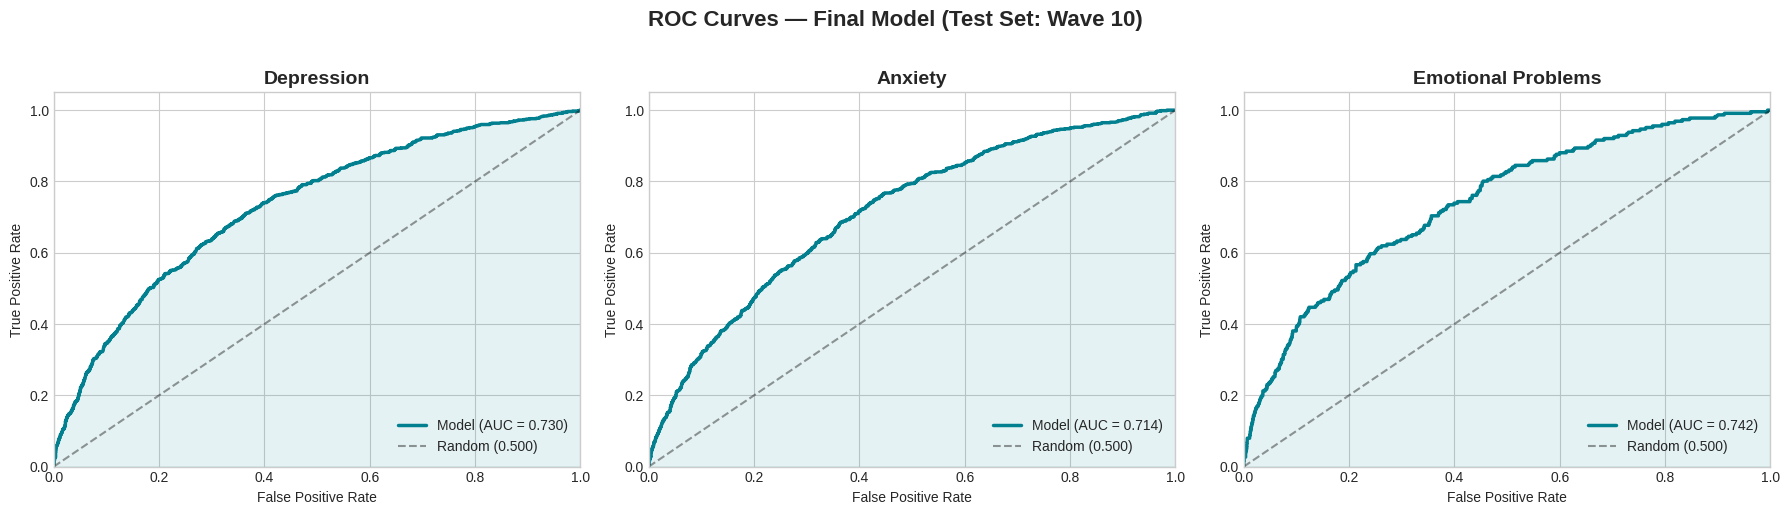

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model, X_t, y_t) in zip(axes, targets_info):
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_t, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#028090', linewidth=2.5, label=f'Model (AUC = {roc_auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.1, color='#028090')
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (0.500)')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right'); ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.suptitle('ROC Curves — Final Model (Test Set: Wave 10)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight'); plt.show()

### Confusion Matrices

The confusion matrix shows the counts of true positives, true negatives, false positives, and false negatives at the selected classification threshold. Given the class imbalance in this dataset (positive cases are rare), the matrices are expected to show many true negatives and relatively few true positives — the key question is whether the model identifies enough genuine cases (true positives) without generating too many false alarms (false positives).


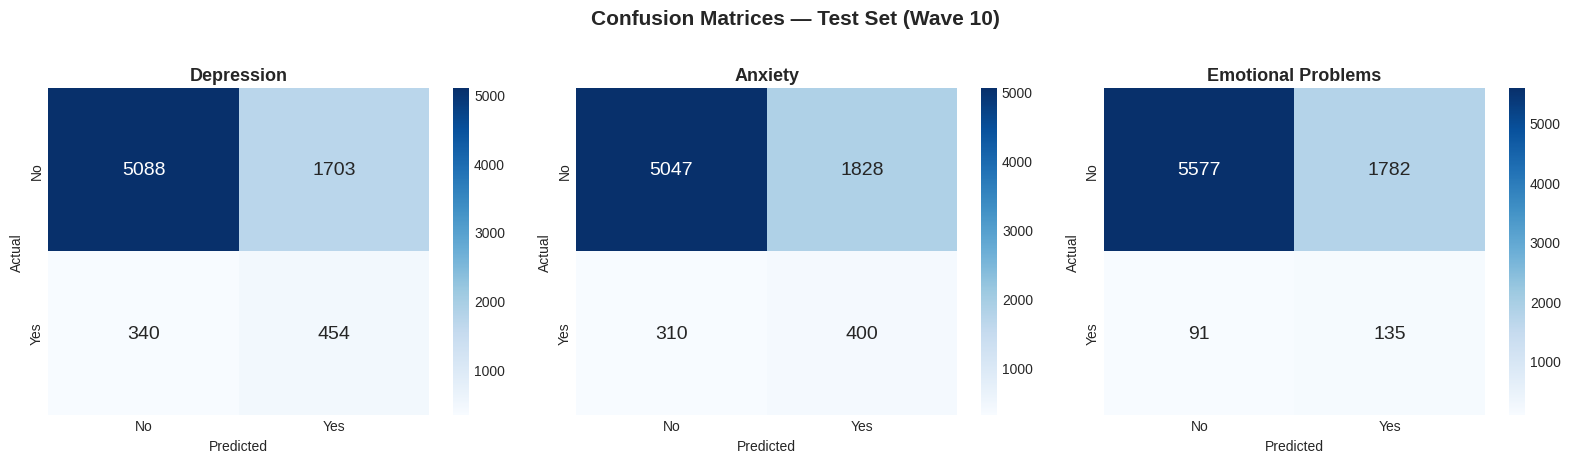

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model, X_t, y_t) in zip(axes, targets_info):
    y_pred = model.predict(X_t)
    cm = confusion_matrix(y_t, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'], ax=ax, annot_kws={"size":14})
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Test Set (Wave 10)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()

### Feature Coefficients (Model Interpretability)

The logistic regression coefficients for each predictor are plotted for all three models. A positive coefficient means the predictor increases the log-odds of the condition (higher risk); a negative coefficient means it decreases the log-odds (lower risk).

Visualising coefficients is important for communicating model findings to non-technical audiences and for checking that the model's learned associations are clinically plausible — for example, we would expect poor self-rated health and pain to be positively associated with depression and anxiety.


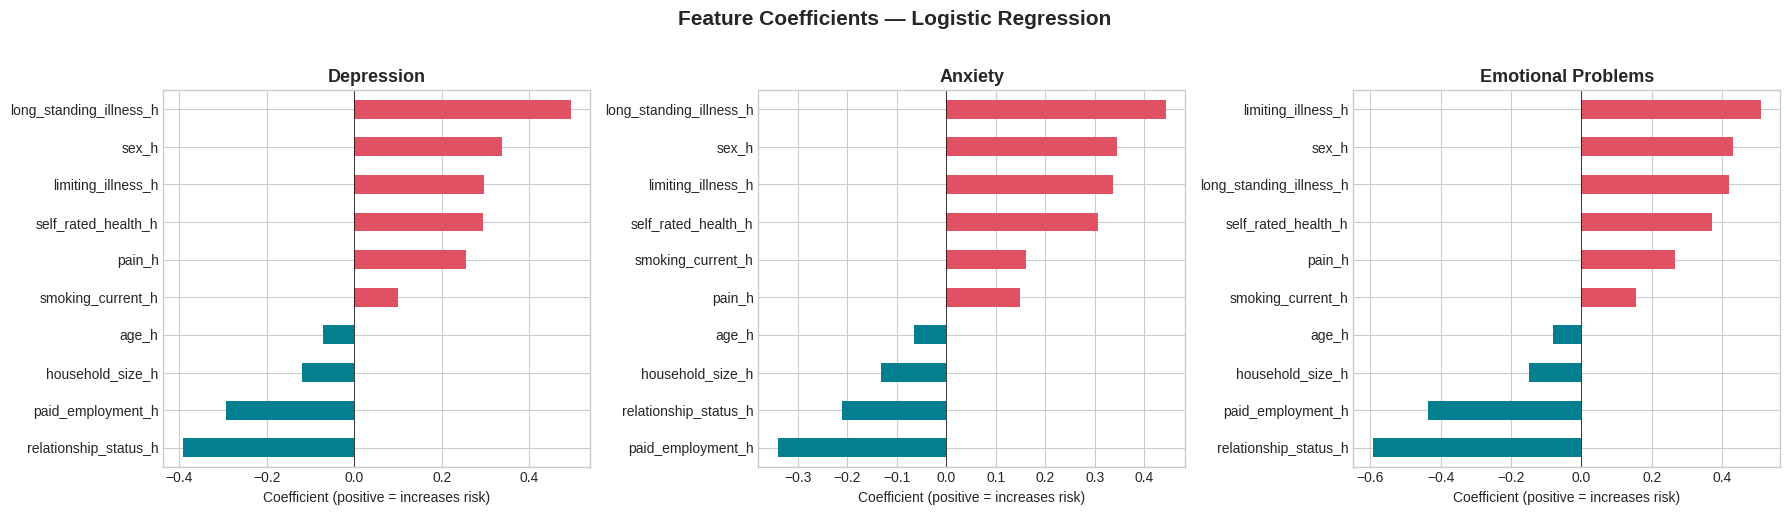

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model, _, _) in zip(axes, targets_info):
    coefs = pd.Series(model.coef_[0], index=PREDS).sort_values()
    colors = ['#E05263' if c > 0 else '#028090' for c in coefs]
    coefs.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Coefficient (positive = increases risk)'); ax.axvline(x=0, color='black', linewidth=0.5)
plt.suptitle('Feature Coefficients — Logistic Regression', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight'); plt.show()

### Precision-Recall Curves

The Precision-Recall (PR) curve plots precision against recall at all threshold values. PR-AUC (Average Precision) is more informative than ROC-AUC for highly imbalanced datasets, because it focuses on the model's performance on the minority (positive) class rather than averaging over all class combinations.

The **baseline** (dashed line) represents the PR-AUC achieved by always predicting the positive class — it equals the positive-class prevalence in the test set. A useful model must substantially exceed this baseline.


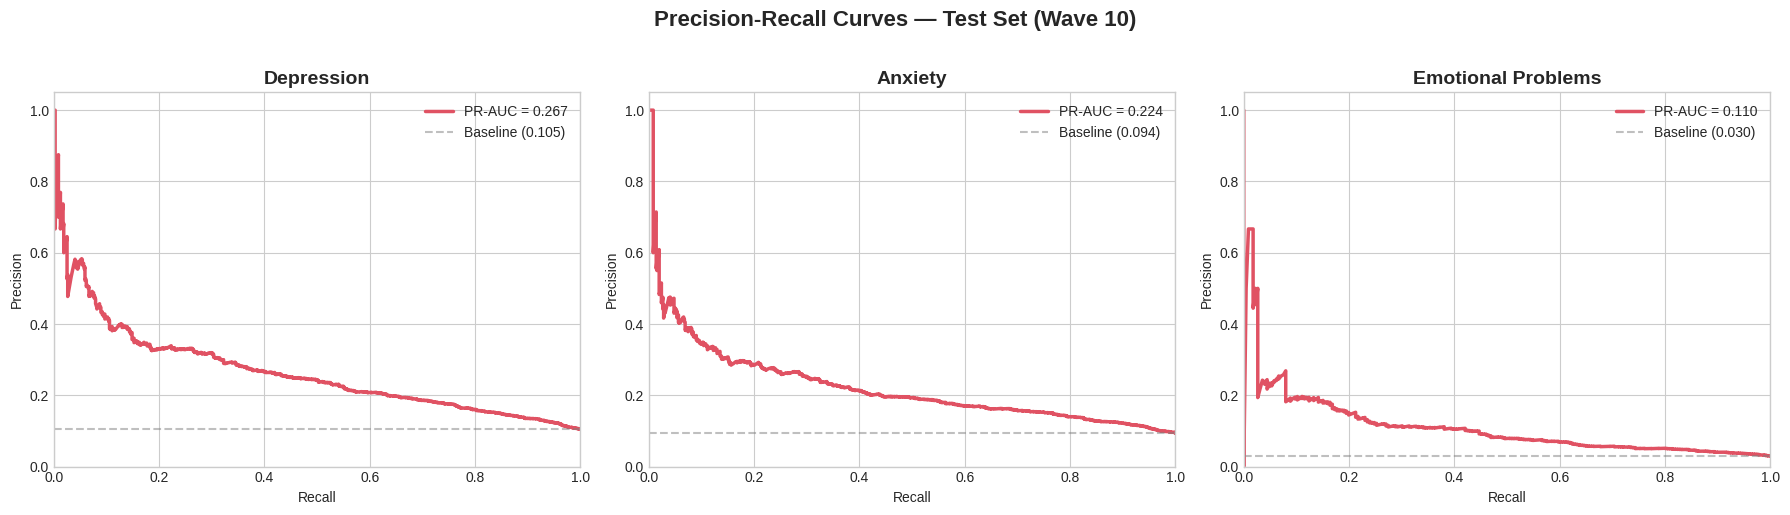

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model, X_t, y_t) in zip(axes, targets_info):
    y_prob = model.predict_proba(X_t)[:, 1]
    precision, recall, _ = precision_recall_curve(y_t, y_prob)
    pr_auc = average_precision_score(y_t, y_prob)
    ax.plot(recall, precision, color='#E05263', linewidth=2.5, label=f'PR-AUC = {pr_auc:.3f}')
    ax.axhline(y=y_t.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_t.mean():.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right'); ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.suptitle('Precision-Recall Curves — Test Set (Wave 10)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight'); plt.show()

### Temporal Prevalence of Mental Health Conditions Across ELSA Waves

This chart shows how the **prevalence** (percentage of positive cases) of each of the three conditions changed across the ten survey waves from 2002 to 2021.

This visualisation serves two purposes:
1. **Contextual understanding**: It shows the distribution shift across waves, which is relevant to how well models trained on earlier waves generalise to later ones.
2. **Epidemiological insight**: Increasing or decreasing trends in mental health prevalence in the English older-adult population over time are visible here.


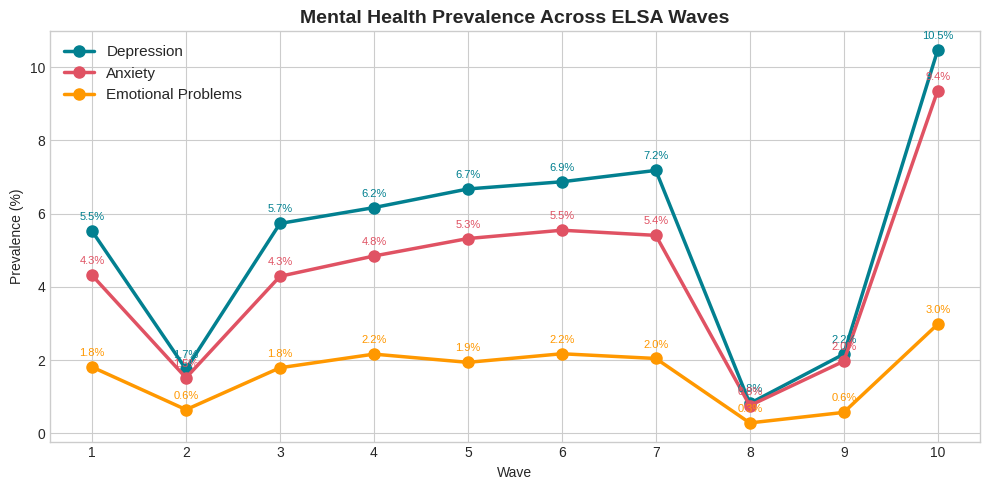

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for target, color, label in [('hepsyde','#028090','Depression'), ('hepsyan','#E05263','Anxiety'), ('hepsyem','#FF9800','Emotional Problems')]:
    prev = combined.groupby('wave')[target].mean() * 100
    ax.plot(prev.index, prev.values, 'o-', color=color, linewidth=2.5, markersize=8, label=label)
    for w, v in zip(prev.index, prev.values):
        ax.text(w, v+0.3, f'{v:.1f}%', ha='center', fontsize=8, color=color)
ax.set_xlabel('Wave'); ax.set_ylabel('Prevalence (%)')
ax.set_title('Mental Health Prevalence Across ELSA Waves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(range(1,11))
plt.tight_layout(); plt.savefig('temporal_prevalence.png', dpi=150, bbox_inches='tight'); plt.show()

### Exporting All Charts

All five generated figures are bundled into a zip file and downloaded from the Colab environment for use in reports and presentations.


In [ ]:
from google.colab import files
import zipfile, os
with zipfile.ZipFile('all_charts.zip', 'w') as z:
    for f in ['roc_curves.png','confusion_matrices.png','feature_coefficients.png','pr_curves.png','temporal_prevalence.png']:
        if os.path.exists(f): z.write(f); print(f"  ✅ {f}")
files.download('all_charts.zip')

  ✅ roc_curves.png
  ✅ confusion_matrices.png
  ✅ feature_coefficients.png
  ✅ pr_curves.png
  ✅ temporal_prevalence.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Classification thresholds were selected on the validation set by maximizing F1 score, and the resulting thresholds were then applied unchanged to the held-out test set to avoid test-set overfitting

Predictor harmonisation was cross-checked against the uploaded ELSA wave dictionaries before final model fitting. Across waves, the main predictor source variables and their value codings were consistent with the dictionaries for age, sex, relationship status, self-rated health, long-standing illness, limiting illness, smoking, pain, and employment status. Binary health and smoking indicators were harmonised using the dictionary coding of 1 = yes and 2 = no, while self-rated health was retained as an ordinal 1–5 measure. One source-name correction was required: for wave 1 smoking, the raw data used heska rather than the initially assumed dictionary-based source, and the final pipeline was updated accordingly. These checks were used to ensure that harmonised predictors were constructed consistently across waves before imputation, threshold tuning, and final model evaluation

The relatively low F1 scores observed in this study should be interpreted in the context of marked class imbalance rather than as evidence of poor overall model usefulness. Across outcomes, the proportion of positive cases was small, particularly for emotional problems, which had only 226 positive cases out of 7,585 in the test set, while depression and anxiety also had low prevalence at 794/7,585 and 710/7,585 respectively. In this setting, even a model with reasonable discriminatory ability can produce modest F1 values, because F1 depends directly on the balance between precision and recall at a chosen classification threshold. When the positive class is rare, identifying more true positives usually comes at the cost of increasing false positives, which lowers precision; conversely, making the threshold more stringent improves precision but reduces recall. This trade-off naturally constrains the F1 score. For that reason, the low-to-moderate F1 values reported here are consistent with the difficulty of threshold-based classification in imbalanced data and should be interpreted alongside threshold-independent metrics such as ROC AUC and threshold-sensitive but imbalance-aware metrics such as PR AUC and balanced accuracy. Taken together, these results suggest that the models retained meaningful ranking ability, even though converting predicted probabilities into binary classifications remained challenging because of the low prevalence of the outcomes